# RPI-DSATUR paper figures

**Research question.** Does a GNN-predicted repair radius plus local list-DSATUR beat full recompute and a fixed radius on speed and locality, without losing validity?

This notebook recomputes every number from the JSONL matrices and the hop-shell train report, then writes publication PNG (300 dpi) and PDF (vector) files to `paper_figures/`. It does **not** read `results/raw_outcomes.jsonl` (stale / different RPI).

**Sources (seed 0 only; not a 5-seed matrix)**

| File | Role |
|---|---|
| `results/matrix_static_systems.jsonl` | Full recompute, fixed r=2, majority r=0 on 45 holdout graphs × 45 edits (2,025 each) |
| `results/matrix_rpi_hopshell.jsonl` | Deployed hop-shell RPI on the same streams |
| `results/matrix_n2000_rpi_vs_full.jsonl` | **OOD** probe: 8 ER graphs, n=2000, 20 edits; RPI vs full only |
| `model/reports/hop_shell/train_report.json` | 6-class test metrics (n=2,007 sequential edits) |
| `data/raw/edits`, `data/raw/edits_n2000` | Edit-type joins (`shrink_list` / `remove_vertex`) |

**Honest takeaways (do not overclaim).** RPI is **not** faster than full DSATUR on holdout n≤500 or OOD n=2000. The hop-shell GNN **does** beat always-0 accuracy. RPI beats fixed r=2 on locality (mean vertices) and tracks majority r=0 on fallback. Validity failures are shared infeasible edits, not merge bugs.


## 0. Setup

Re-run all cells (or `python notebooks/rpi_dsatur_paper_figures.py`). Requires `numpy`, `scipy`, `matplotlib` from `requirements.txt`. Pandas/seaborn are not used.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "results" / "matrix_static_systems.jsonl").exists():
    # notebook opened from notebooks/
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "notebooks"))

from rpi_dsatur_paper_figures import generate_all, OUT, ROOT as REPO

info = generate_all()
print("Repo:", REPO)
print("Wrote", info["n_files"], "files to", info["out"])


Repo: C:\Users\adibb\Desktop\New folder\graphtheoryresearch
Wrote 104 files to C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures


**Figure 0 (KPI strip).** Holdout headline numbers from seed 0, 45 ER holdout graphs, 2,025 streamed edits. Classifier accuracy is on the sequential test split (n=2,007), not the online matrix.


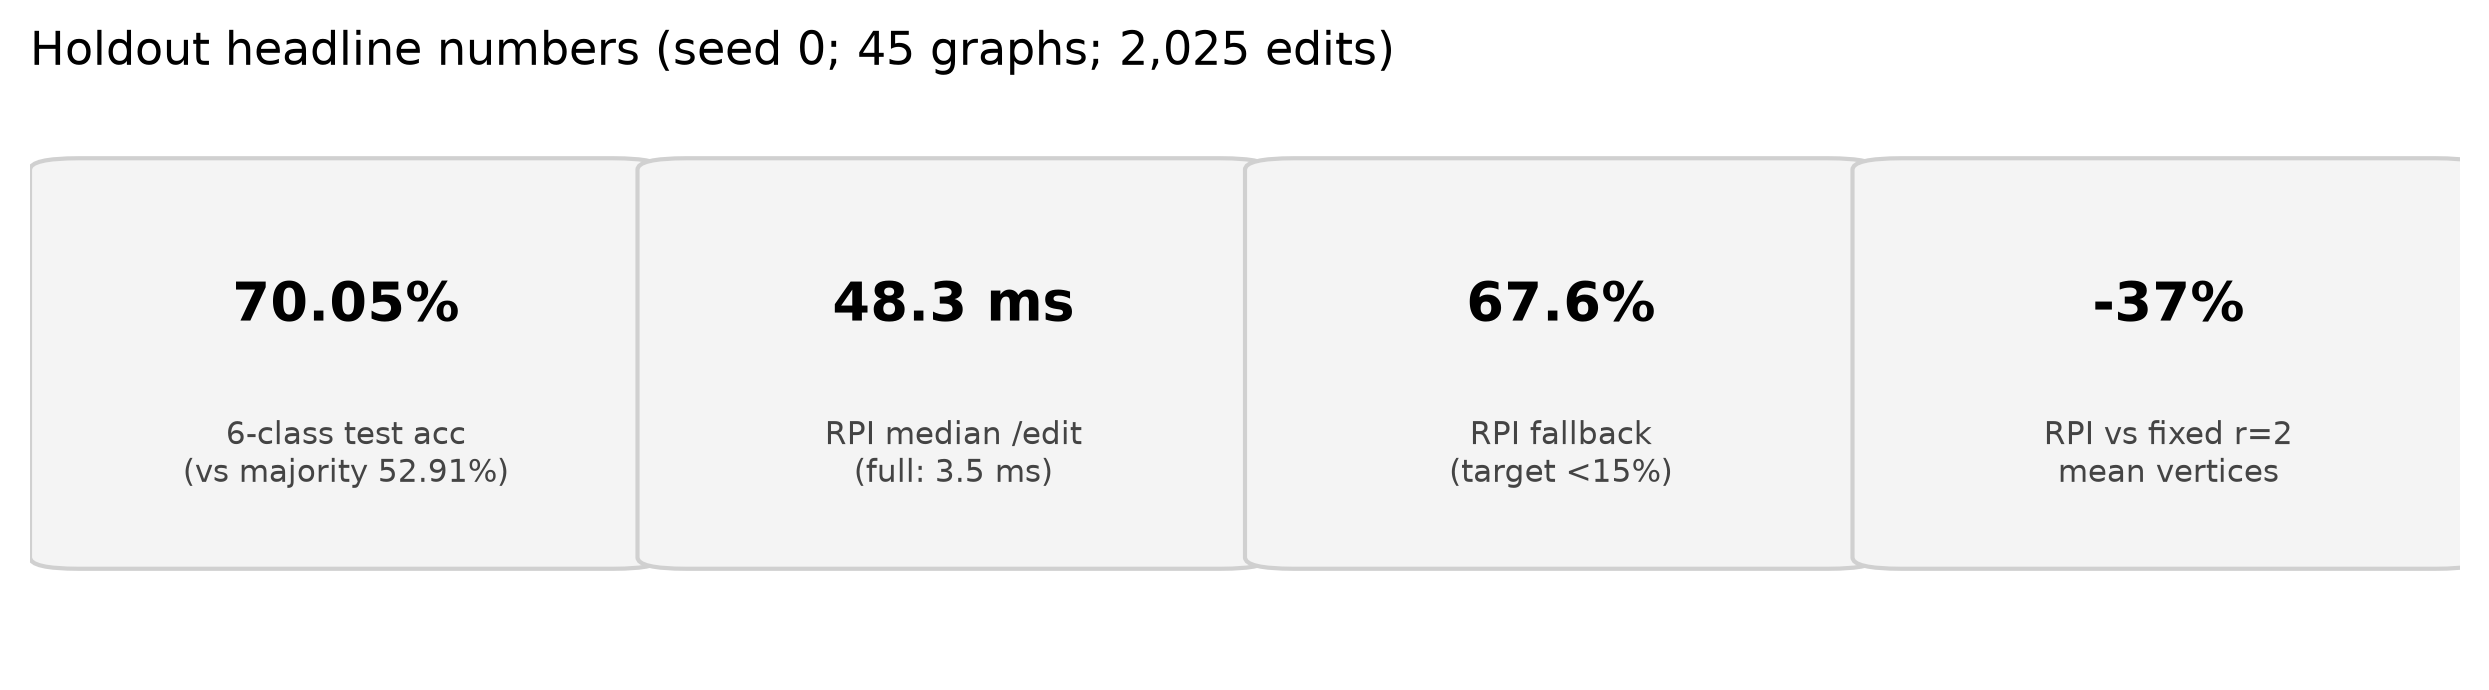

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig00_kpi_strip.png


In [2]:
from IPython.display import Image, display
from pathlib import Path

figdir = Path(info["out"])

def show(stem: str):
    p = figdir / f"{stem}.png"
    display(Image(filename=str(p), width=720))
    print(p)

show("fig00_kpi_strip")


## 1. System comparison (holdout)

Four systems see identical `(graph_id, edit_index, seed=0)` streams.

- **Full recompute** — correctness ceiling; speed floor.
- **Fixed r=2** — same retry ladder, constant start radius (is learning needed?).
- **Majority r=0** — always start at the majority bucket (52.9% of test).
- **RPI hop-shell** — deployed 4-layer GATv2 + hop-shell pool predicts `{0,1,2,3,4,full}`, then 0→1→2→3→4→full with max 3 retries.


**Table 1.** Holdout system summary, all sizes pooled (n=100/200/500). Validity < 100% is infeasible-after-edit: the same failures appear on full recompute, so merge/boundary logic is not the failure mode.


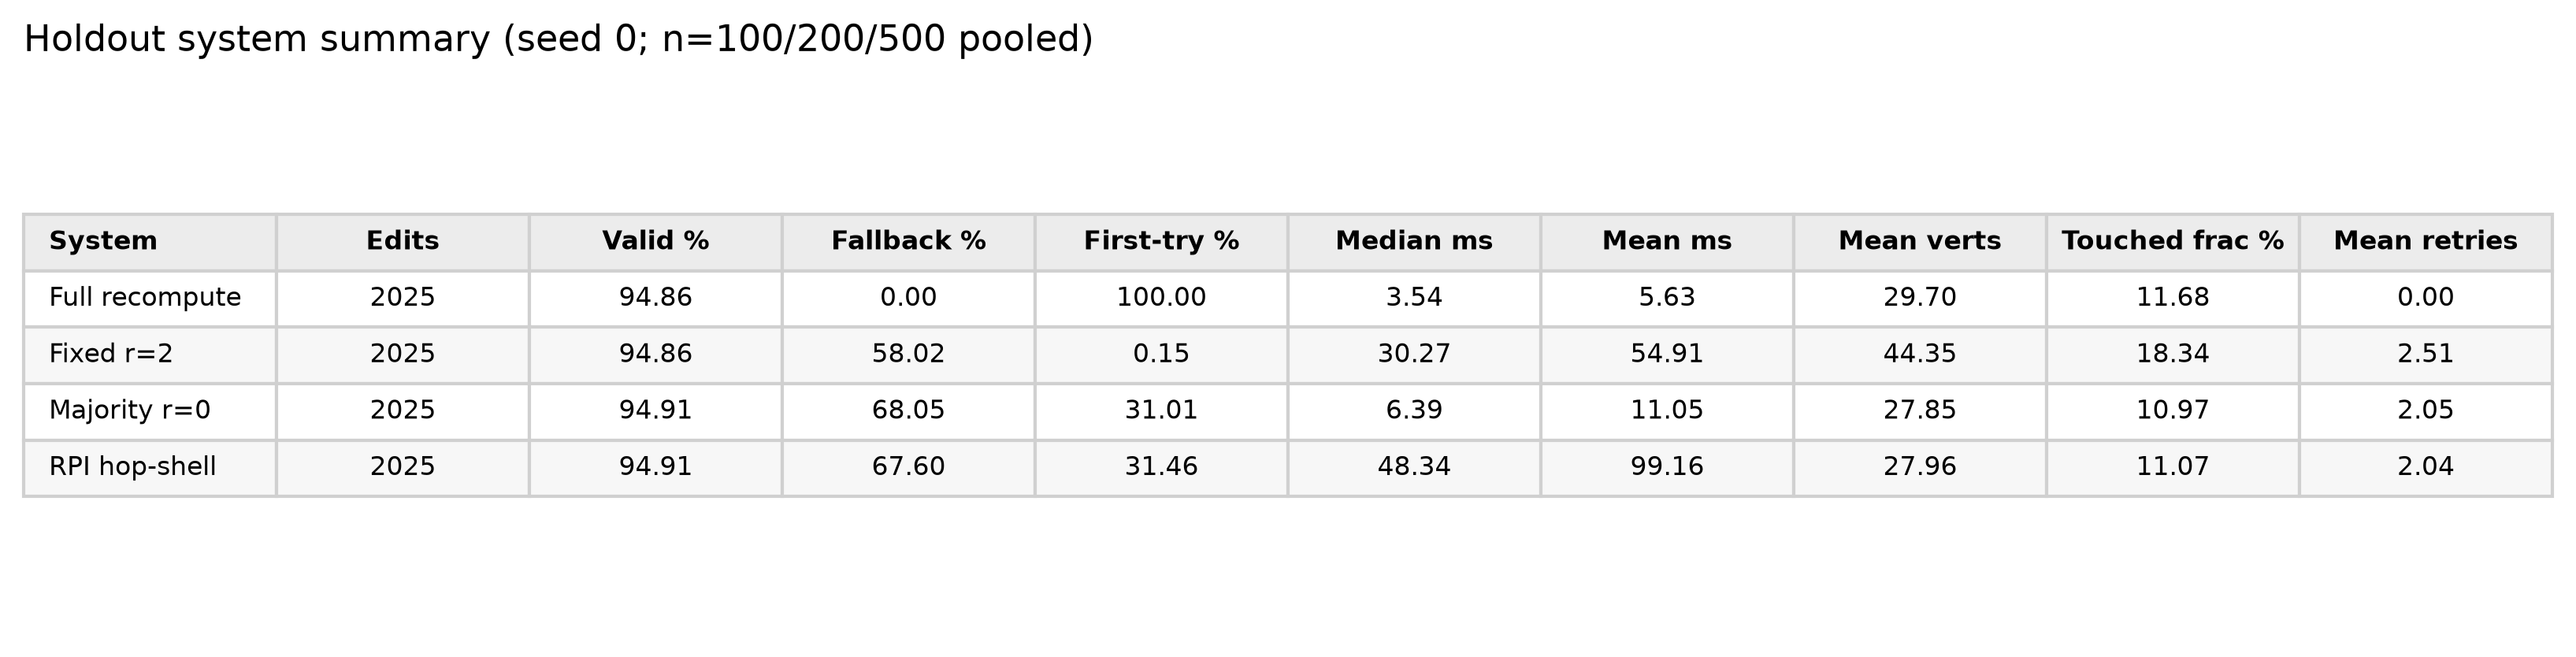

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab01_system_summary.png


In [3]:
show('tab01_system_summary')


**Figure 2.** Validity rates match across systems on 2,025 holdout edits. Conditional on a successful coloring, incremental merge checks hold.


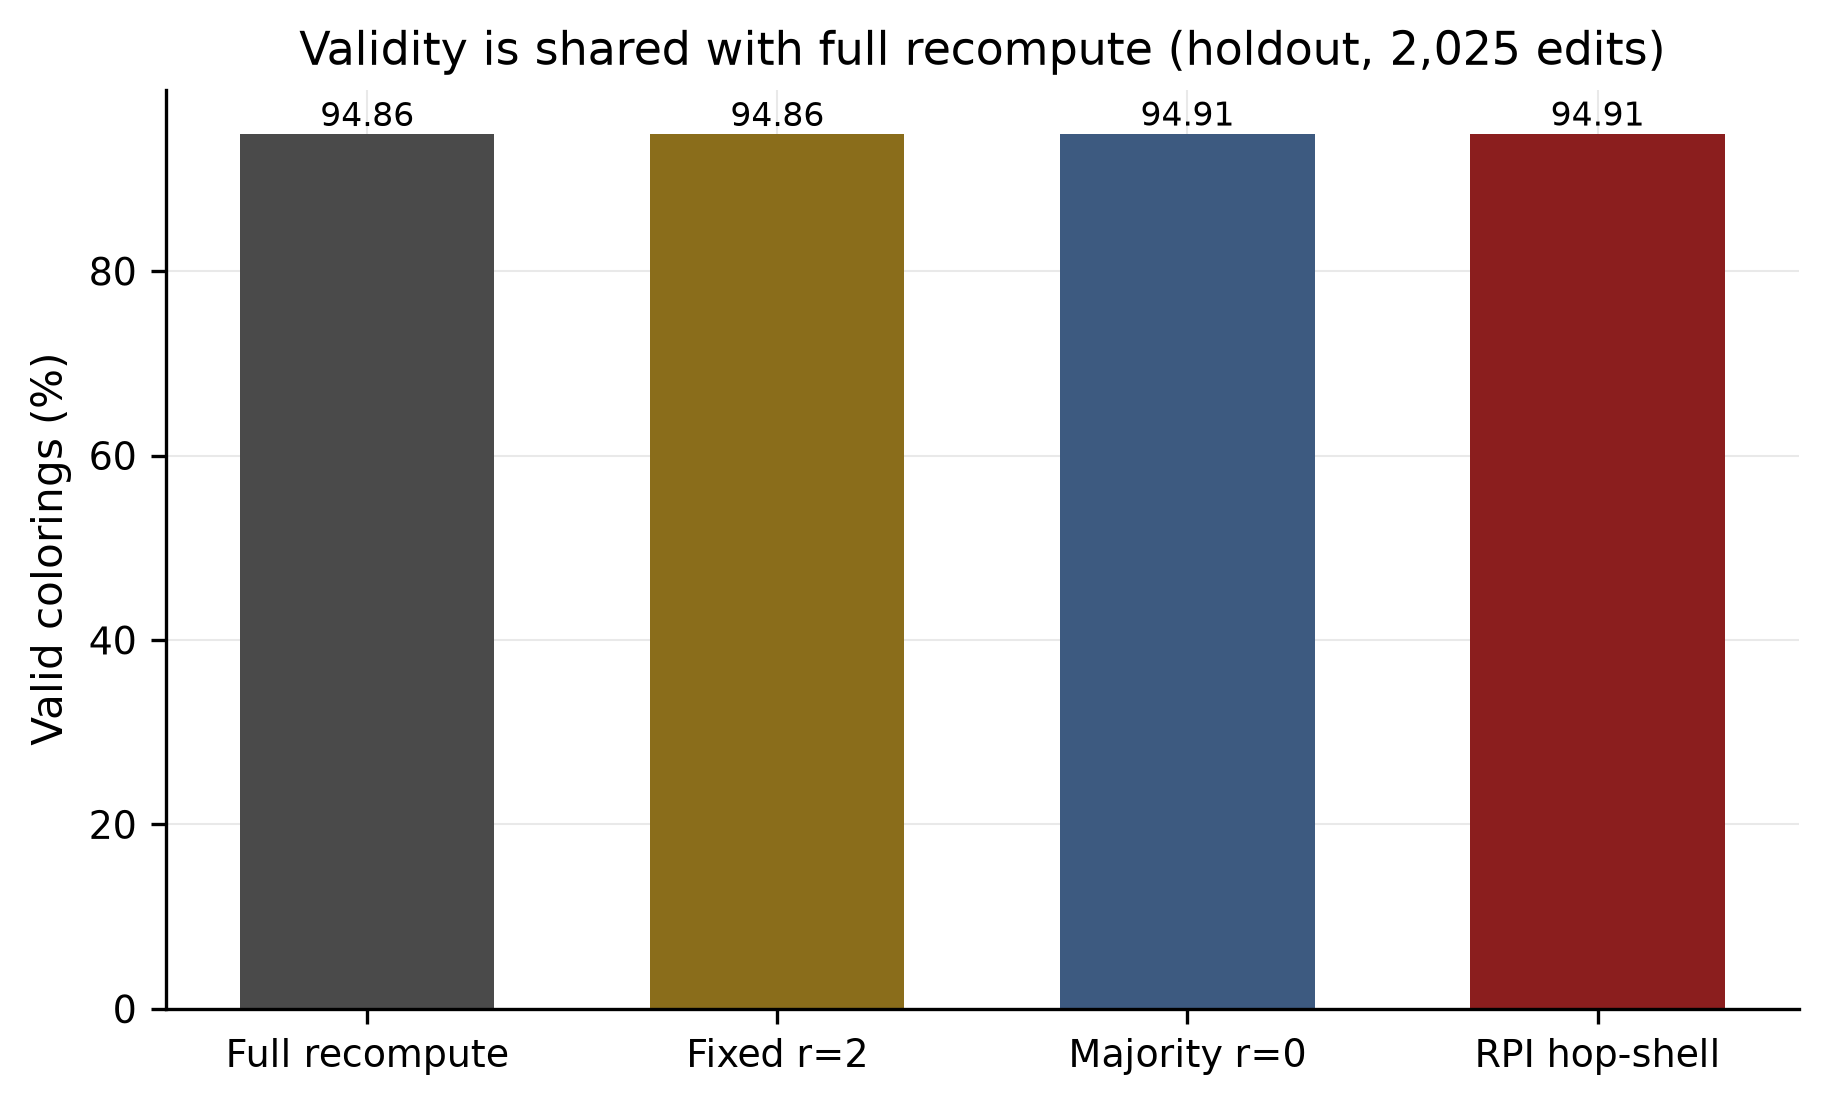

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig02_validity_by_system.png


In [4]:
show('fig02_validity_by_system')


**Figure 3.** Median wall-clock per edit on the holdout matrix. RPI (hop-shell inference + retry ladder) is slower than full DSATUR and slower than fixed r=2. This is the main negative result on speed.


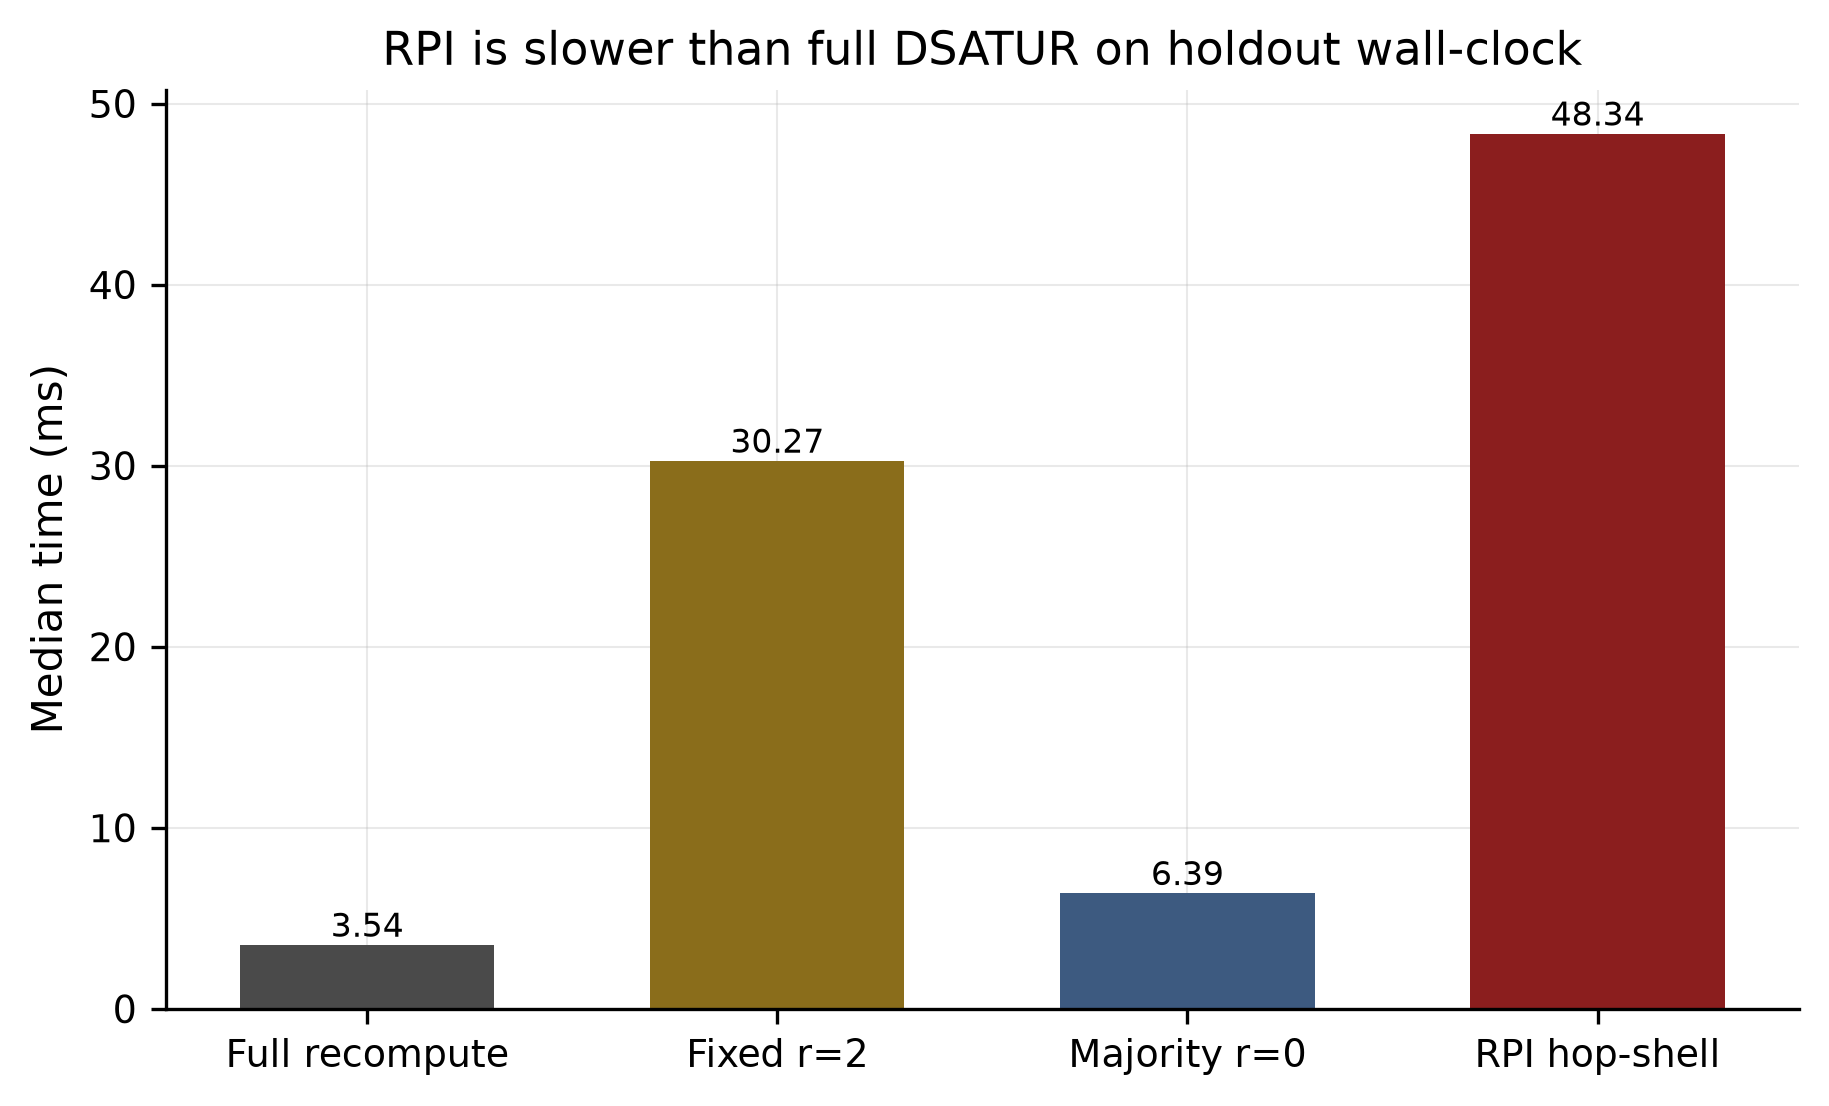

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig03_median_time_by_system.png


In [5]:
show('fig03_median_time_by_system')


**Figure 4.** Fallback rate (MAX_RETRIES exhausted → full recompute). The evaluation spec asked for <15%. RPI tracks majority r=0; fixed r=2 is only modestly better. `r*` from full-DSATUR color-diff is not the same as incremental feasibility.


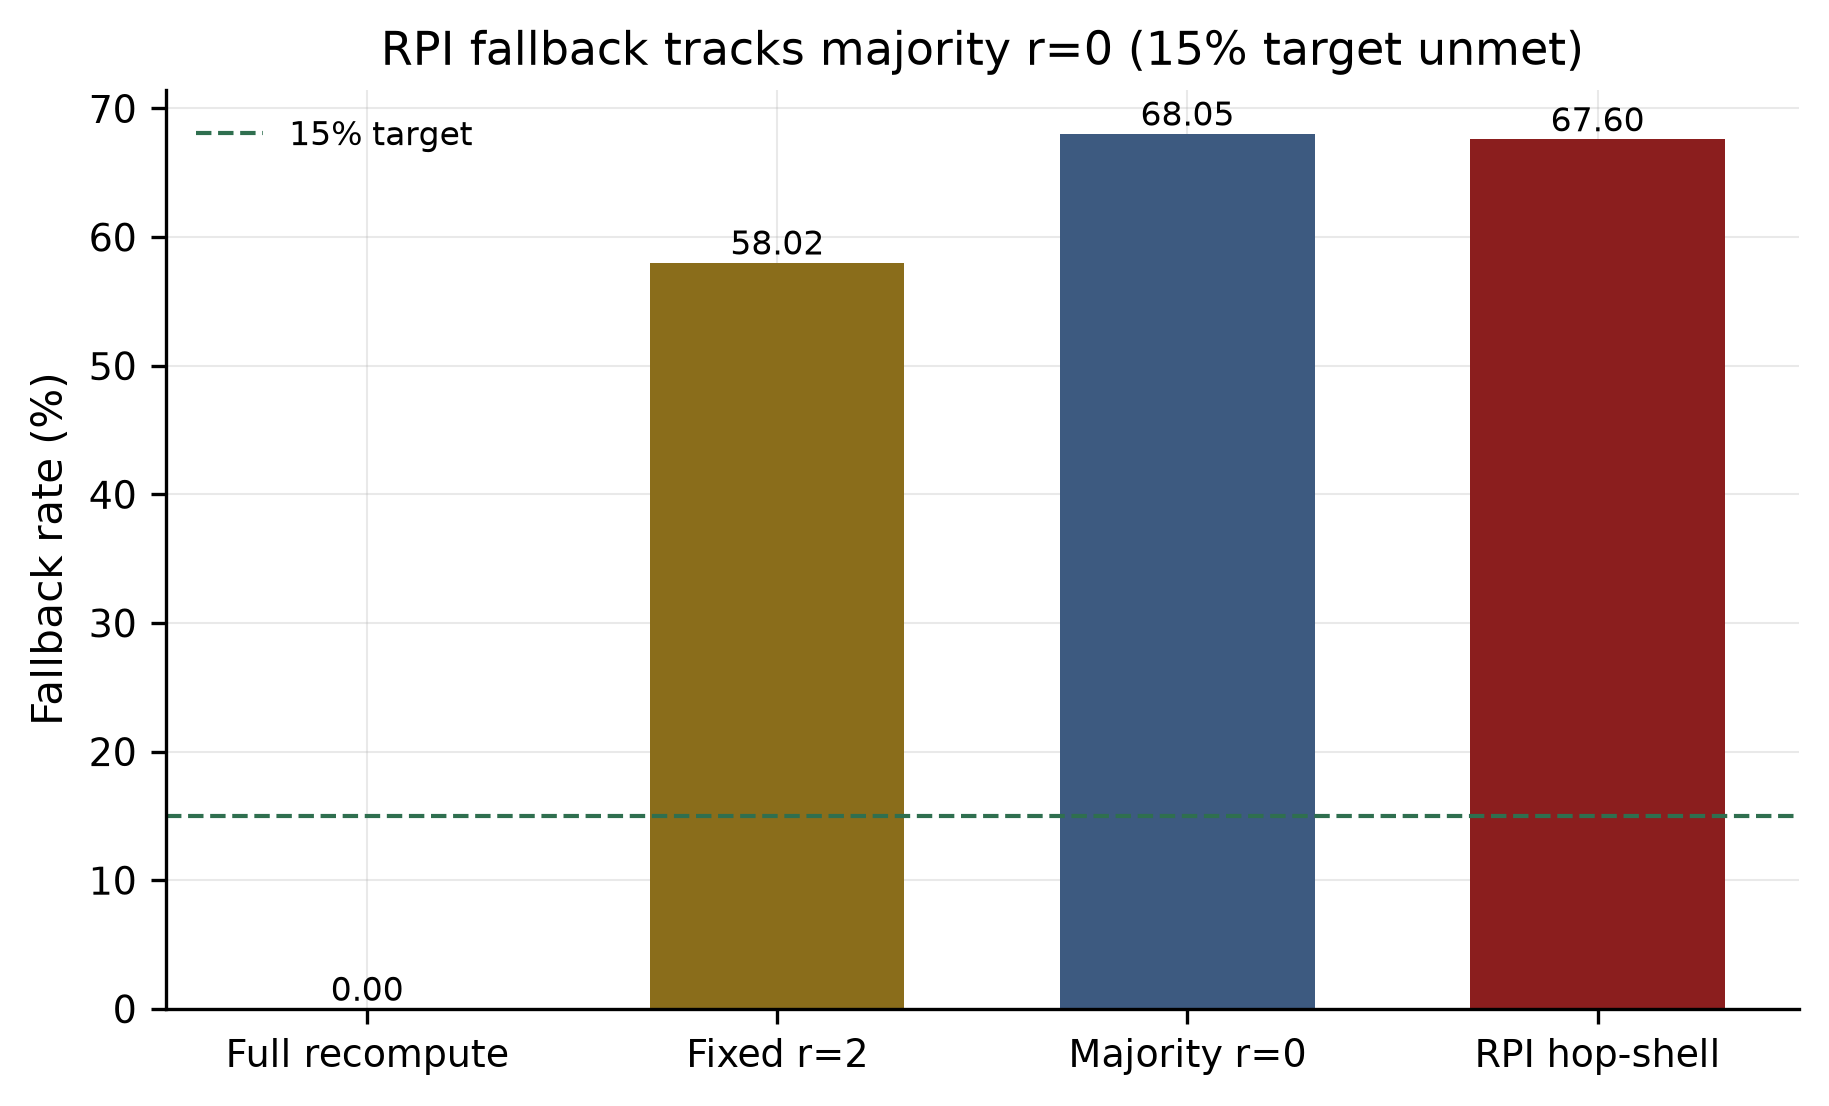

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig04_fallback_by_system.png


In [6]:
show('fig04_fallback_by_system')


**Figure 5.** Mean vertices recolored per edit. RPI matches majority r=0 and beats fixed r=2 by about 37% mean vertices. Locality is the one system-level win vs a non-learned radius.


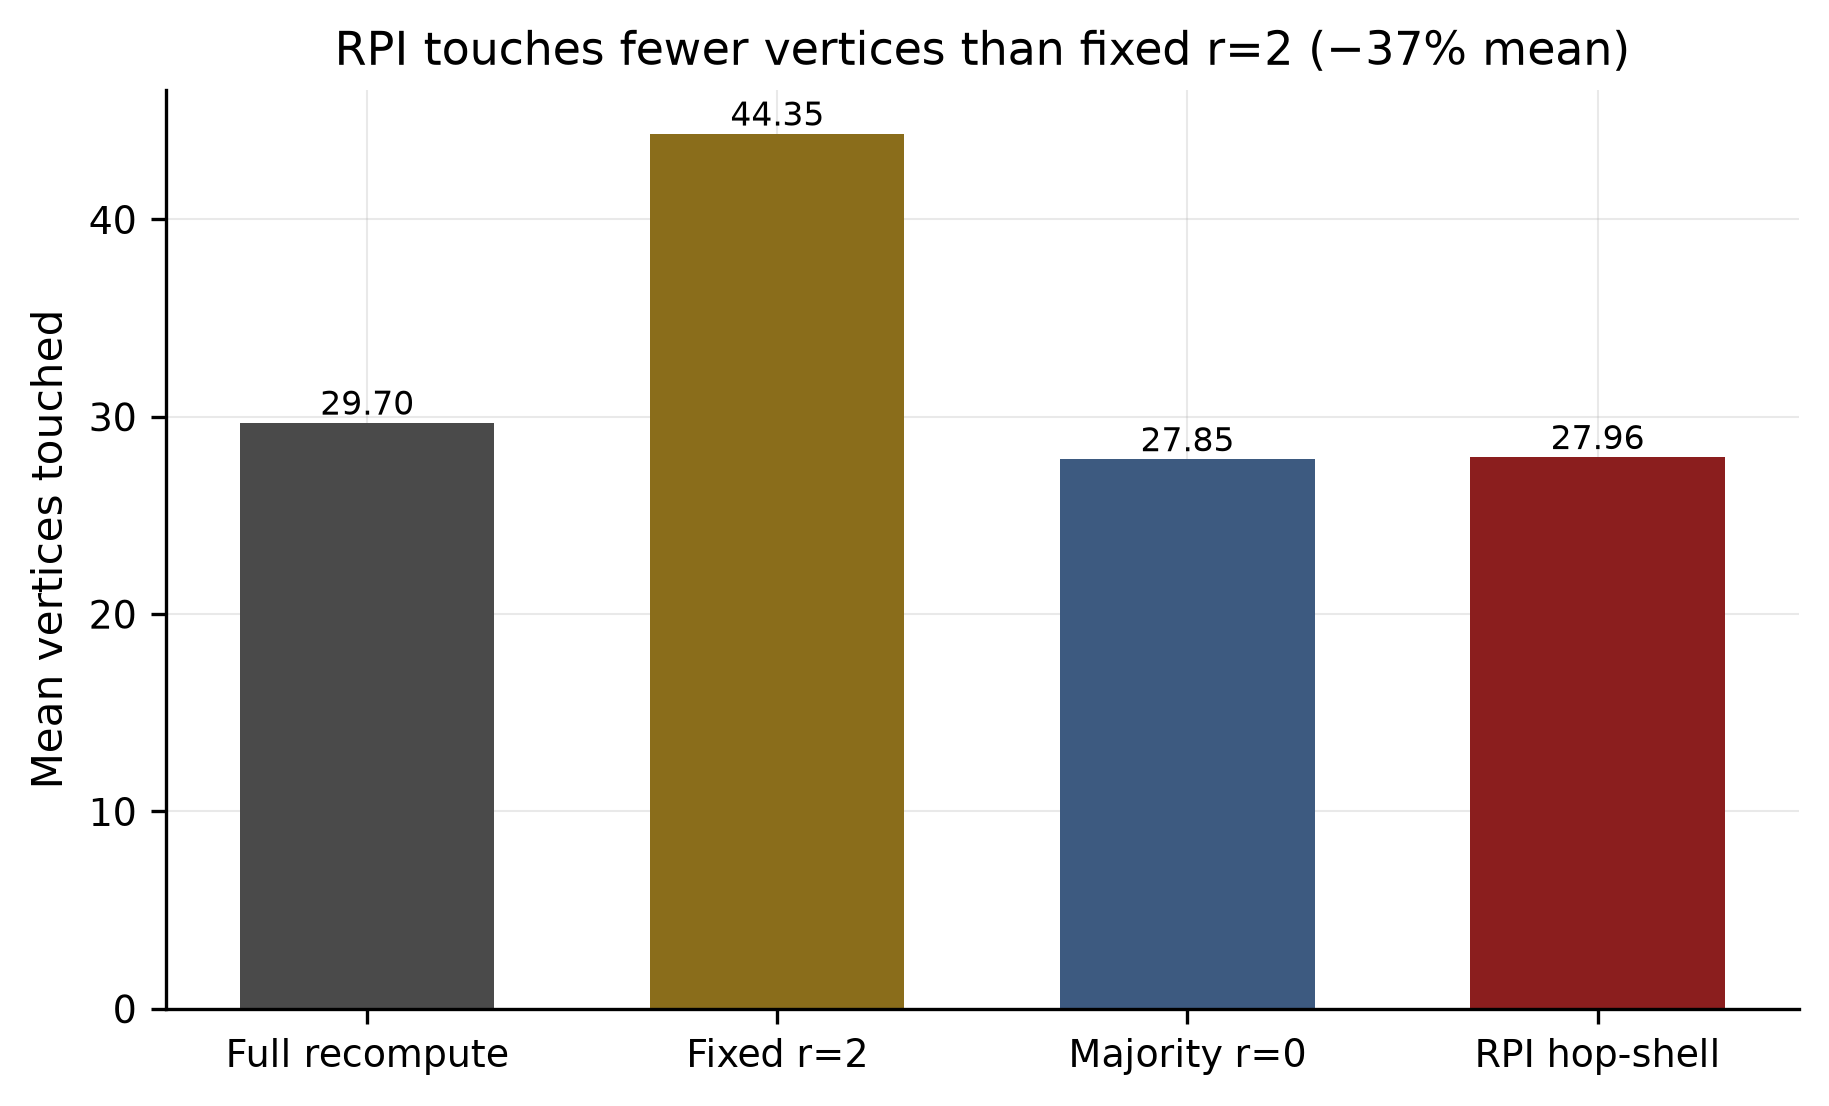

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig05_mean_verts_by_system.png


In [7]:
show('fig05_mean_verts_by_system')


**Figure 6.** First-try rate (`attempts = 0`). Full recompute is definitionally 100%. RPI and majority first-tries are almost entirely `shrink_list` (see §4).


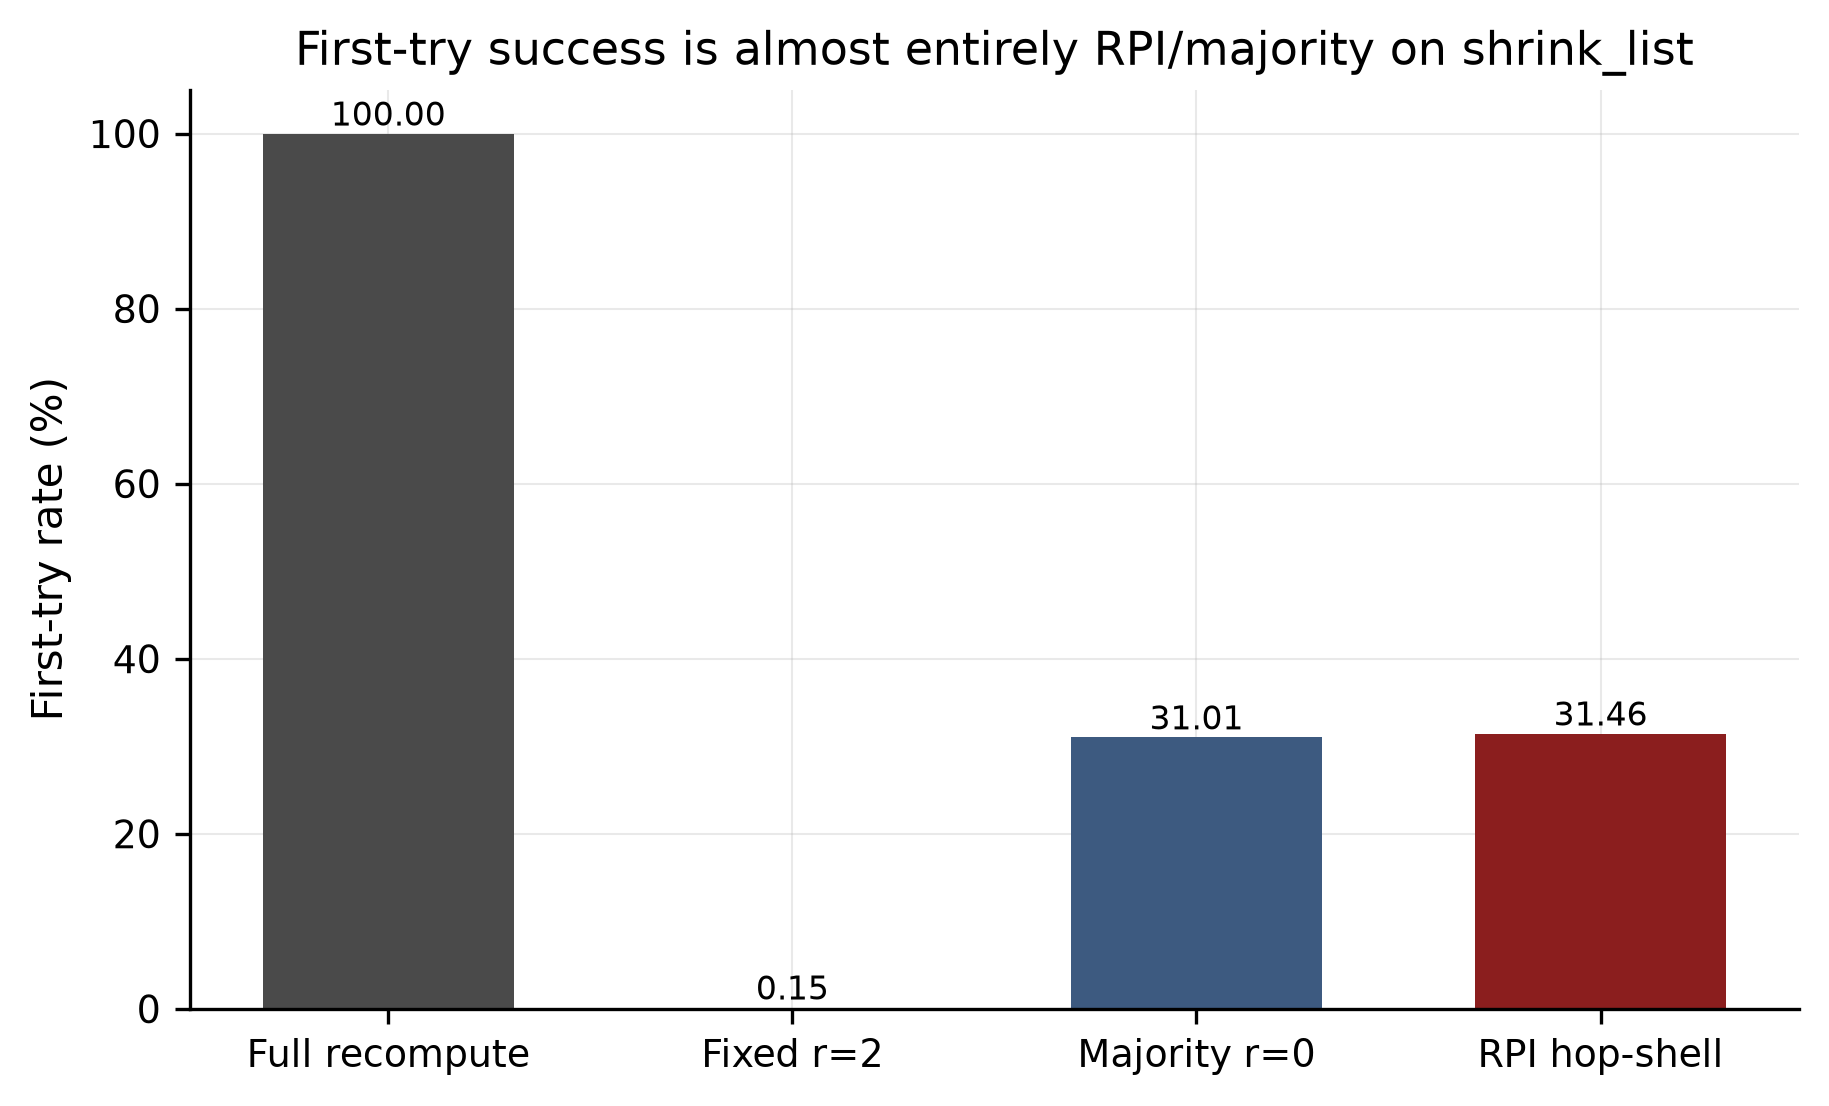

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig06_first_try_by_system.png


In [8]:
show('fig06_first_try_by_system')


**Figure 7.** Median time with 25th–75th percentiles. Costs are right-skewed: report medians, not means, as the primary speed statistic.


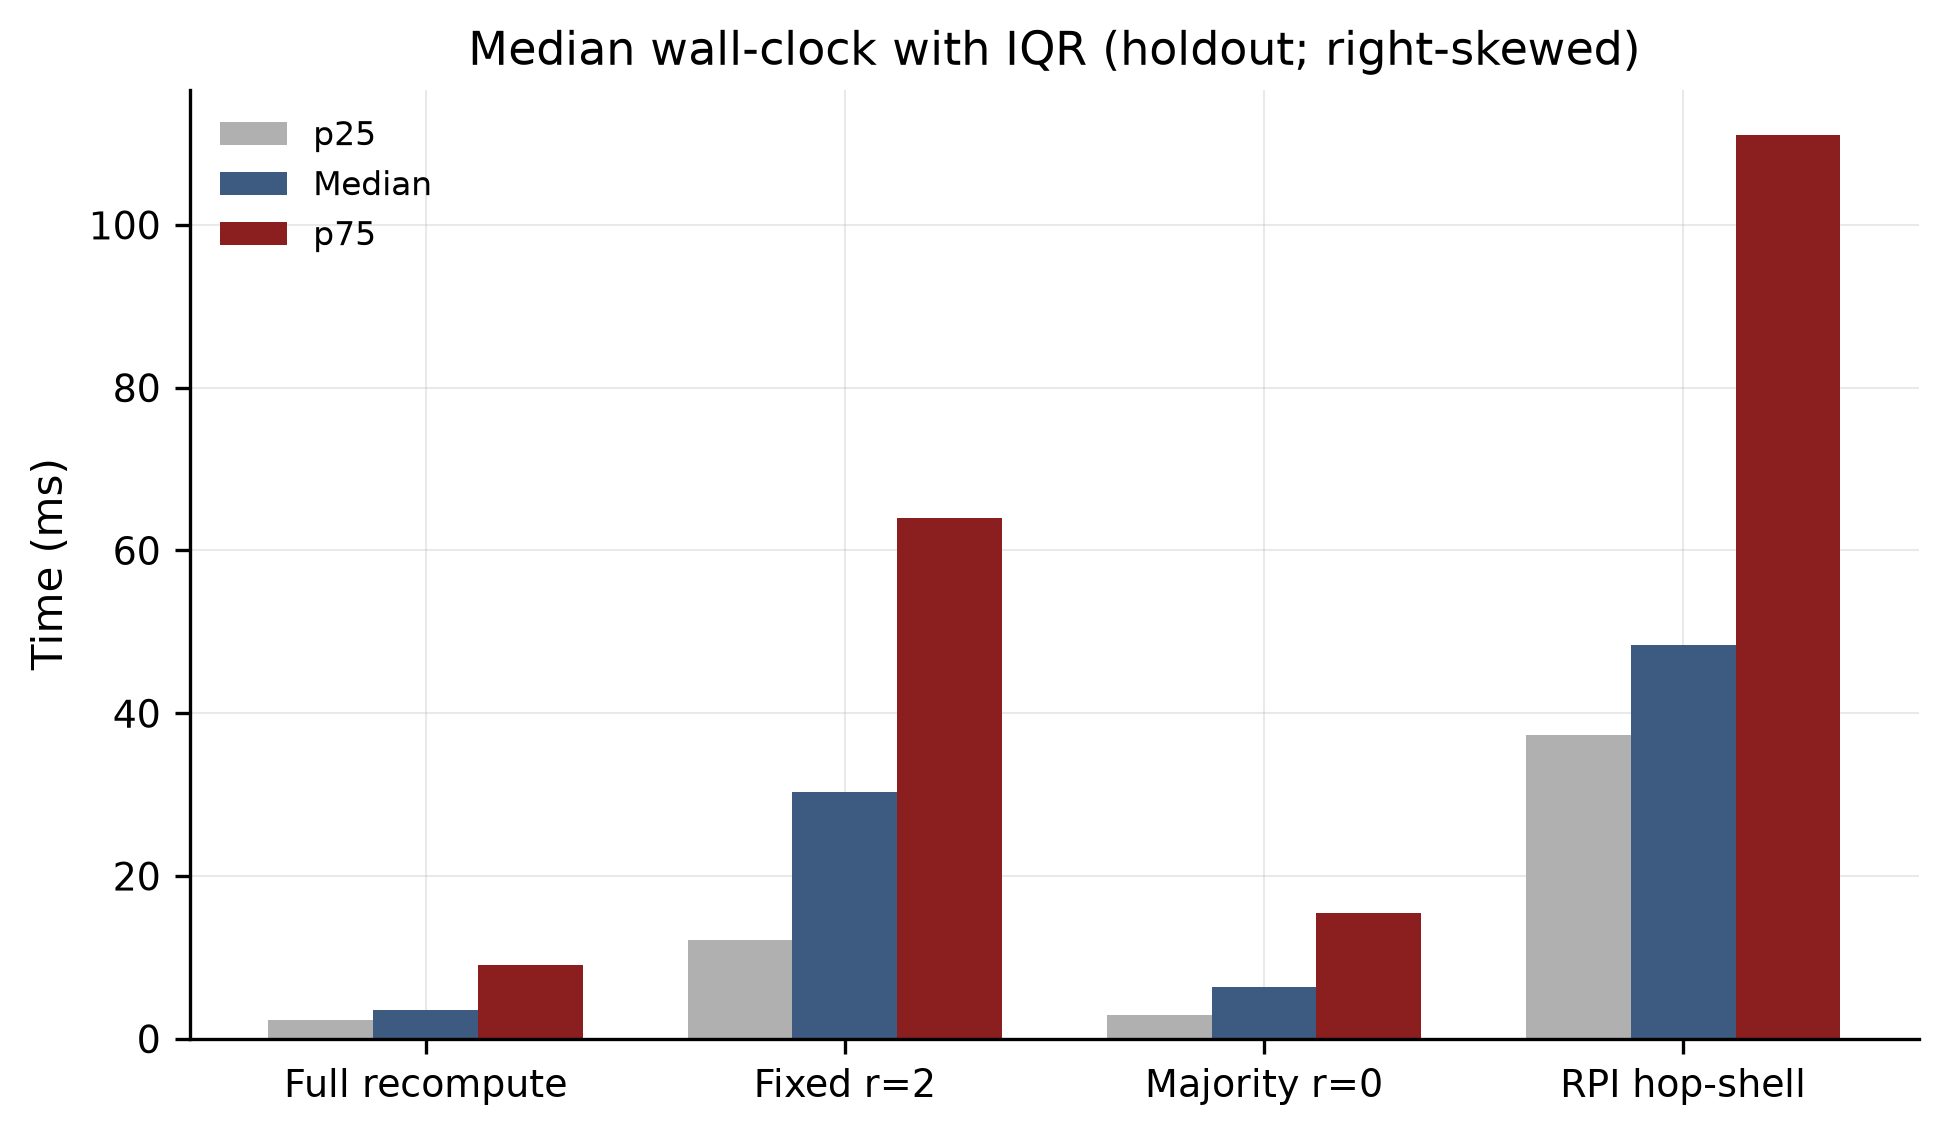

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig07_time_iqr_by_system.png


In [9]:
show('fig07_time_iqr_by_system')


**Figure 8.** Mean vertices vs mean milliseconds. Less local work does not produce a faster online system on these n≤500 ER graphs: GNN + retries dominate DSATUR.


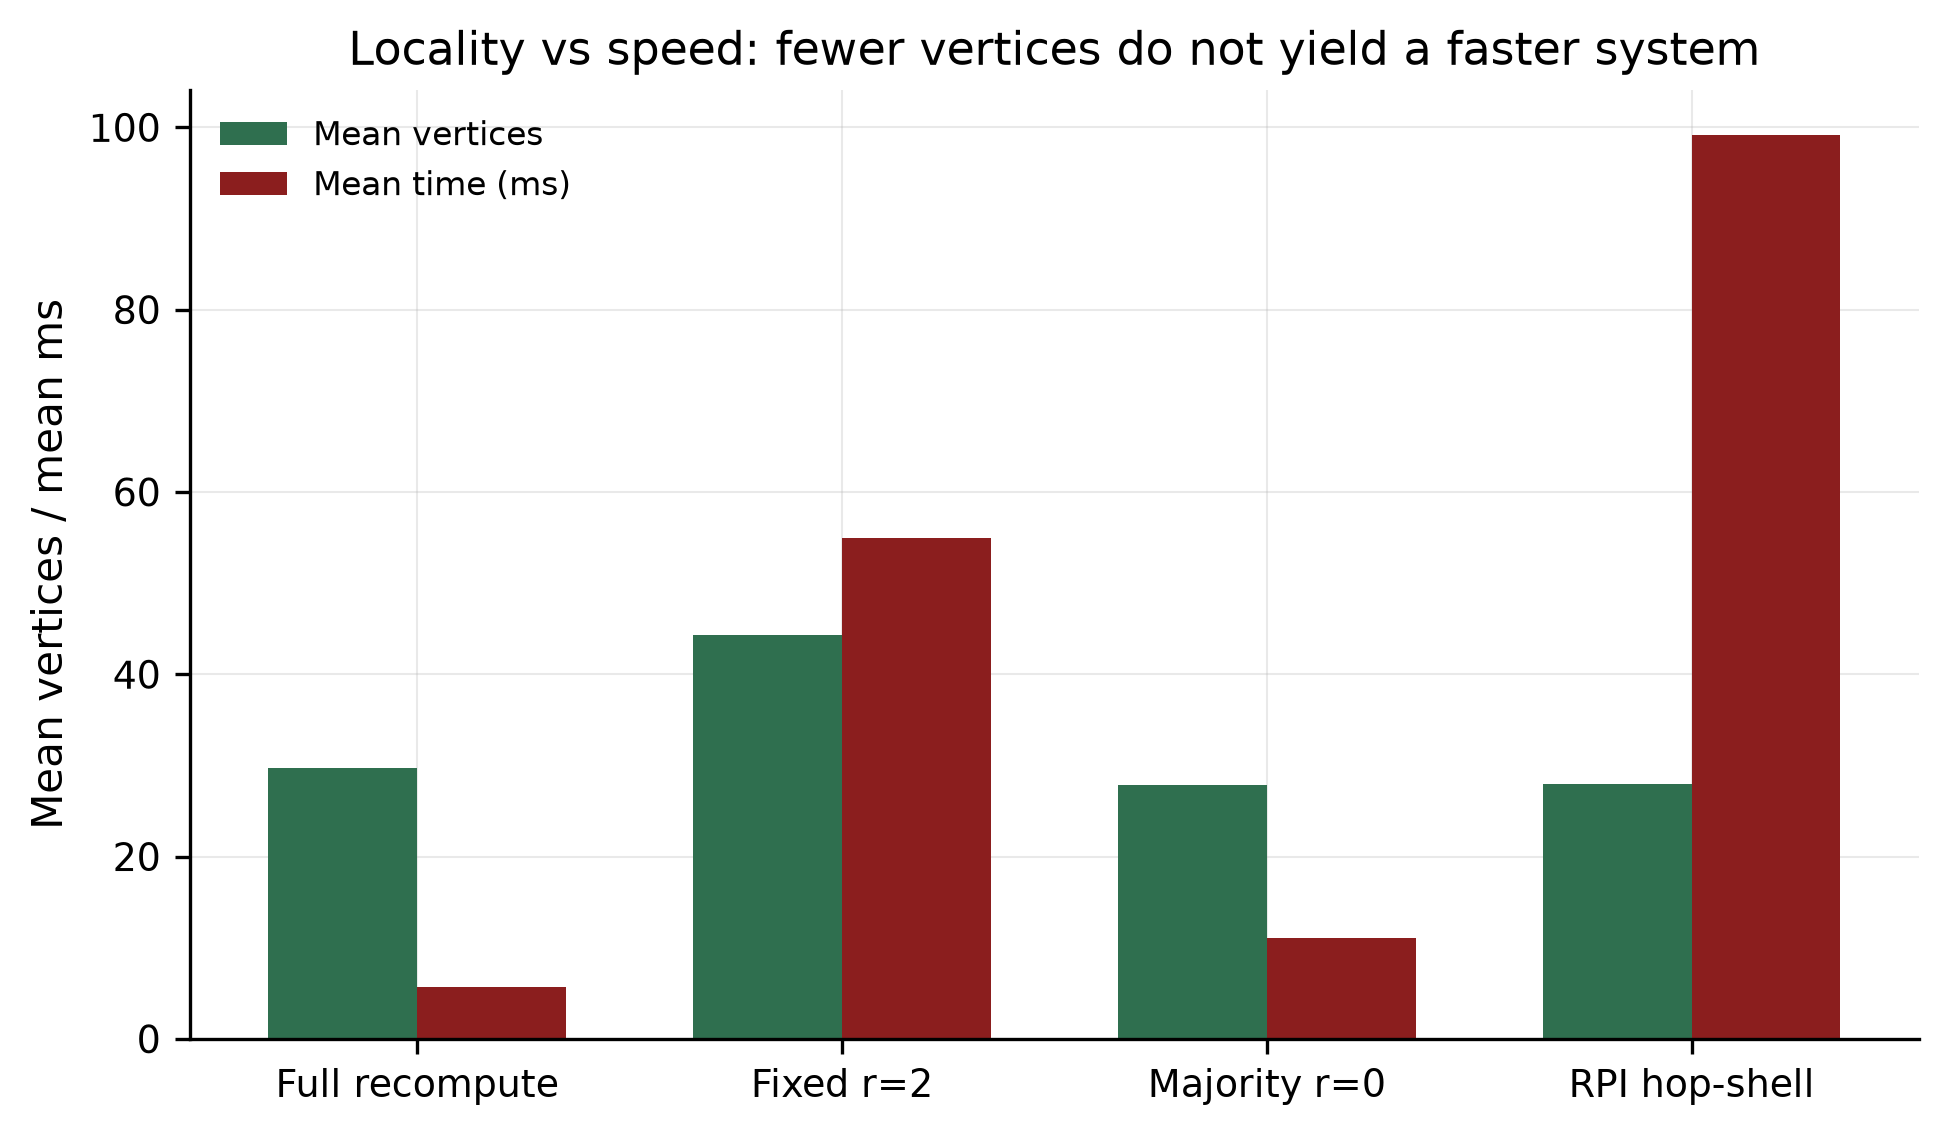

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig08_locality_vs_speed.png


In [10]:
show('fig08_locality_vs_speed')


**Figure 13.** Boxplots of per-edit time by system (outliers hidden). Medians sit well below the upper quartile for RPI, consistent with a heavy retry tail.


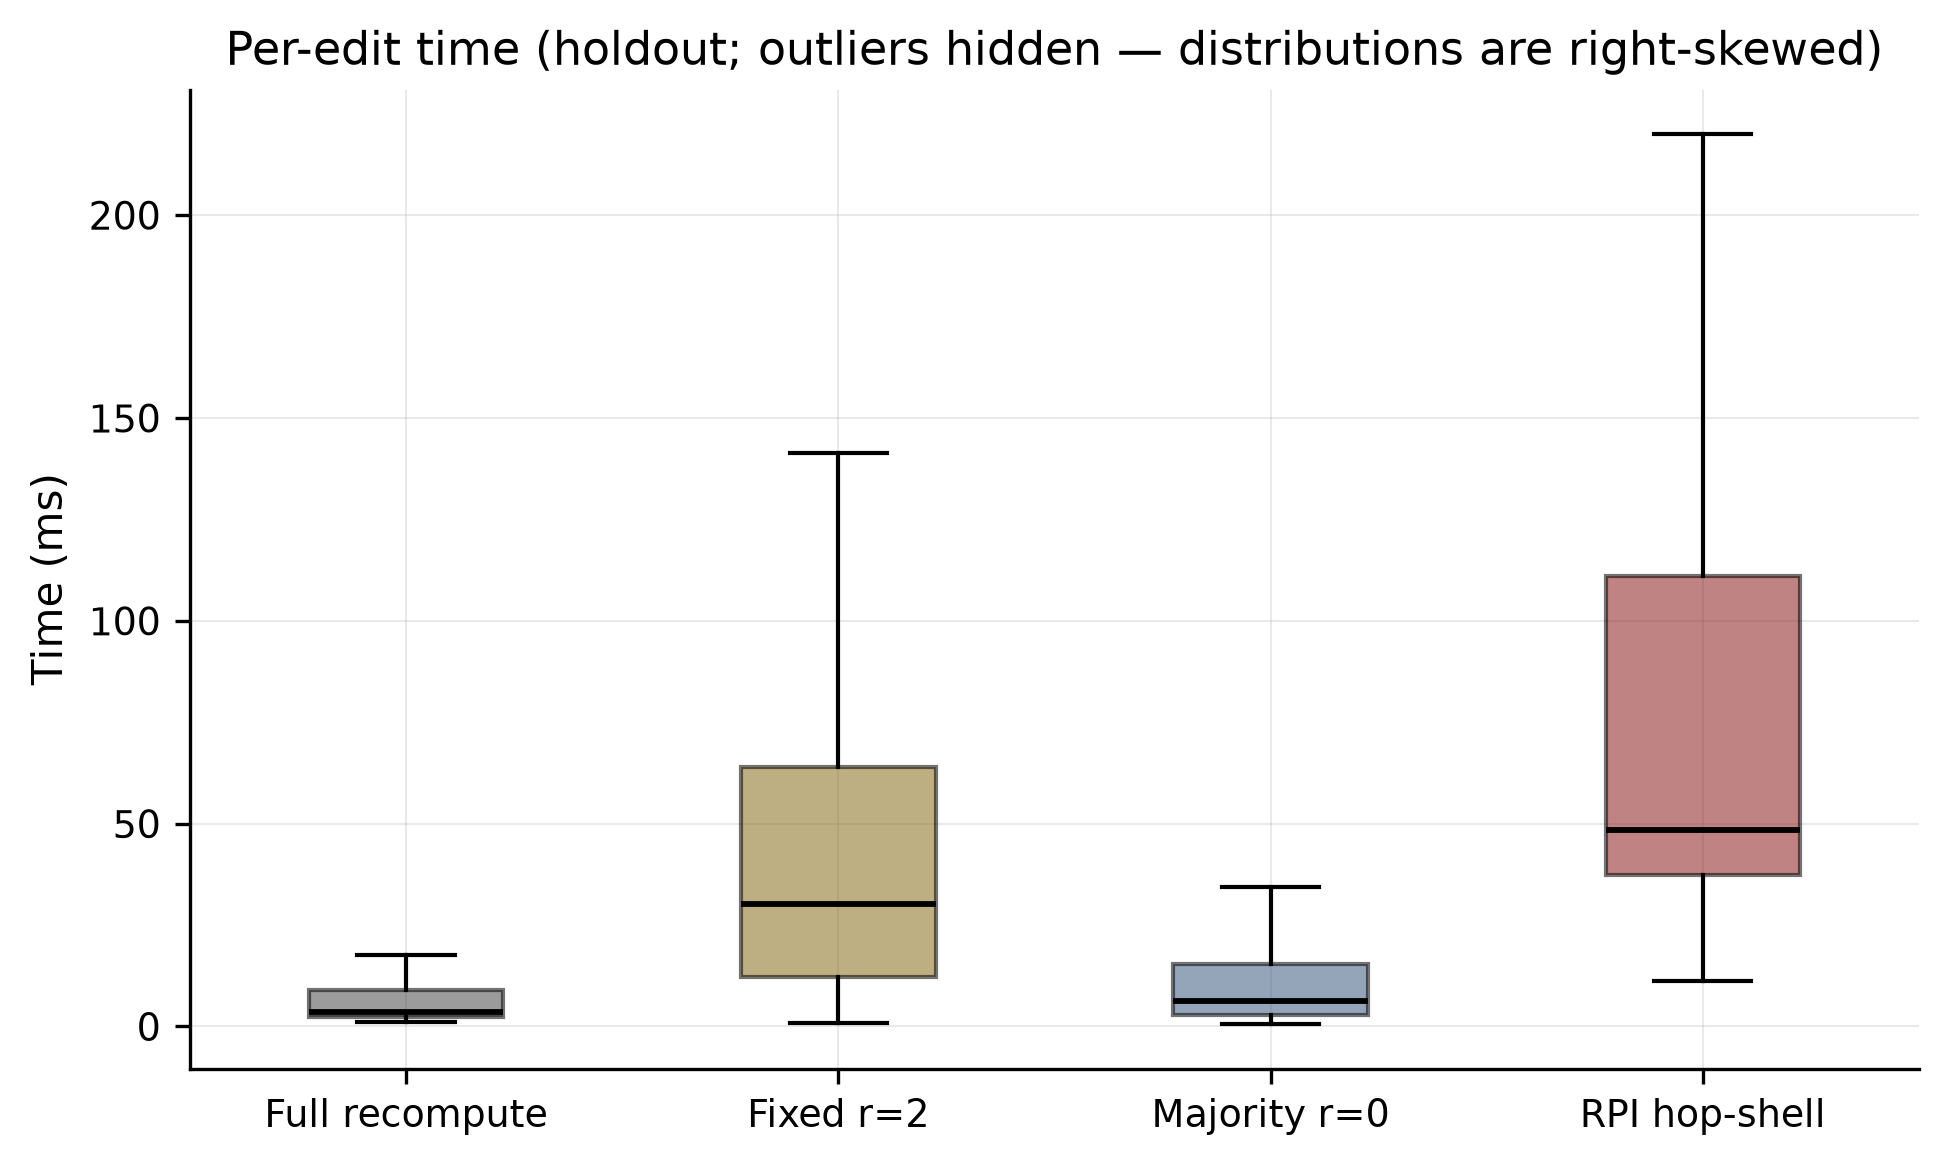

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig13_time_box_by_system.png


In [11]:
show('fig13_time_box_by_system')


**Figure 14.** The same time distributions split by n ∈ {100, 200, 500}. Full recompute scales cleanly; RPI’s box stays high even at n=100 because model + ladder cost is paid on every edit.


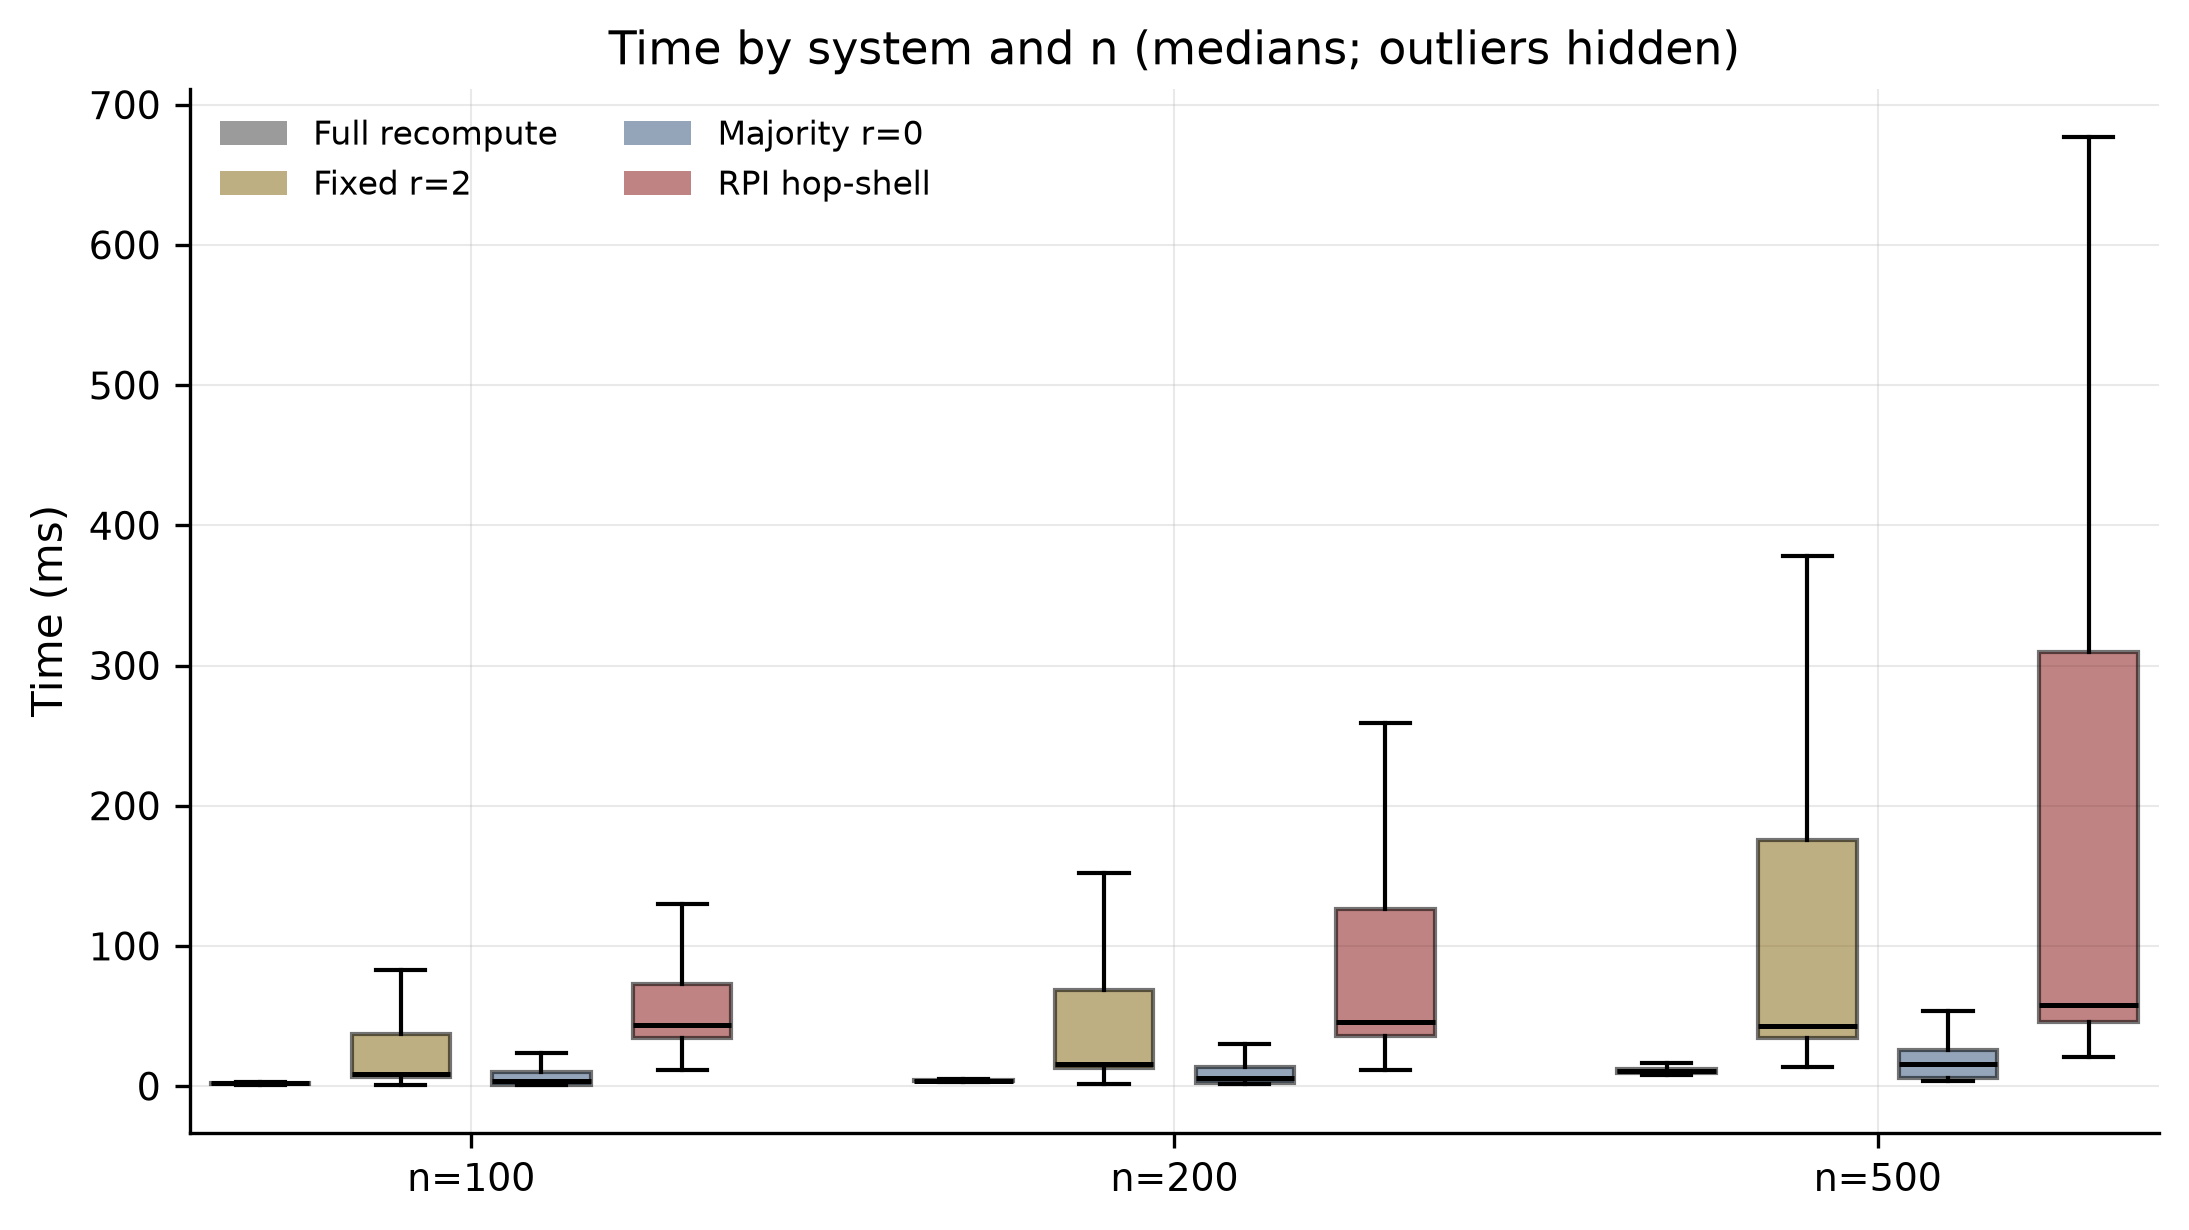

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig14_time_box_by_n.png


In [12]:
show('fig14_time_box_by_n')


## 2. Radius classifier

Deployed checkpoint: 4-layer GATv2, hop-4 window, hop-shell pooling, ordinal CE+MAE λ=0.5, guarded val-accuracy (macro-F1 ≥ 0.40). The 72% 6-class target was not met. Test n=2,007 sequential holdout edits.


**Figure 1.** Six-class test accuracy vs the always-0 majority baseline. GNN +17.1 pp over always-0; still short of the 72% spec line.


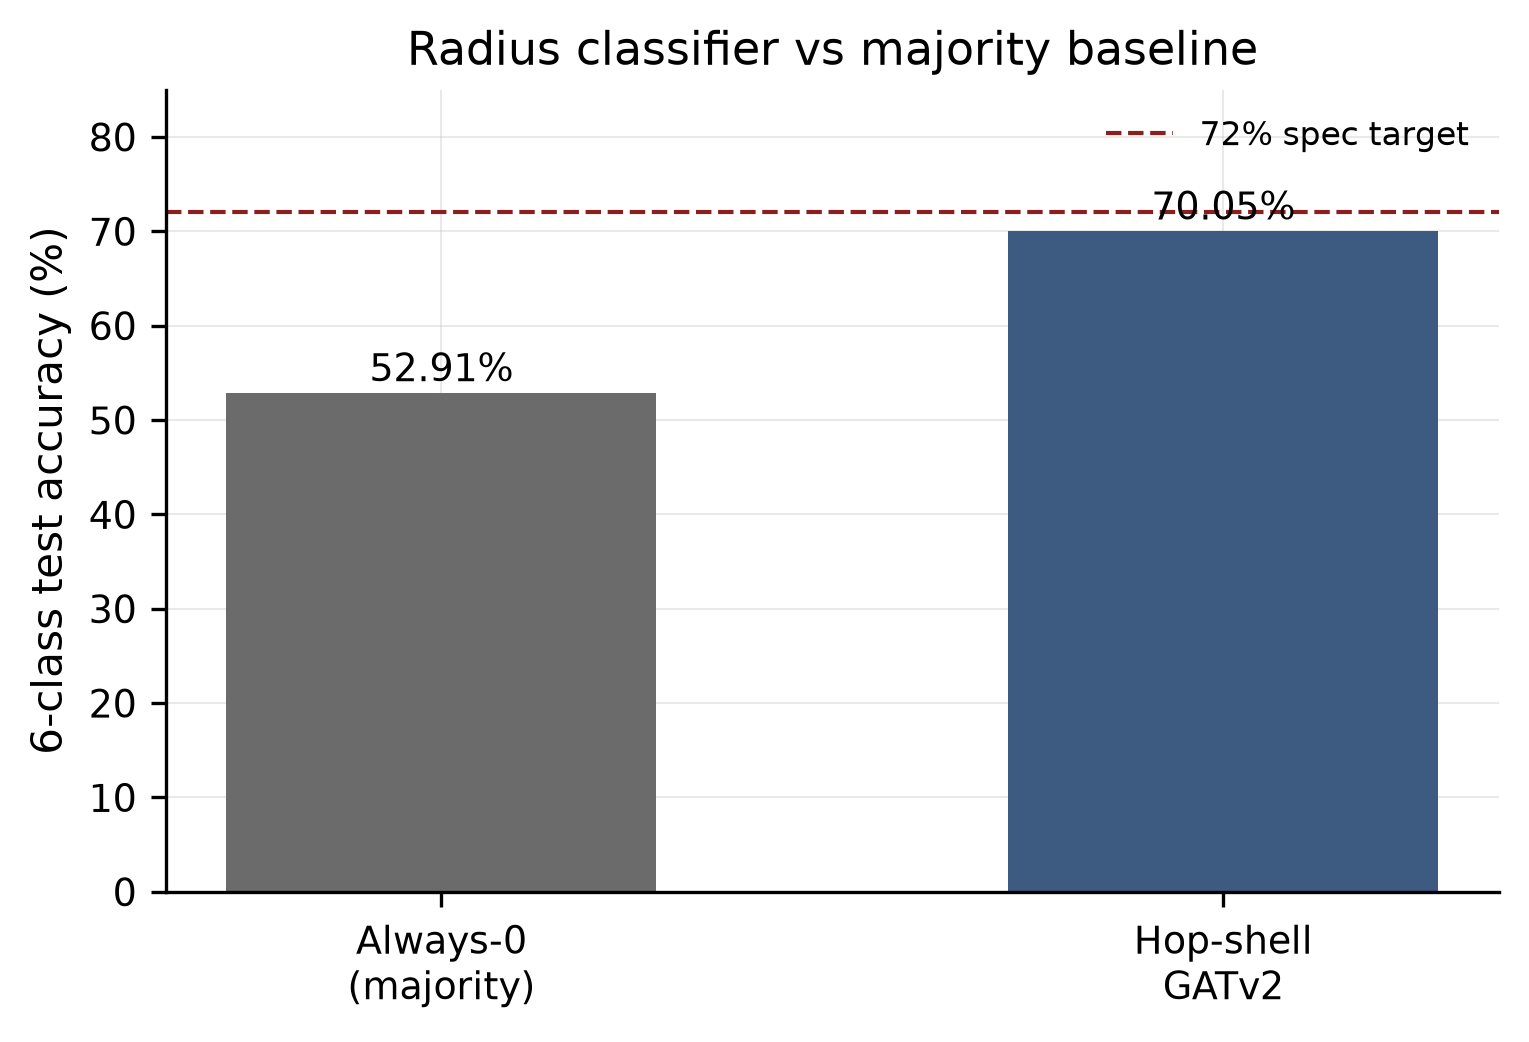

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig01_accuracy_vs_majority.png


In [13]:
show('fig01_accuracy_vs_majority')


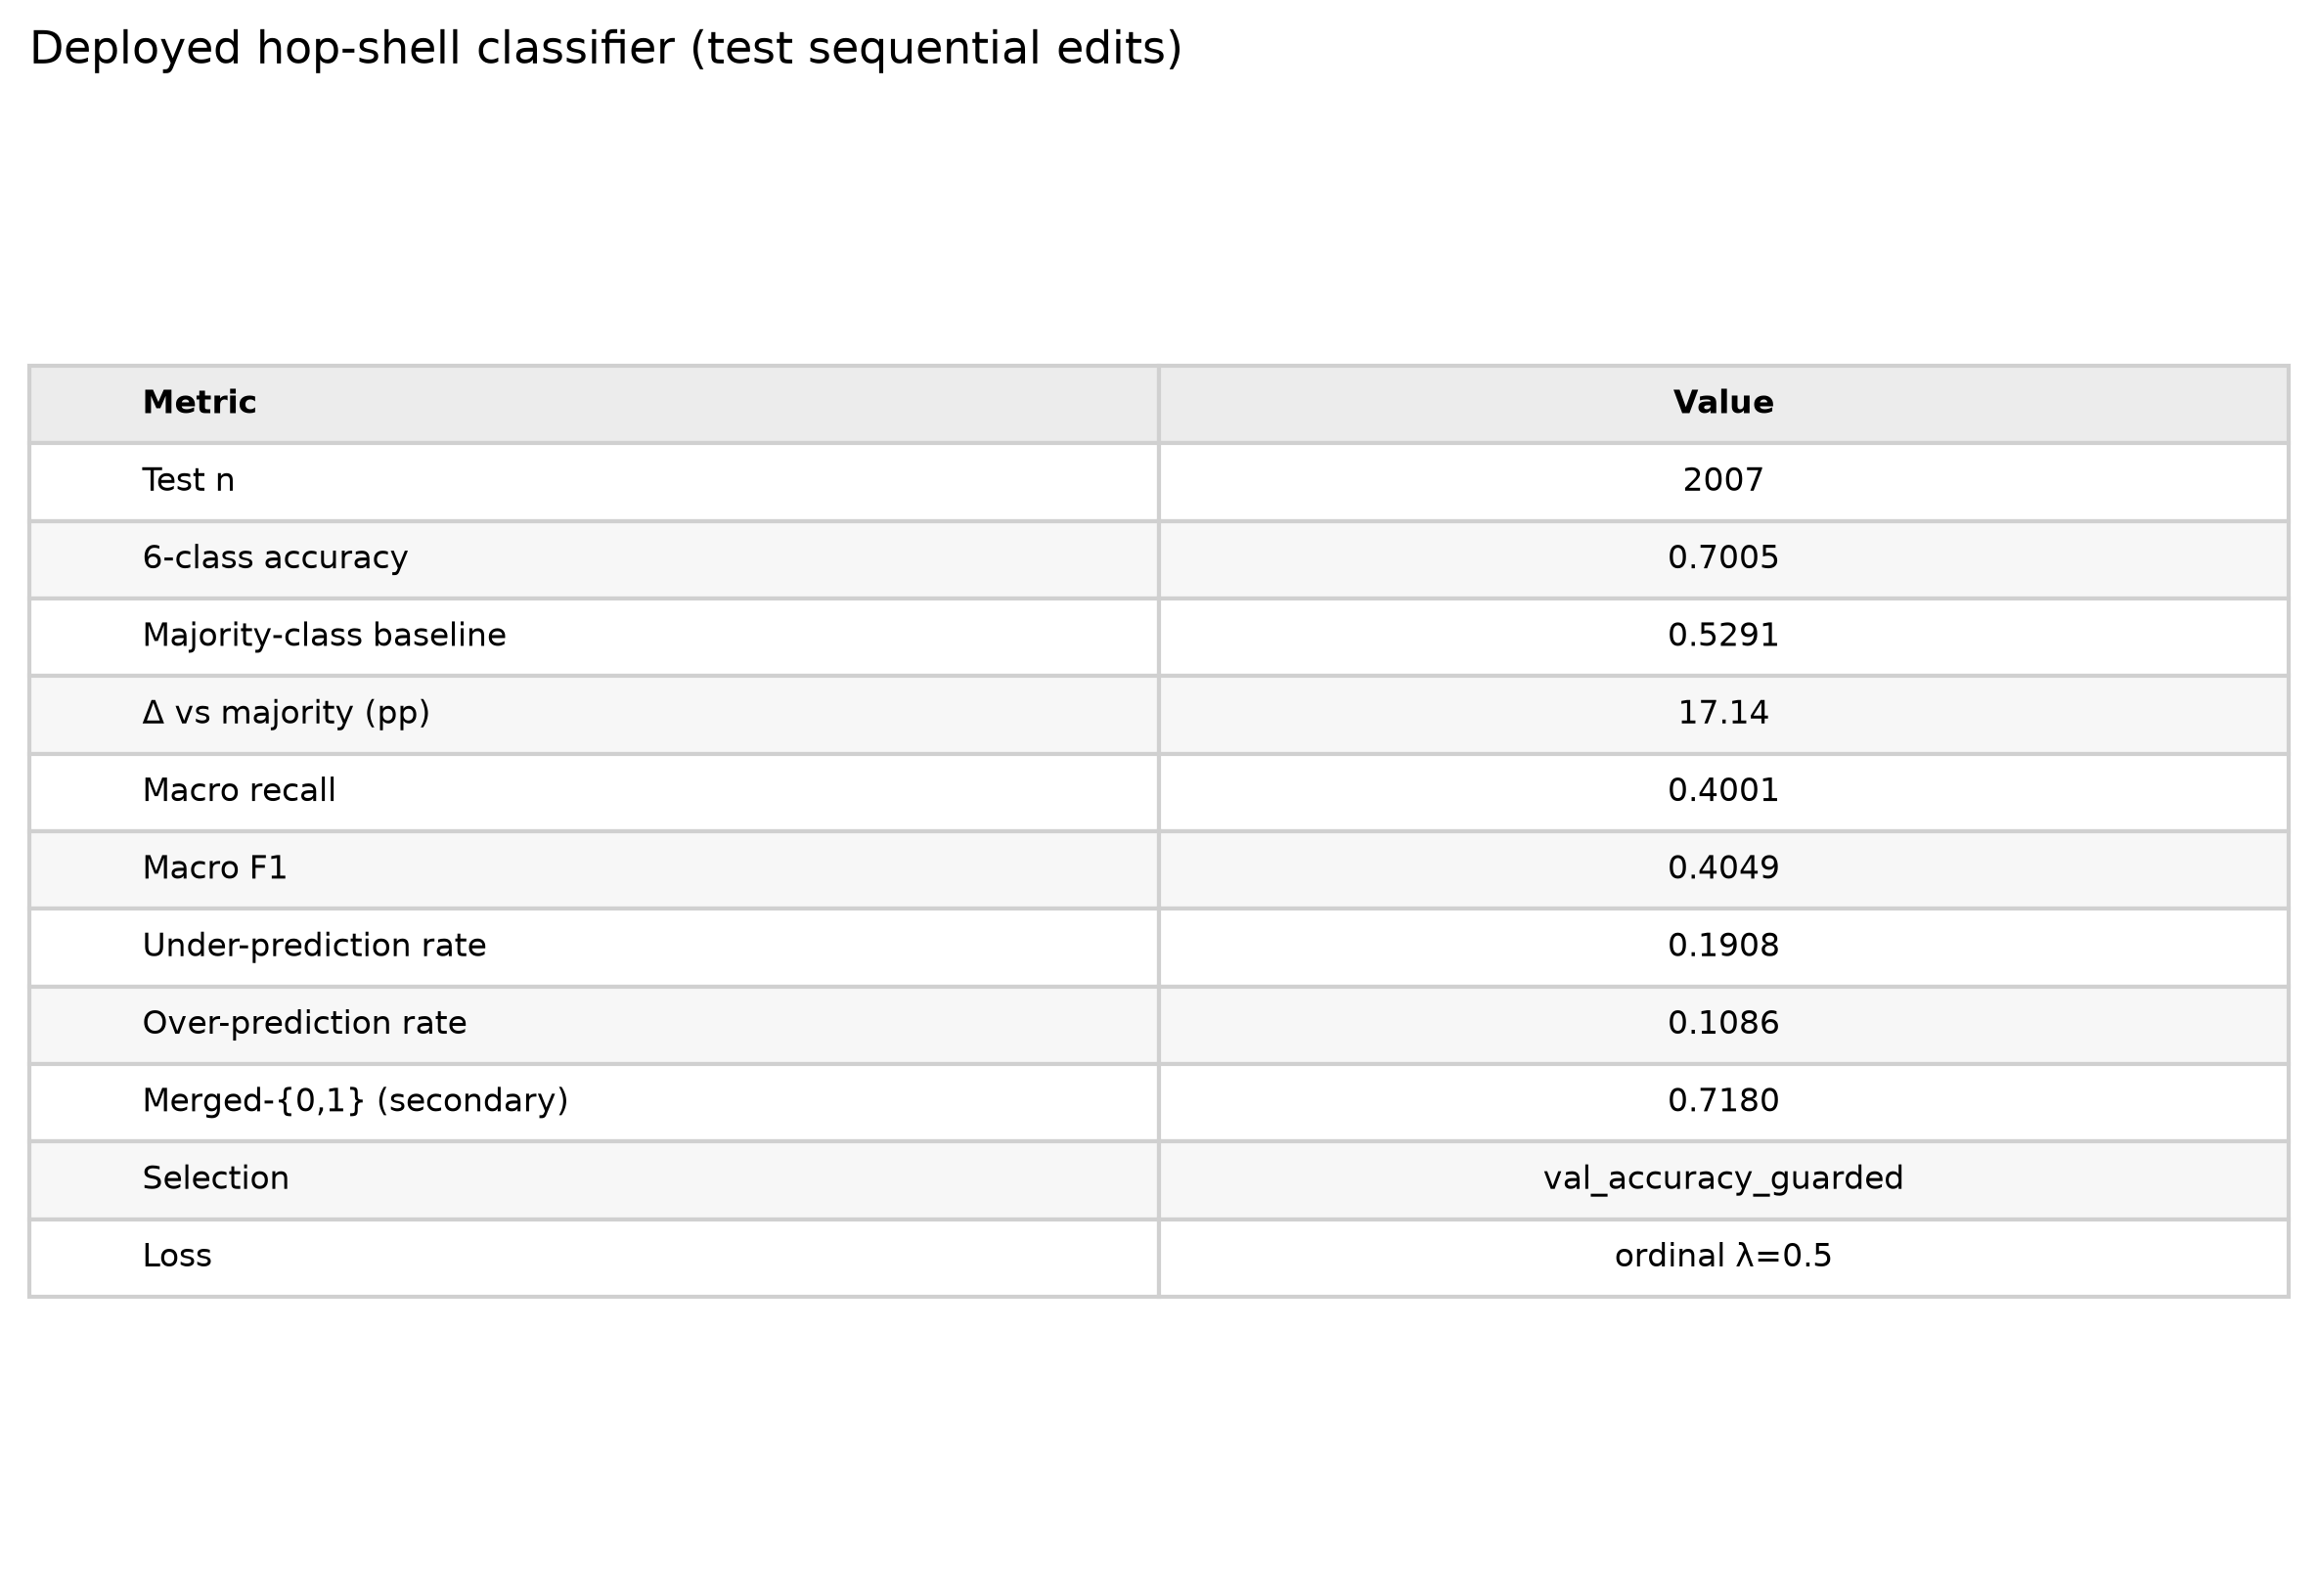

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab08_classifier_metrics.png


In [14]:
show('tab08_classifier_metrics')


**Figure 9.** Confusion matrix (rows = true bucket, columns = predicted). Class-1 and `full` columns are all zeros: the accuracy selector never emits those buckets. The 4→0 cell is the largest structured error.


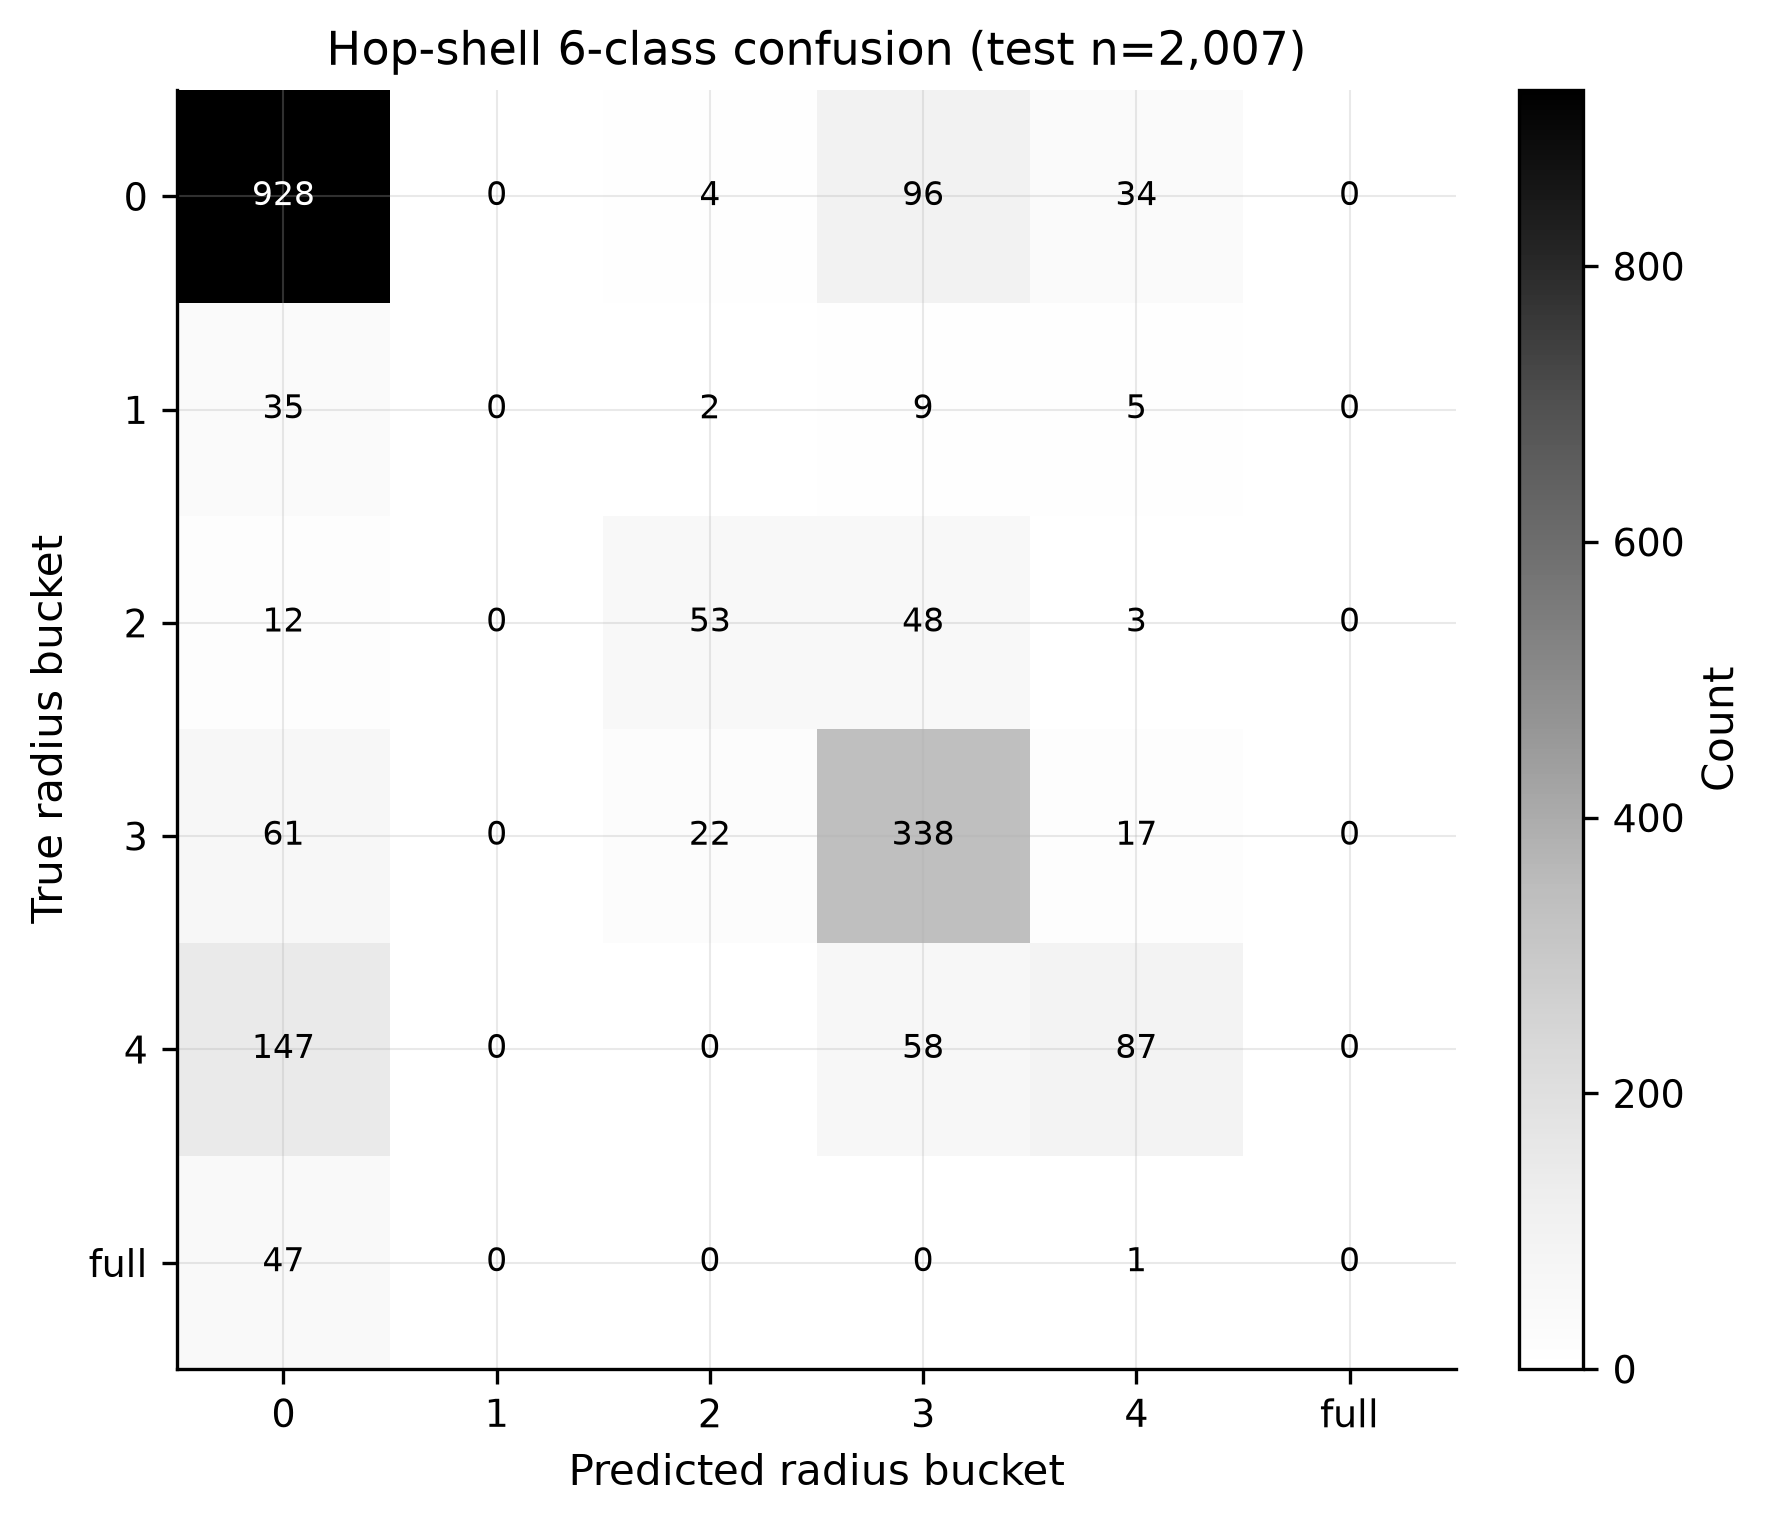

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig09_confusion_matrix.png


In [15]:
show('fig09_confusion_matrix')


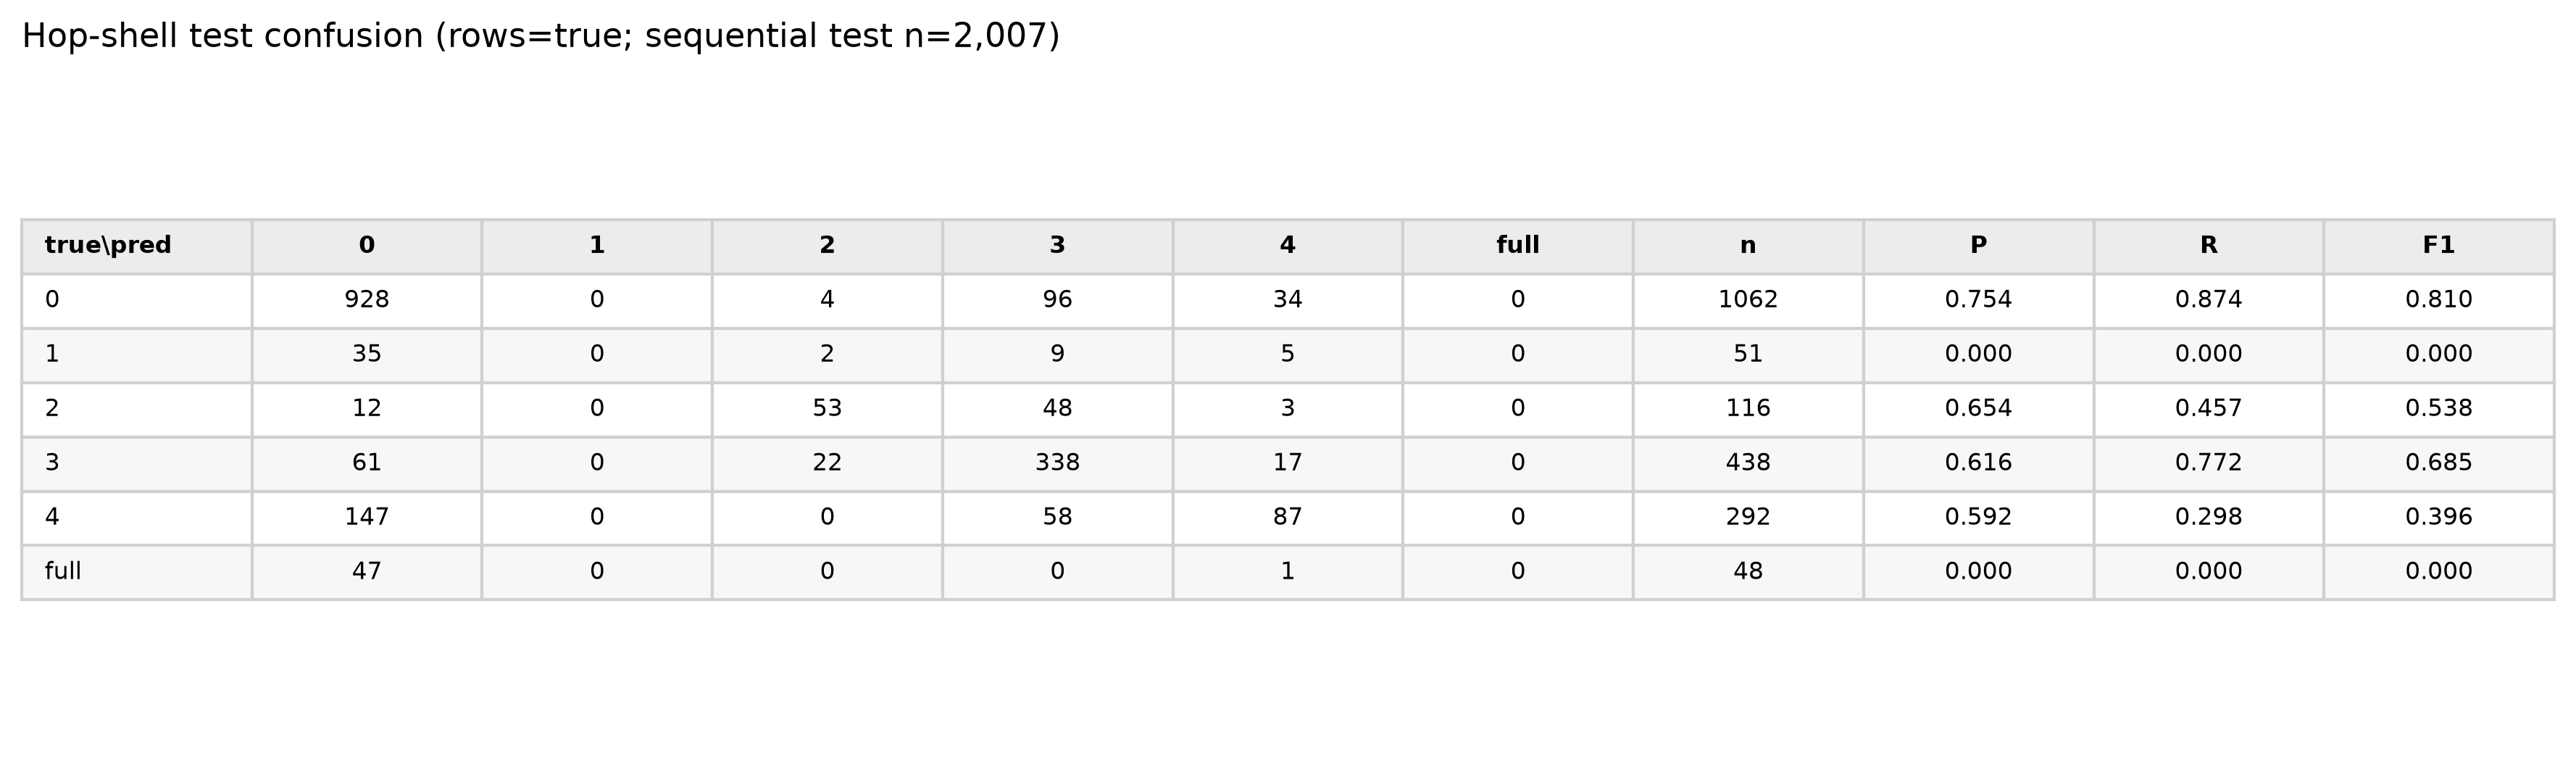

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab04_confusion_matrix.png


In [16]:
show('tab04_confusion_matrix')


**Figure 10.** Per-class precision, recall, and F1. Usable recall on buckets 0 and 3; class 1 and `full` have recall 0.000 on the natural sequential test stream.


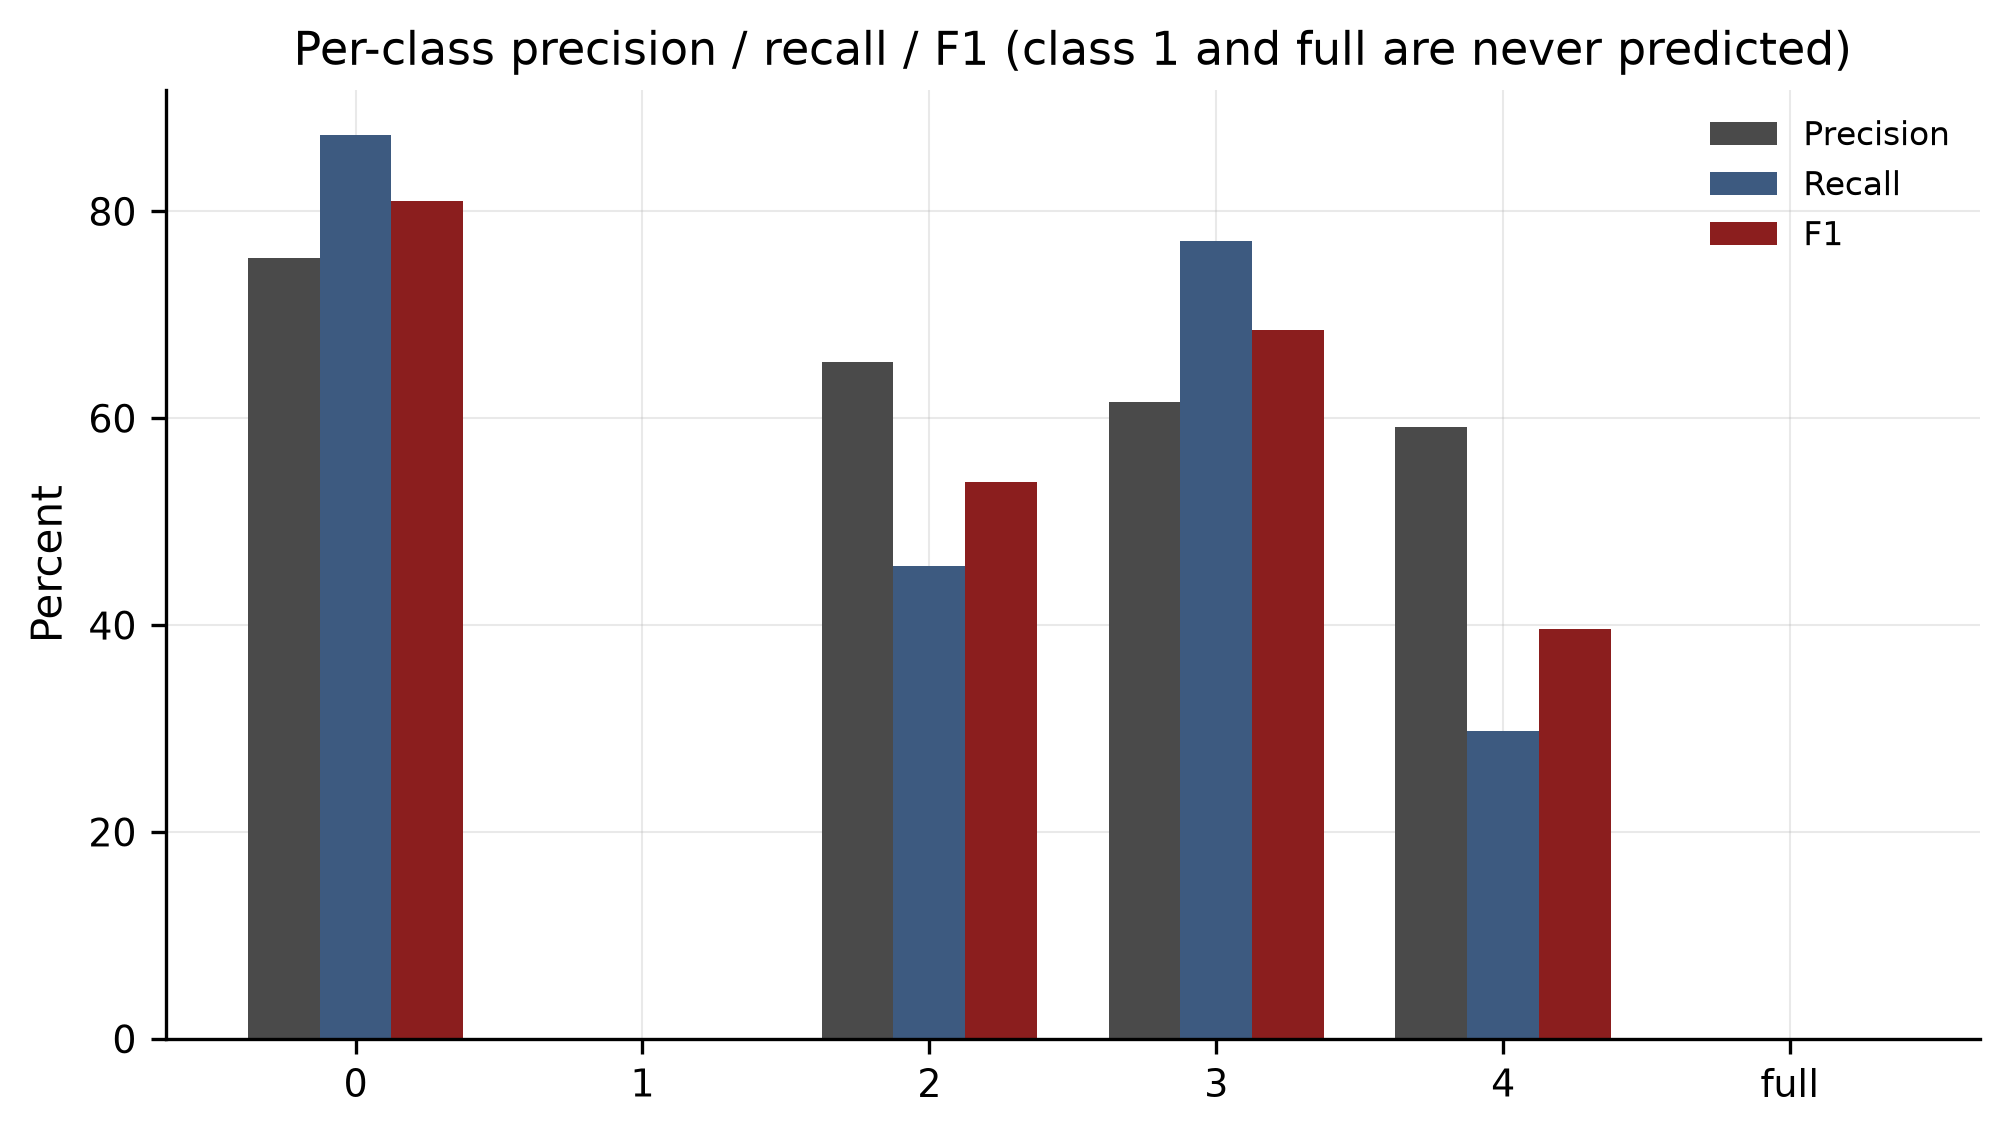

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig10_perclass_prf1.png


In [17]:
show('fig10_perclass_prf1')


**Figure 11.** Under-prediction is more common than over-prediction on the ordinal radius label. Under-prediction is the expensive direction for the retry ladder.


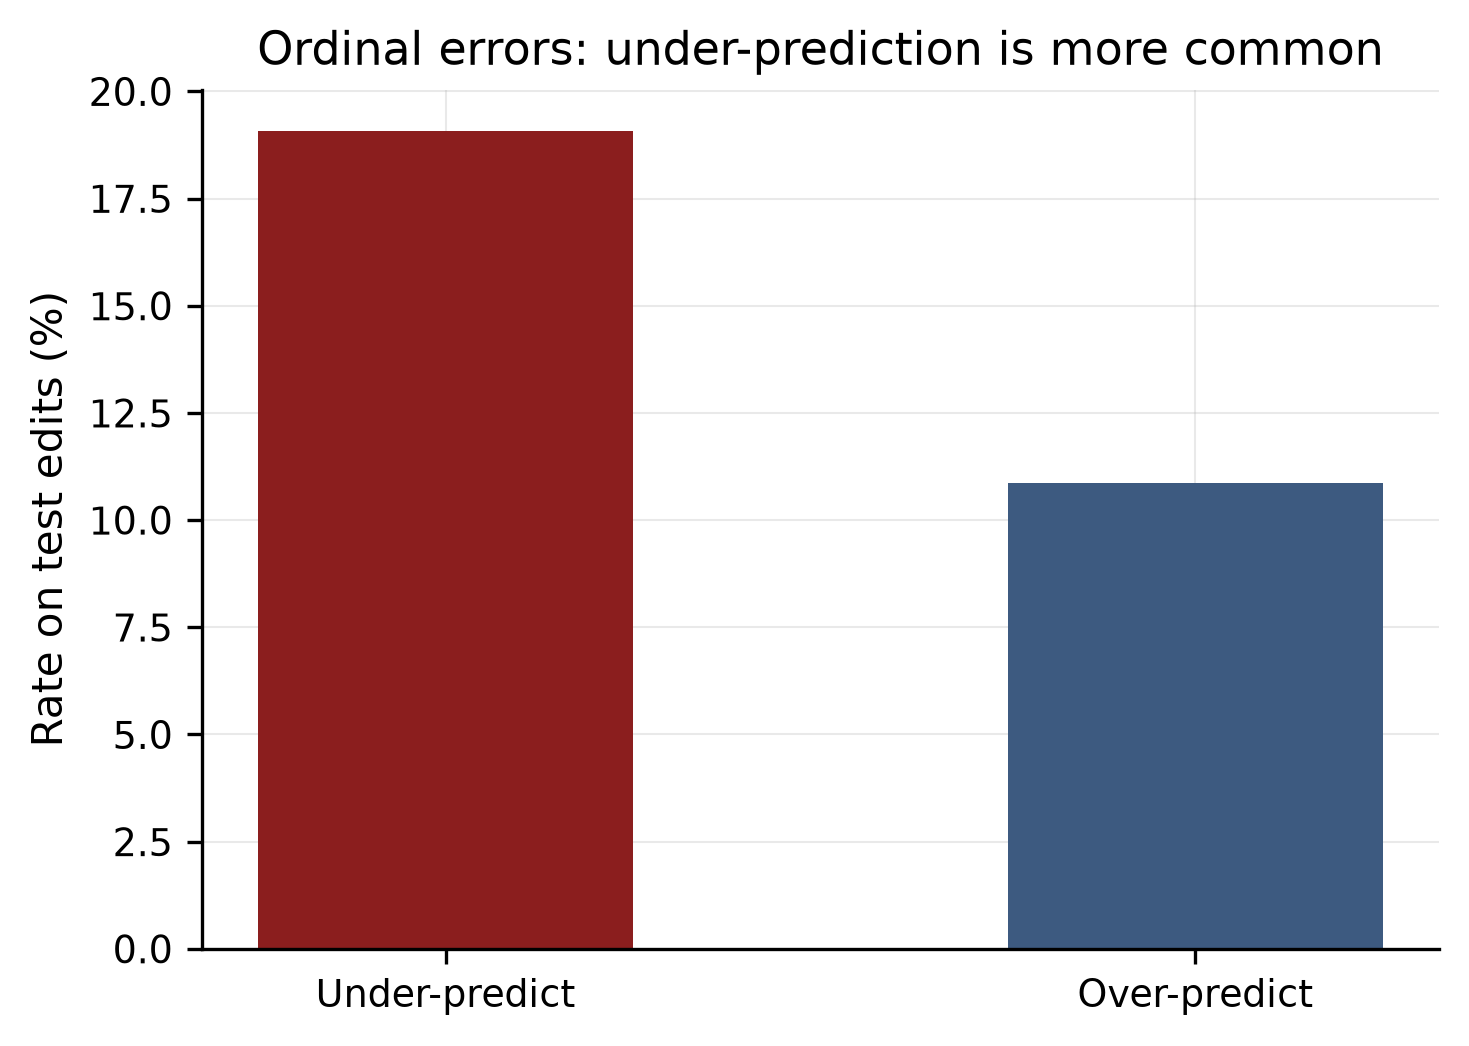

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig11_under_vs_over.png


In [18]:
show('fig11_under_vs_over')


**Figure 12.** Test label histogram. Class 0 is 1,062 / 2,007 (majority baseline 52.91%). Class 1 is 2.5% of this split (2.2% of all sequential labels).


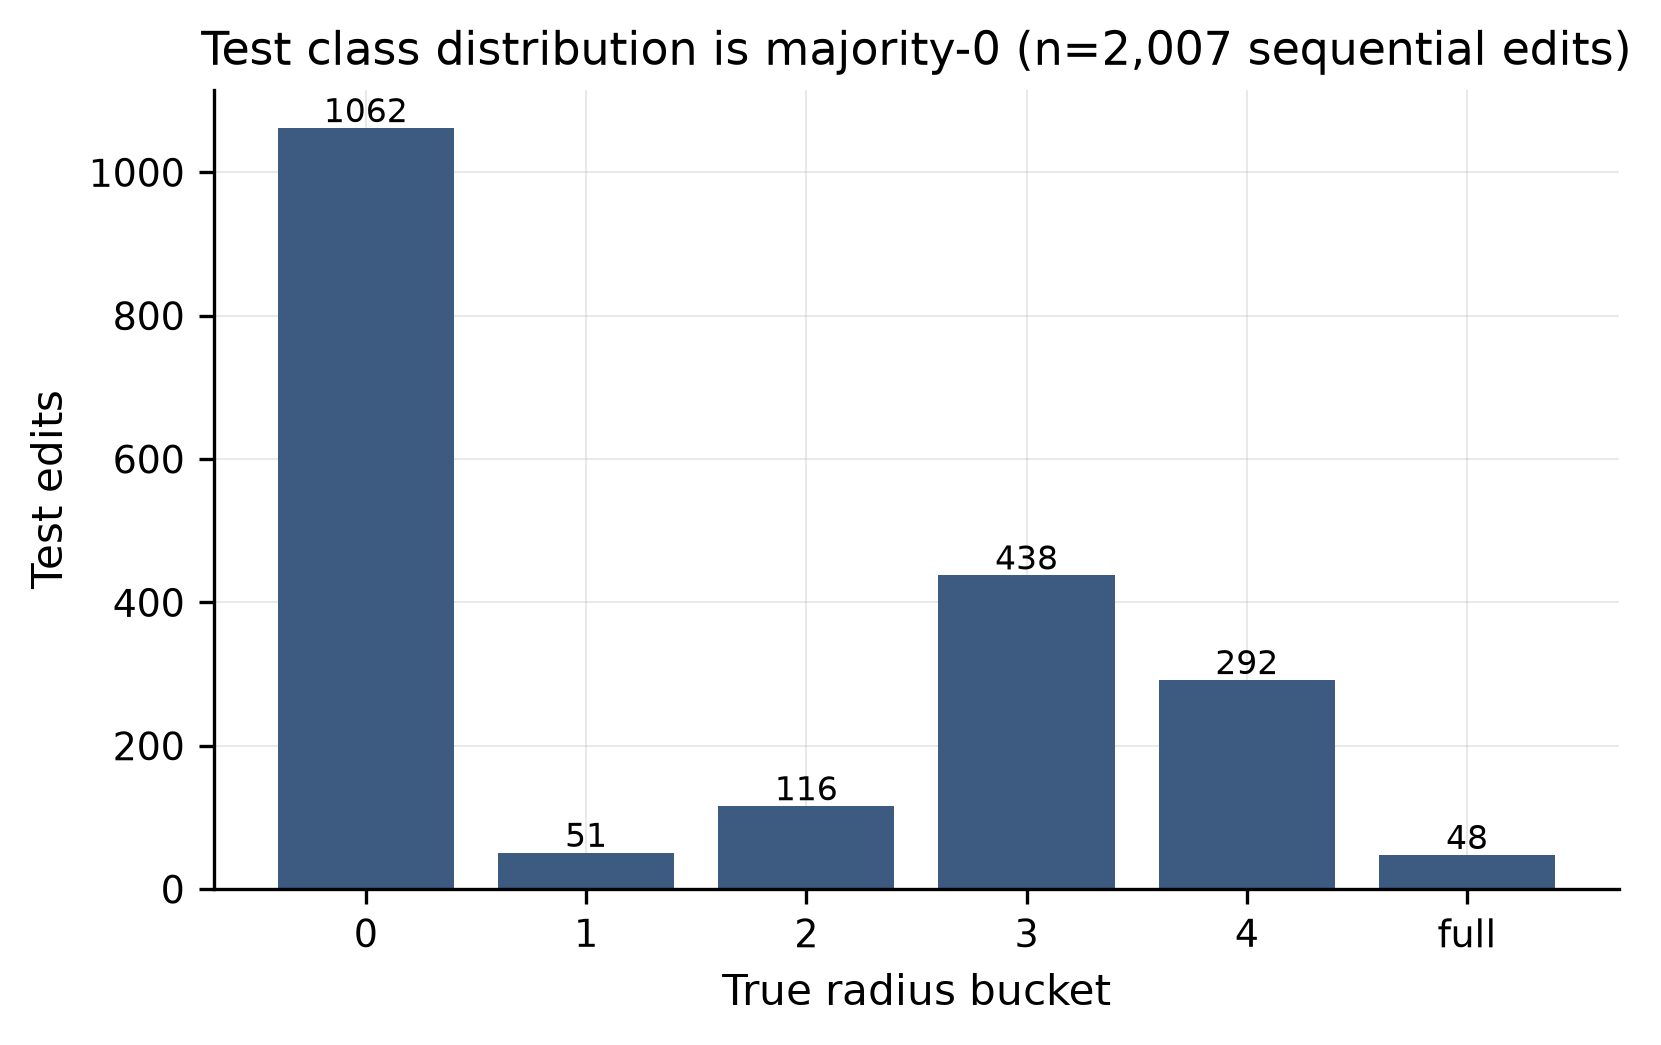

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig12_class_distribution.png


In [19]:
show('fig12_class_distribution')


**Figure 31.** Training lineage of 6-class test accuracy. Bars other than “Hop-shell (canonical)” are **historical citations from Context.md / leftover reports**, not recomputed in this notebook. Several of those artifacts were deleted in §20 cleanup. Only the hop-shell checkpoint is deployed.


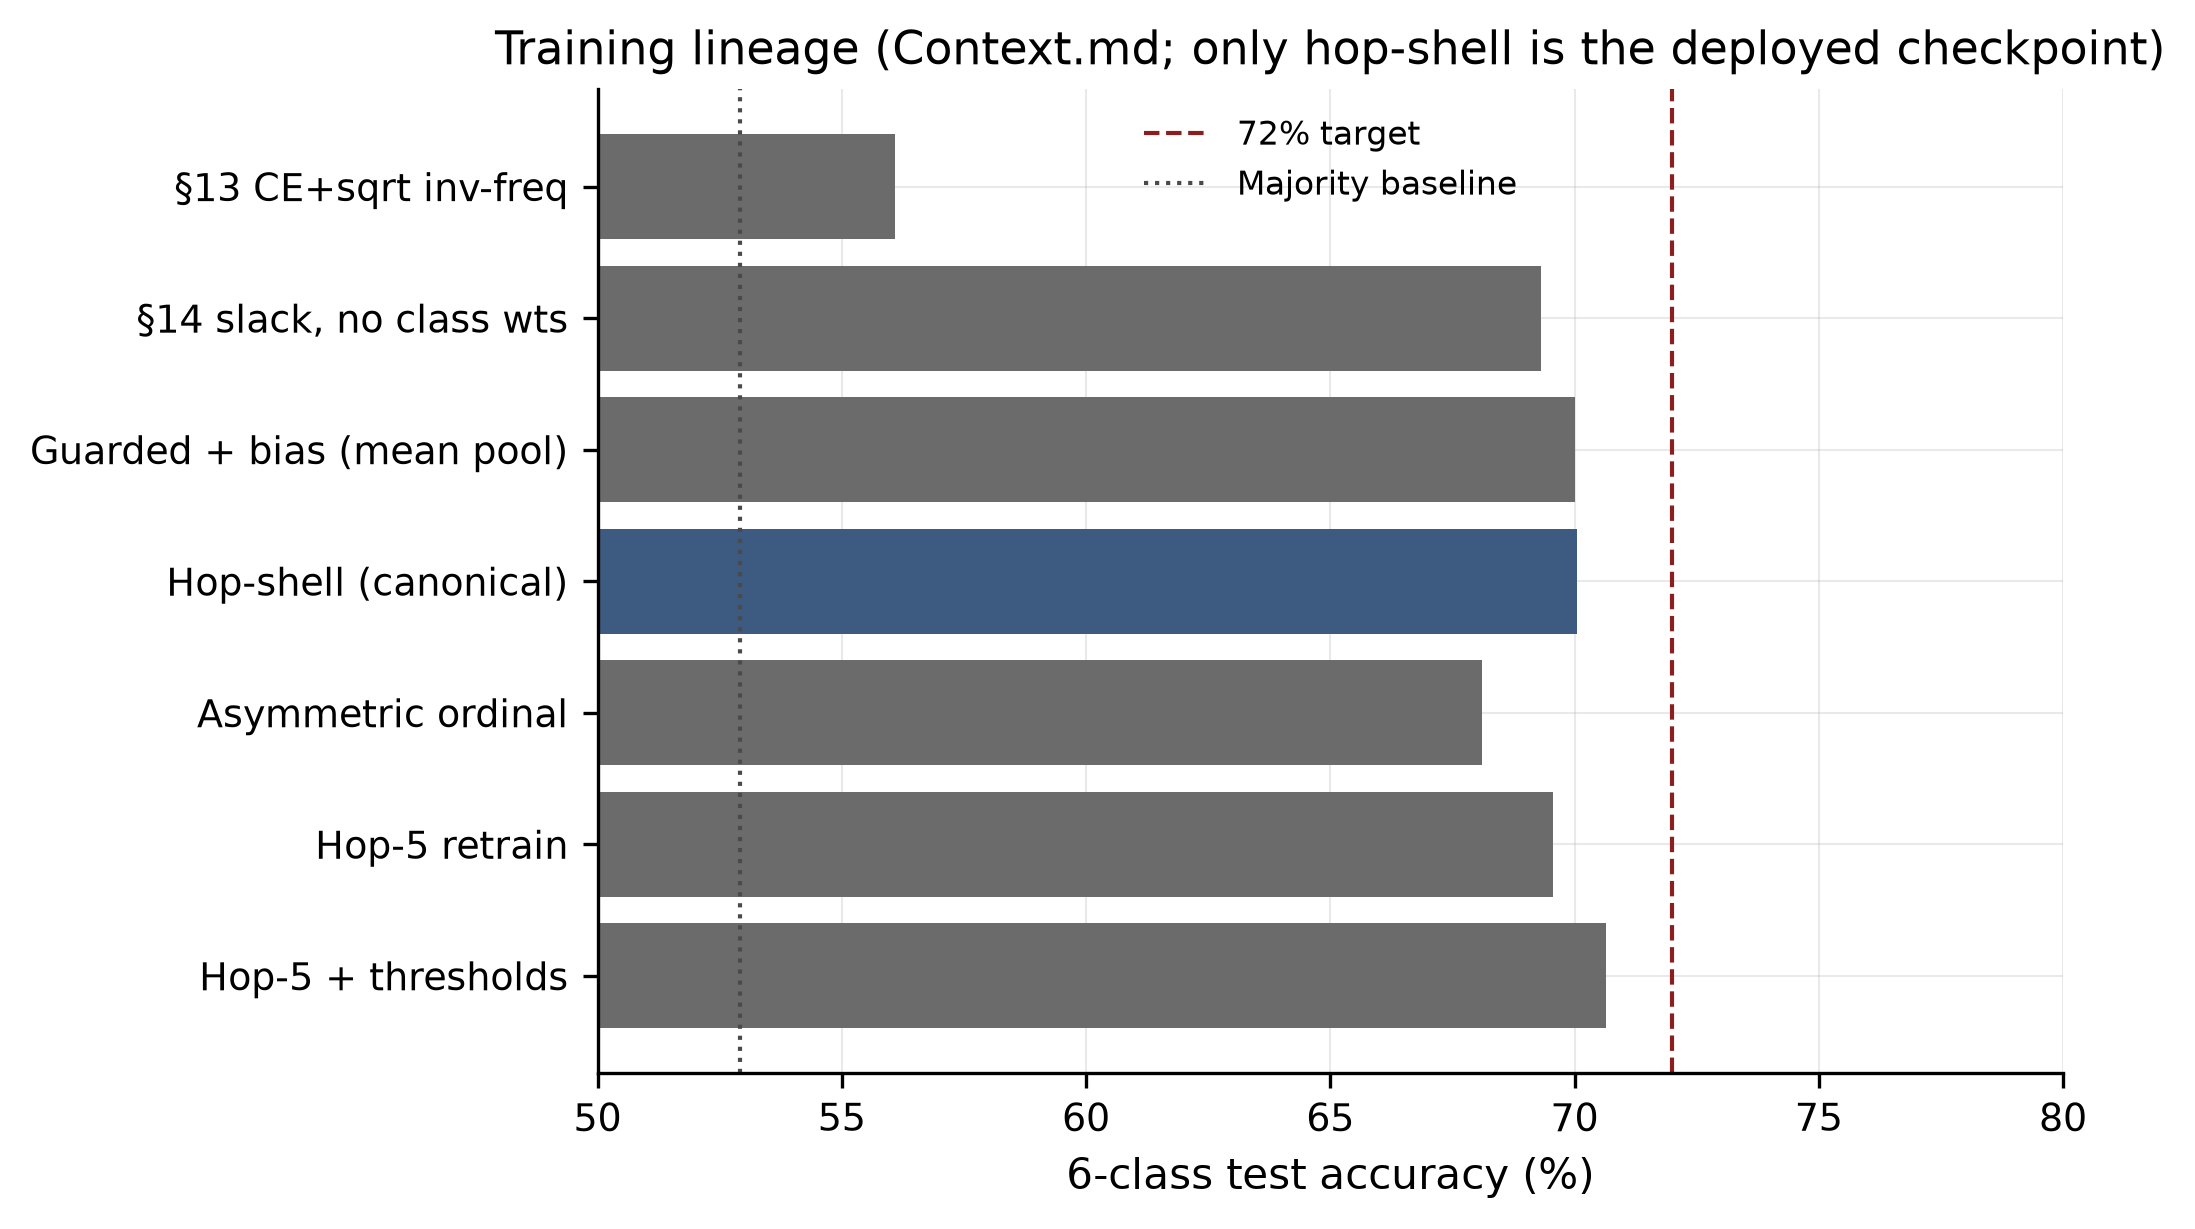

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig31_training_lineage.png


In [20]:
show('fig31_training_lineage')


## 3. Scaling and OOD n=2000

In-distribution holdout: n=100 → 630 edits; n=200 → 810; n=500 → 585. The spec expected RPI’s speed advantage vs full recompute to grow with n. At n≤500 the opposite happens on wall-clock.

**n=2000 is out of distribution** (eval spec 2.5): the GNN was trained on n∈{100,200,500}. Protocol: 8 new ER graphs, 20 sequential edits, seed 0, frozen `radius_gnn_hopshell.pt`. Fixed r=2 and majority r=0 were **not** run. Do not pool these 160 pairs into the main 2,025-edit tables.


**Table 2.** Holdout metrics by n. Use this for in-distribution scaling claims only.


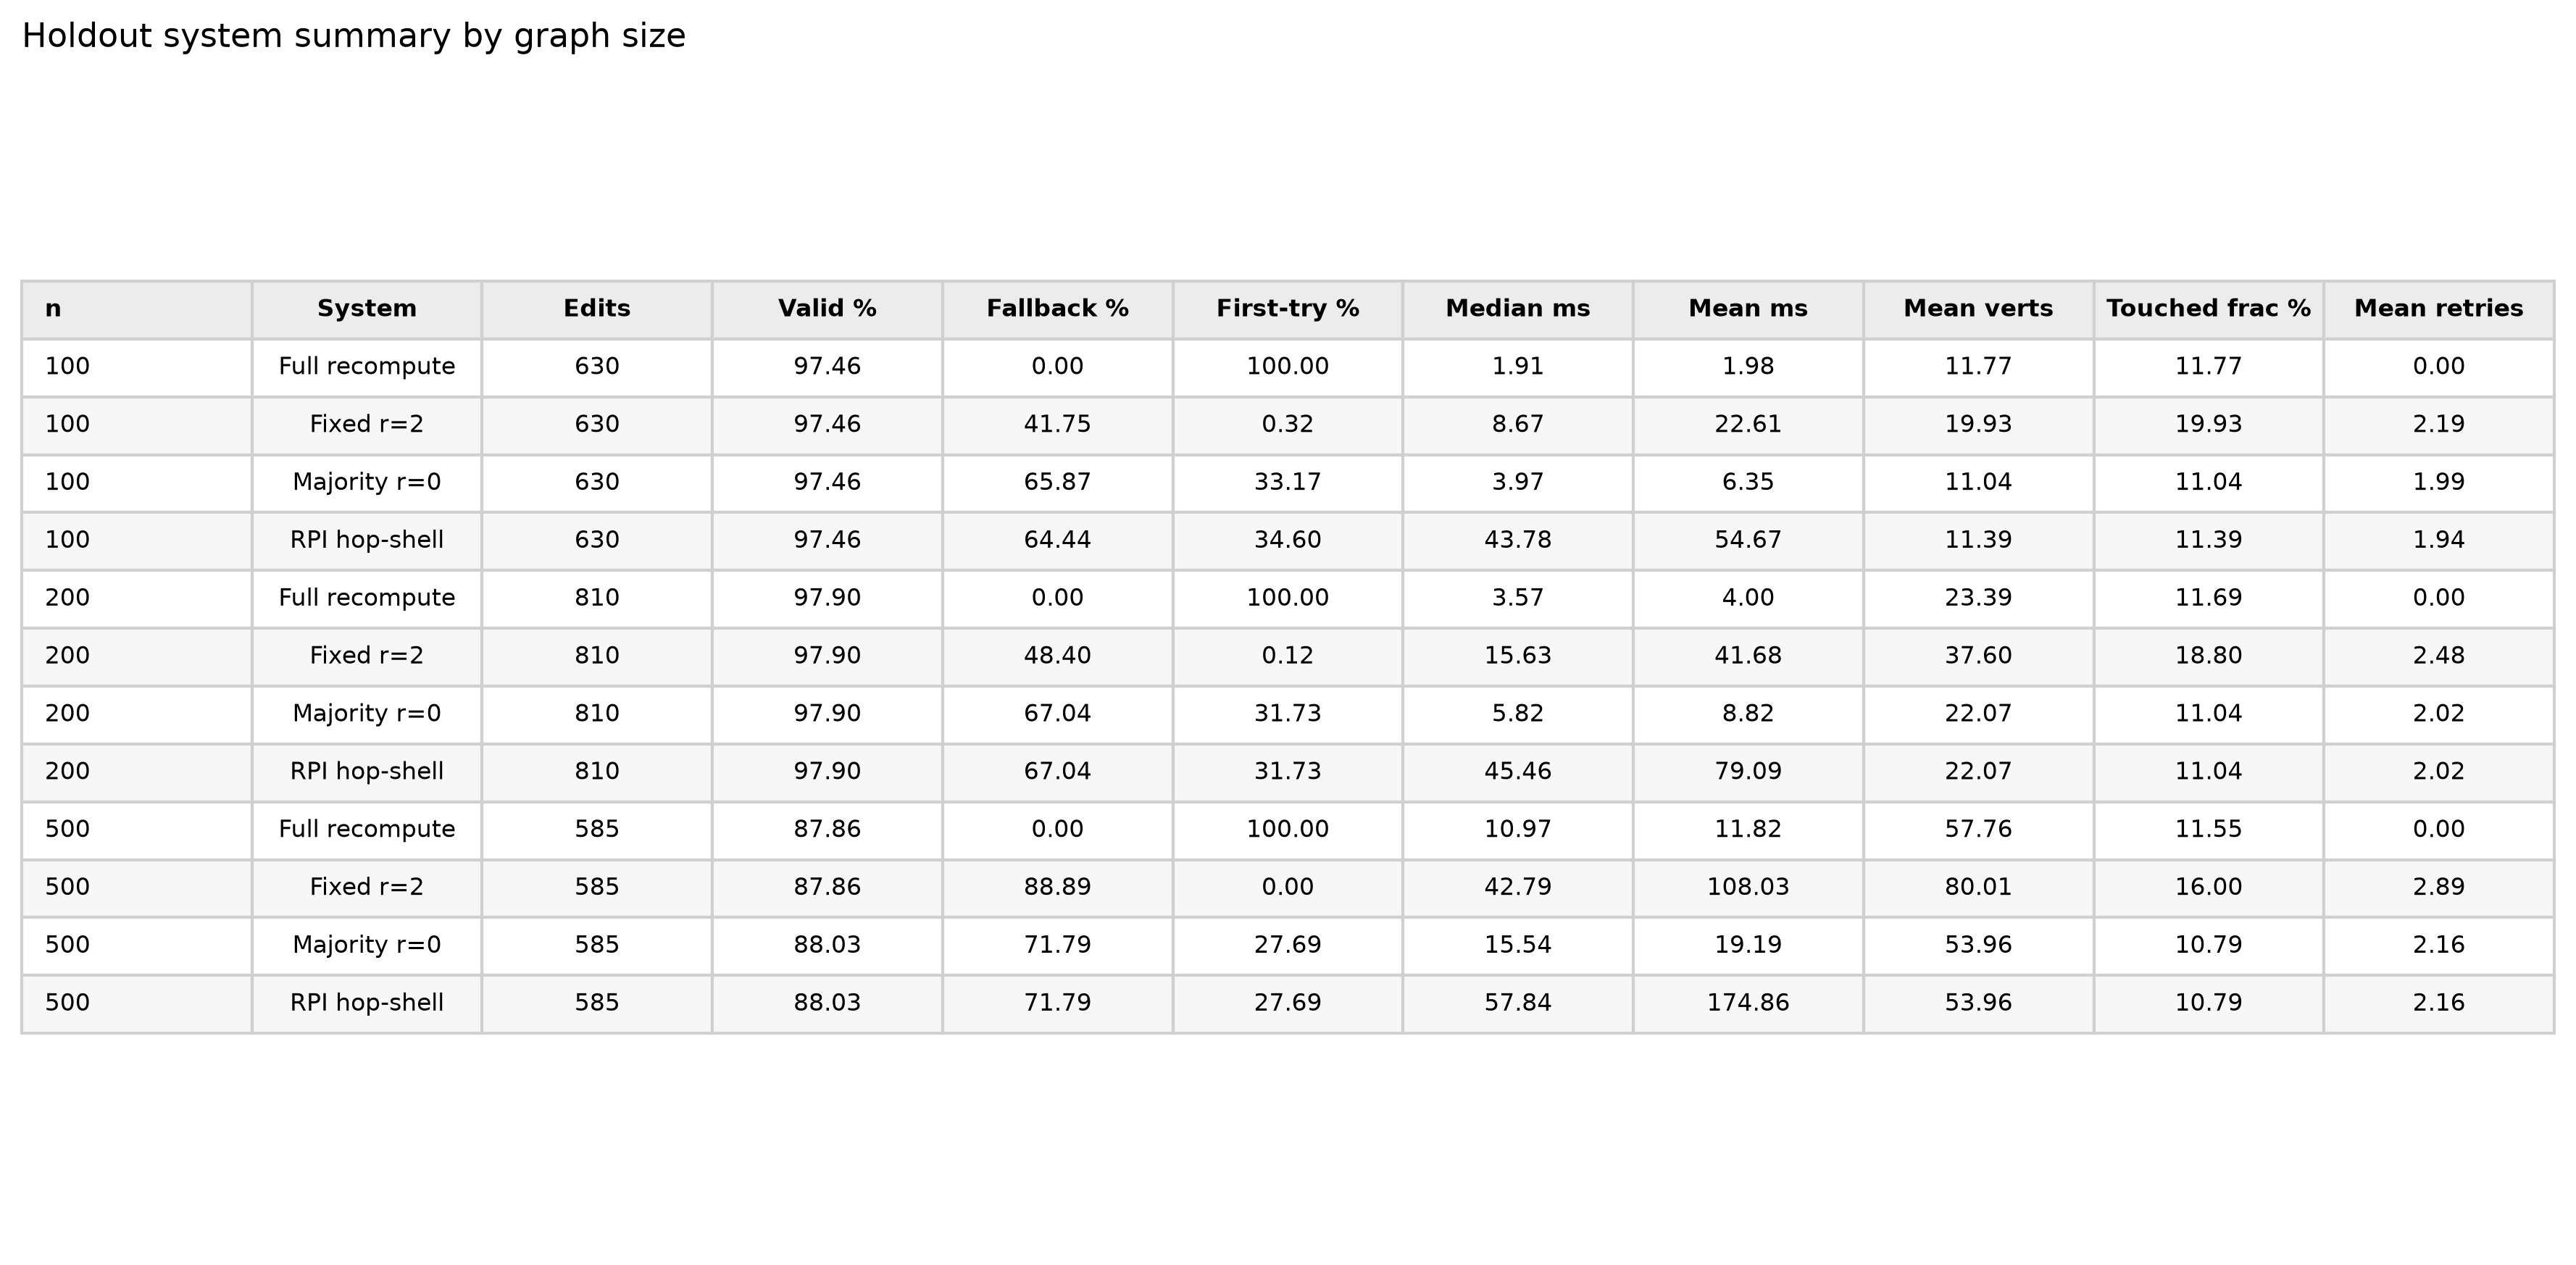

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab02_system_summary_by_n.png


In [21]:
show('tab02_system_summary_by_n')


**Figure 15.** Median time vs n on the holdout only. Full DSATUR is cheapest at every in-distribution size.


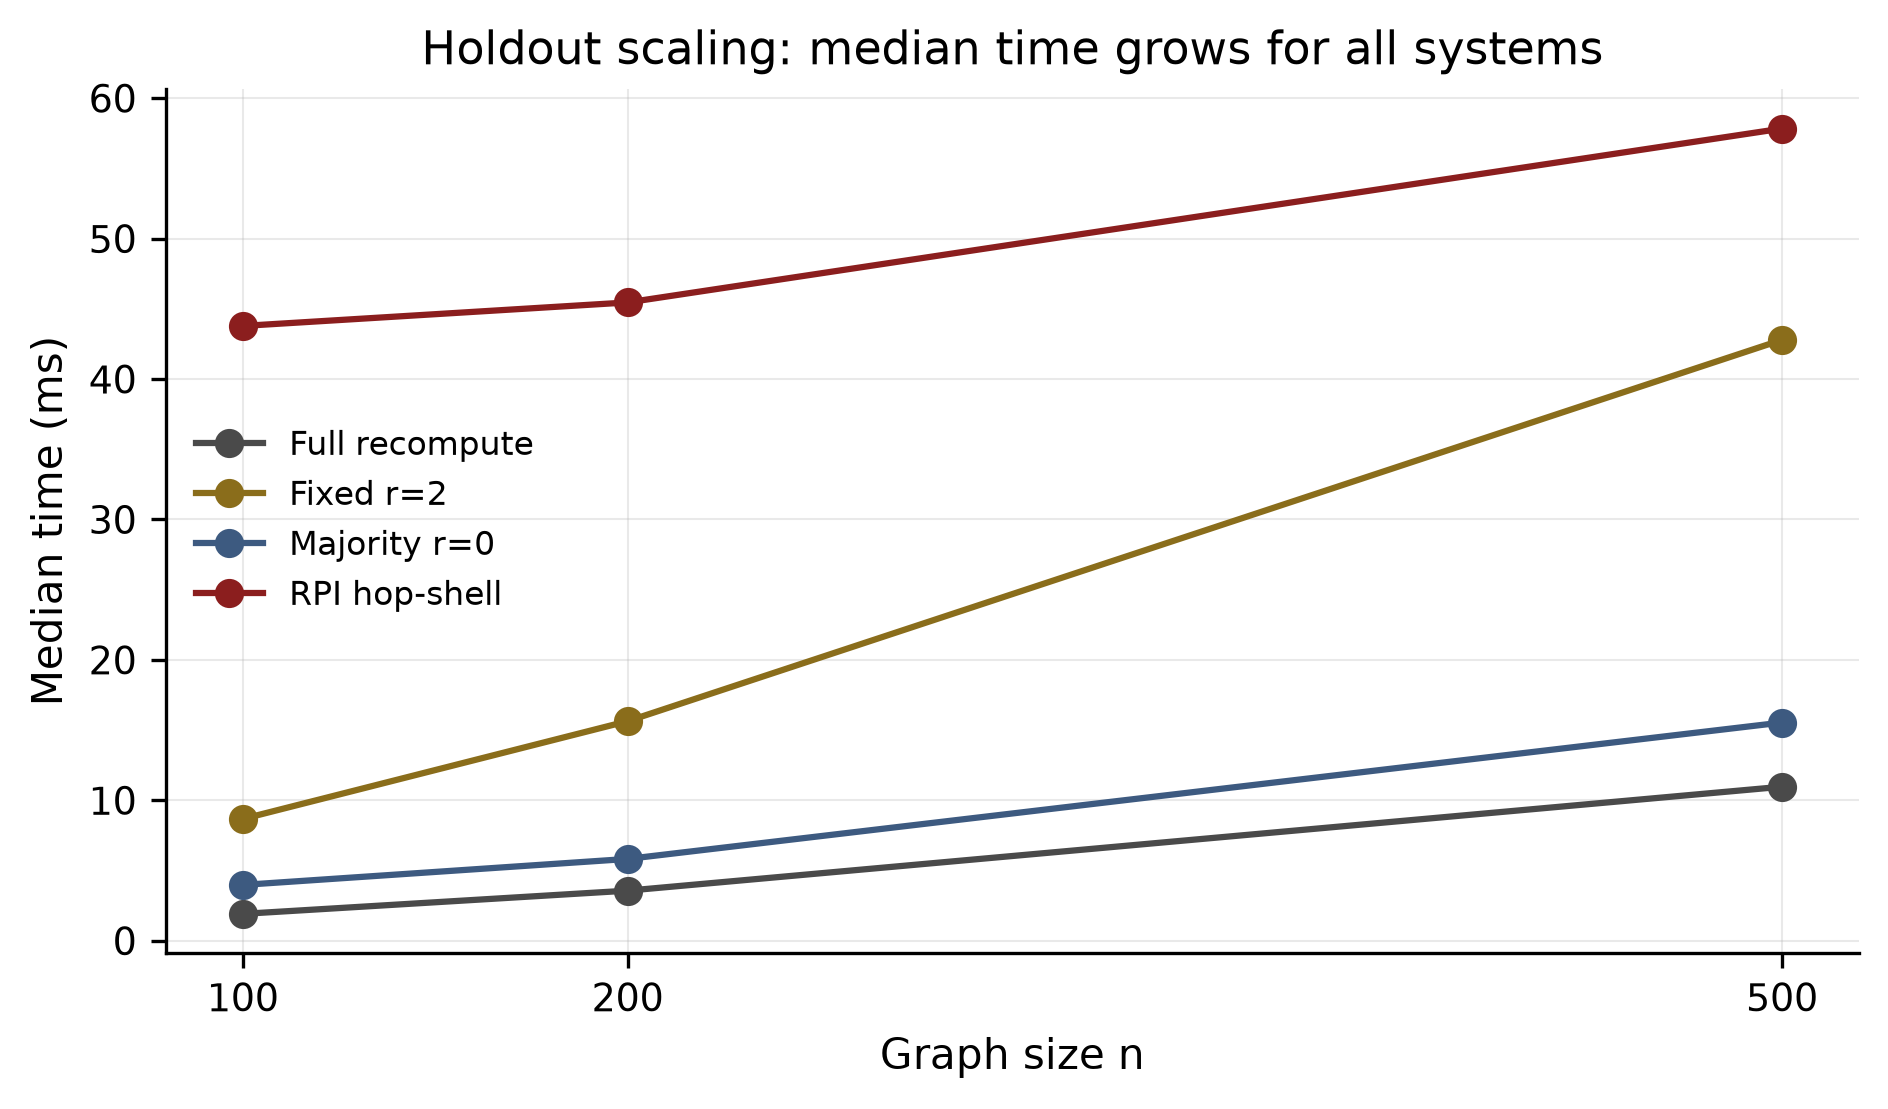

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig15_scaling_median_time.png


In [22]:
show('fig15_scaling_median_time')


**Figure 16.** Fallback vs n. Fixed r=2 hits 88.9% fallback at n=500 (starts too large and still exhausts the ladder). RPI/majority stay in the mid-60s to low-70s — still far above 15%.


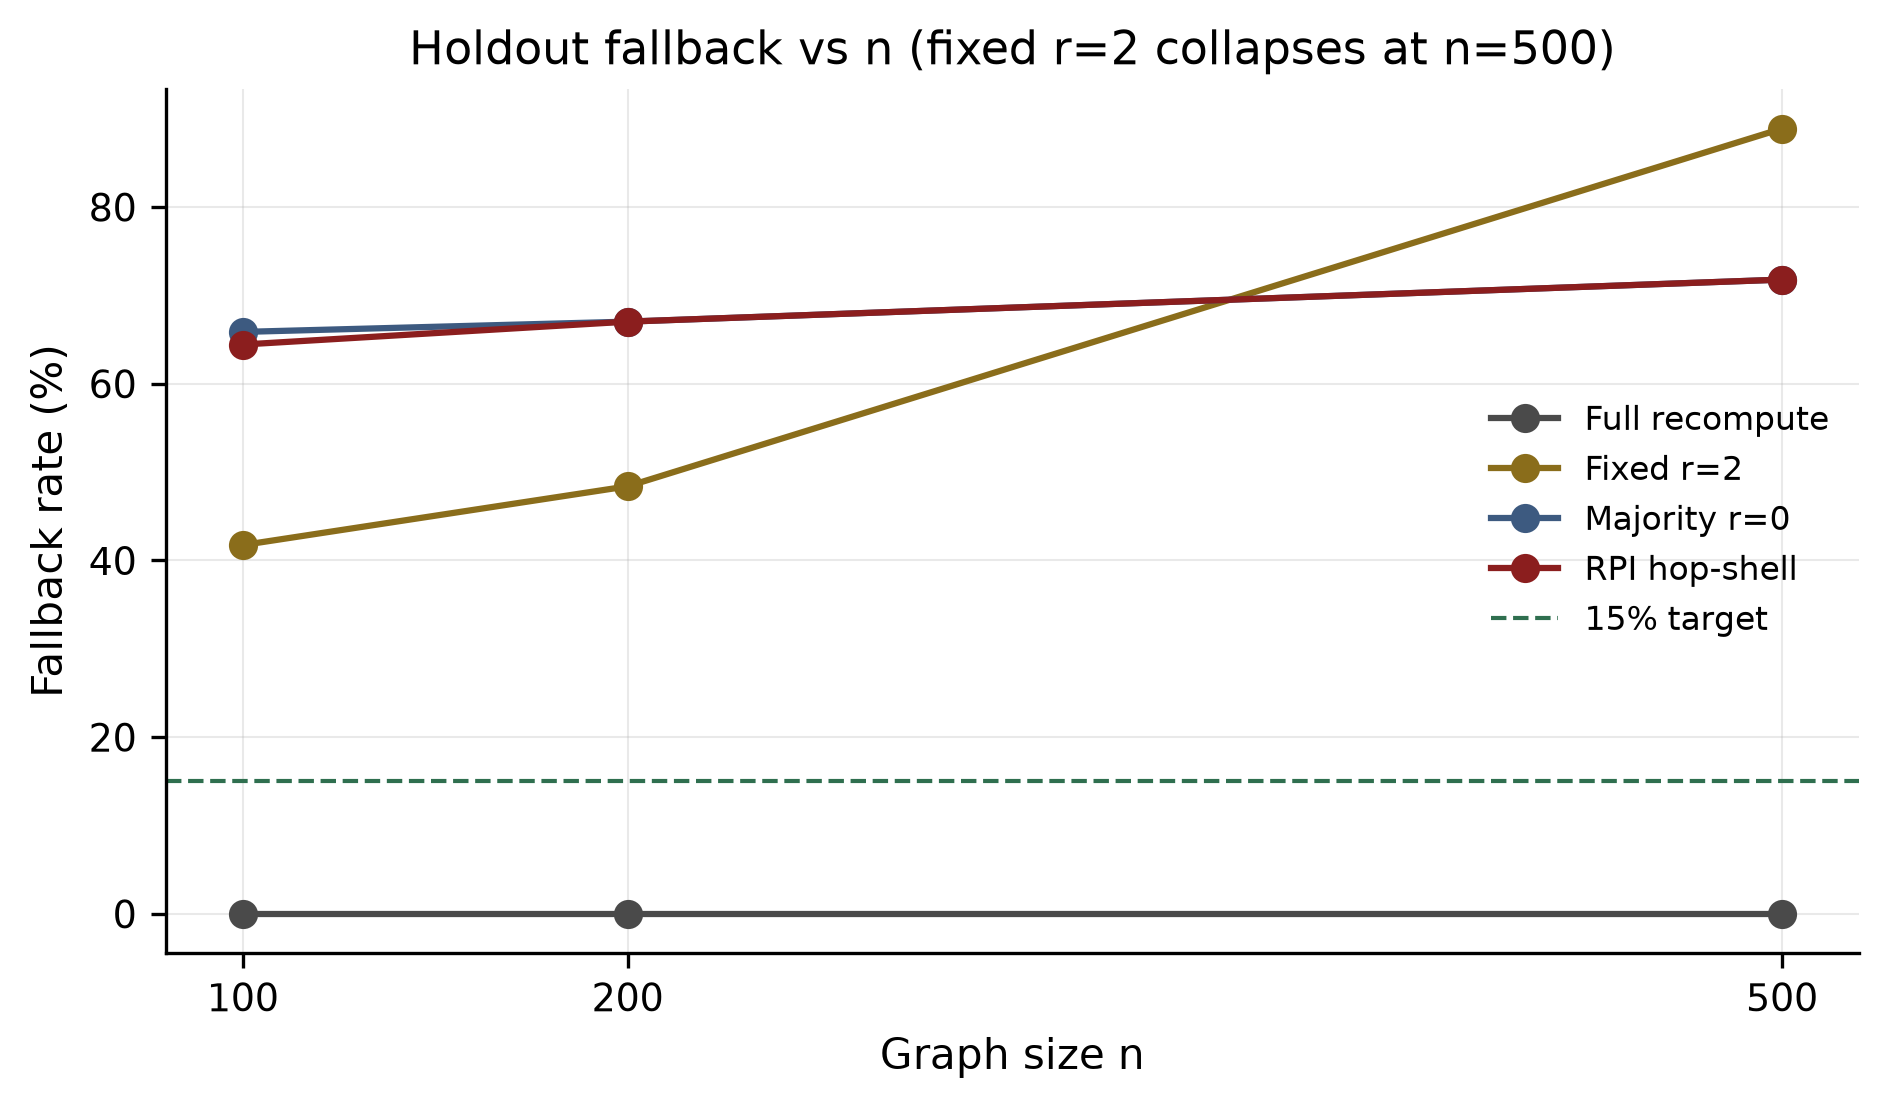

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig16_scaling_fallback.png


In [23]:
show('fig16_scaling_fallback')


**Figure 17.** Mean vertices vs n. At n=200 and n=500, RPI and majority recolor the same mean vertex counts. Fixed r=2 overshoots.


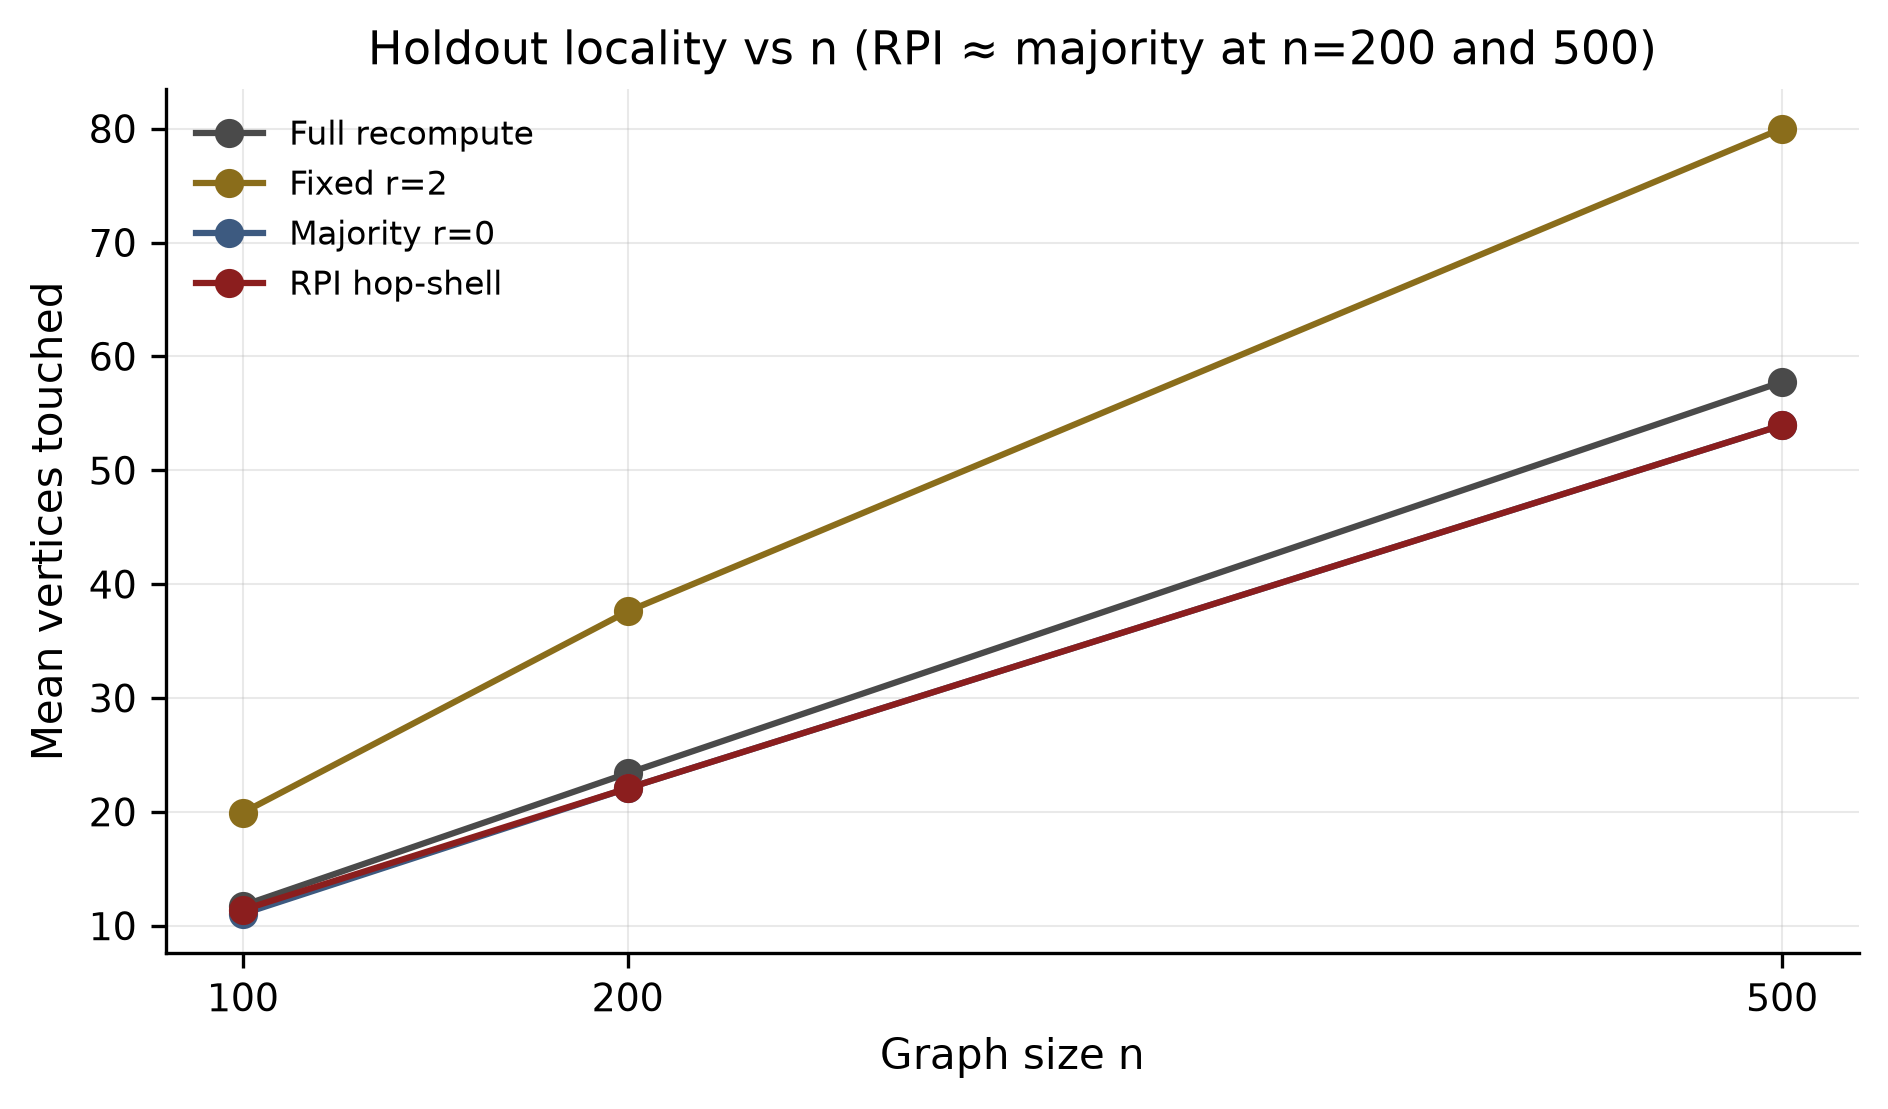

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig17_scaling_verts.png


In [24]:
show('fig17_scaling_verts')


**Table 3 / Figure 18.** OOD n=2000, RPI vs full only. Median 105.6 ms vs 42.0 ms. The relative gap shrinks (about 23× at n=100 → about 2.5× at n=2000) but RPI remains slower. Dashed markers are OOD.


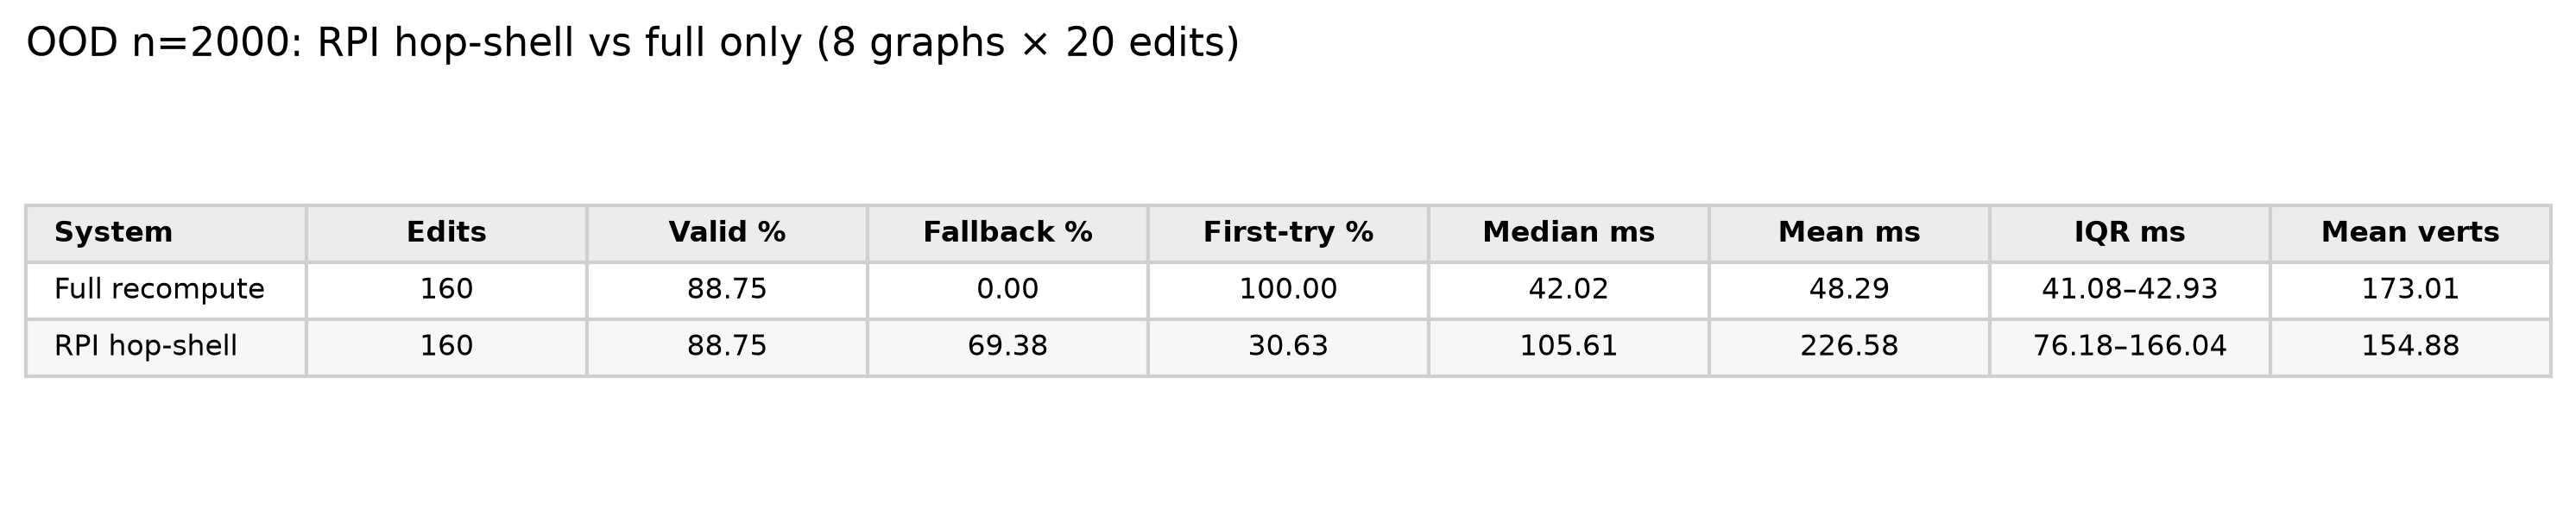

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab03_ood_n2000.png


In [25]:
show('tab03_ood_n2000')


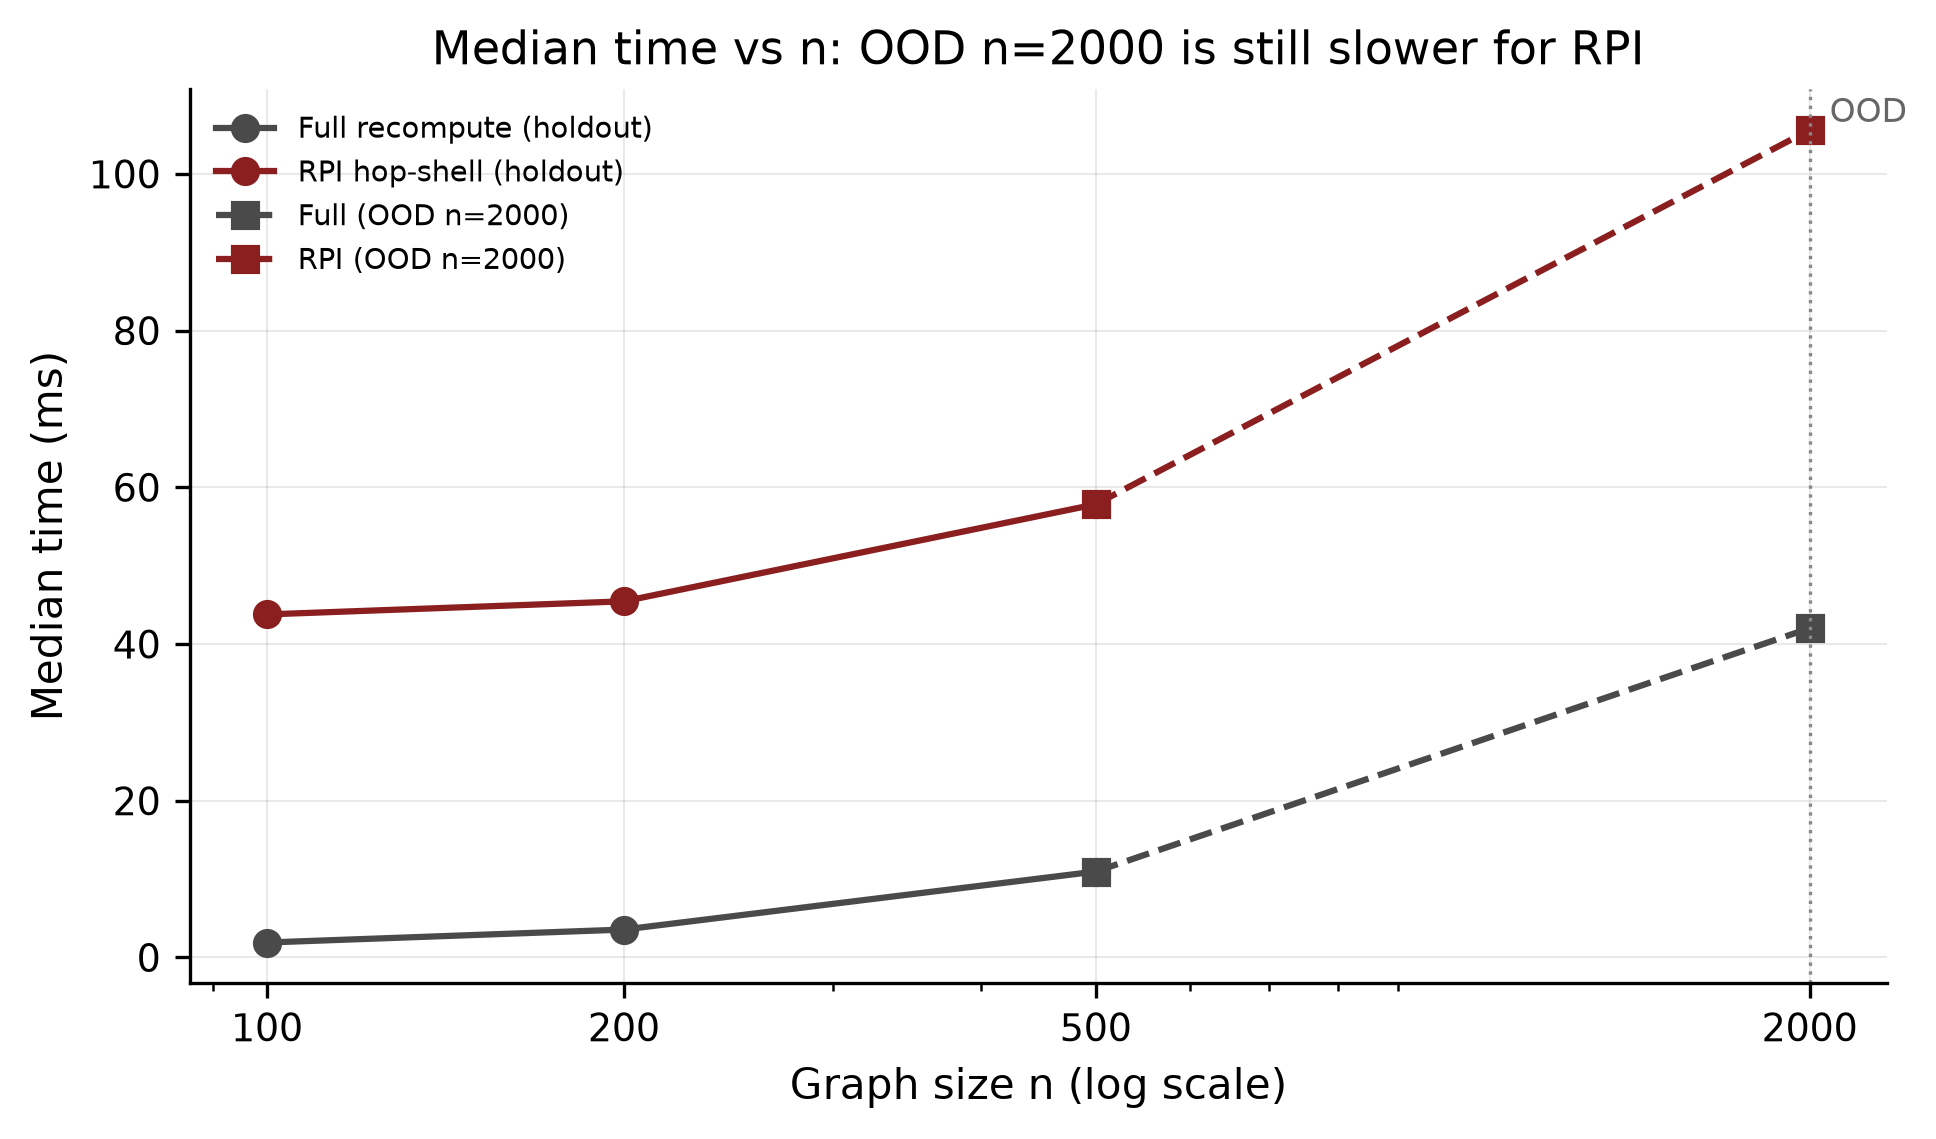

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig18_ood_scaling_median_time.png


In [26]:
show('fig18_ood_scaling_median_time')


**Figure 19.** RPI fallback and first-try through n=2000. Fallback stays ~65–72%; the 15% target is not approached out of distribution either.


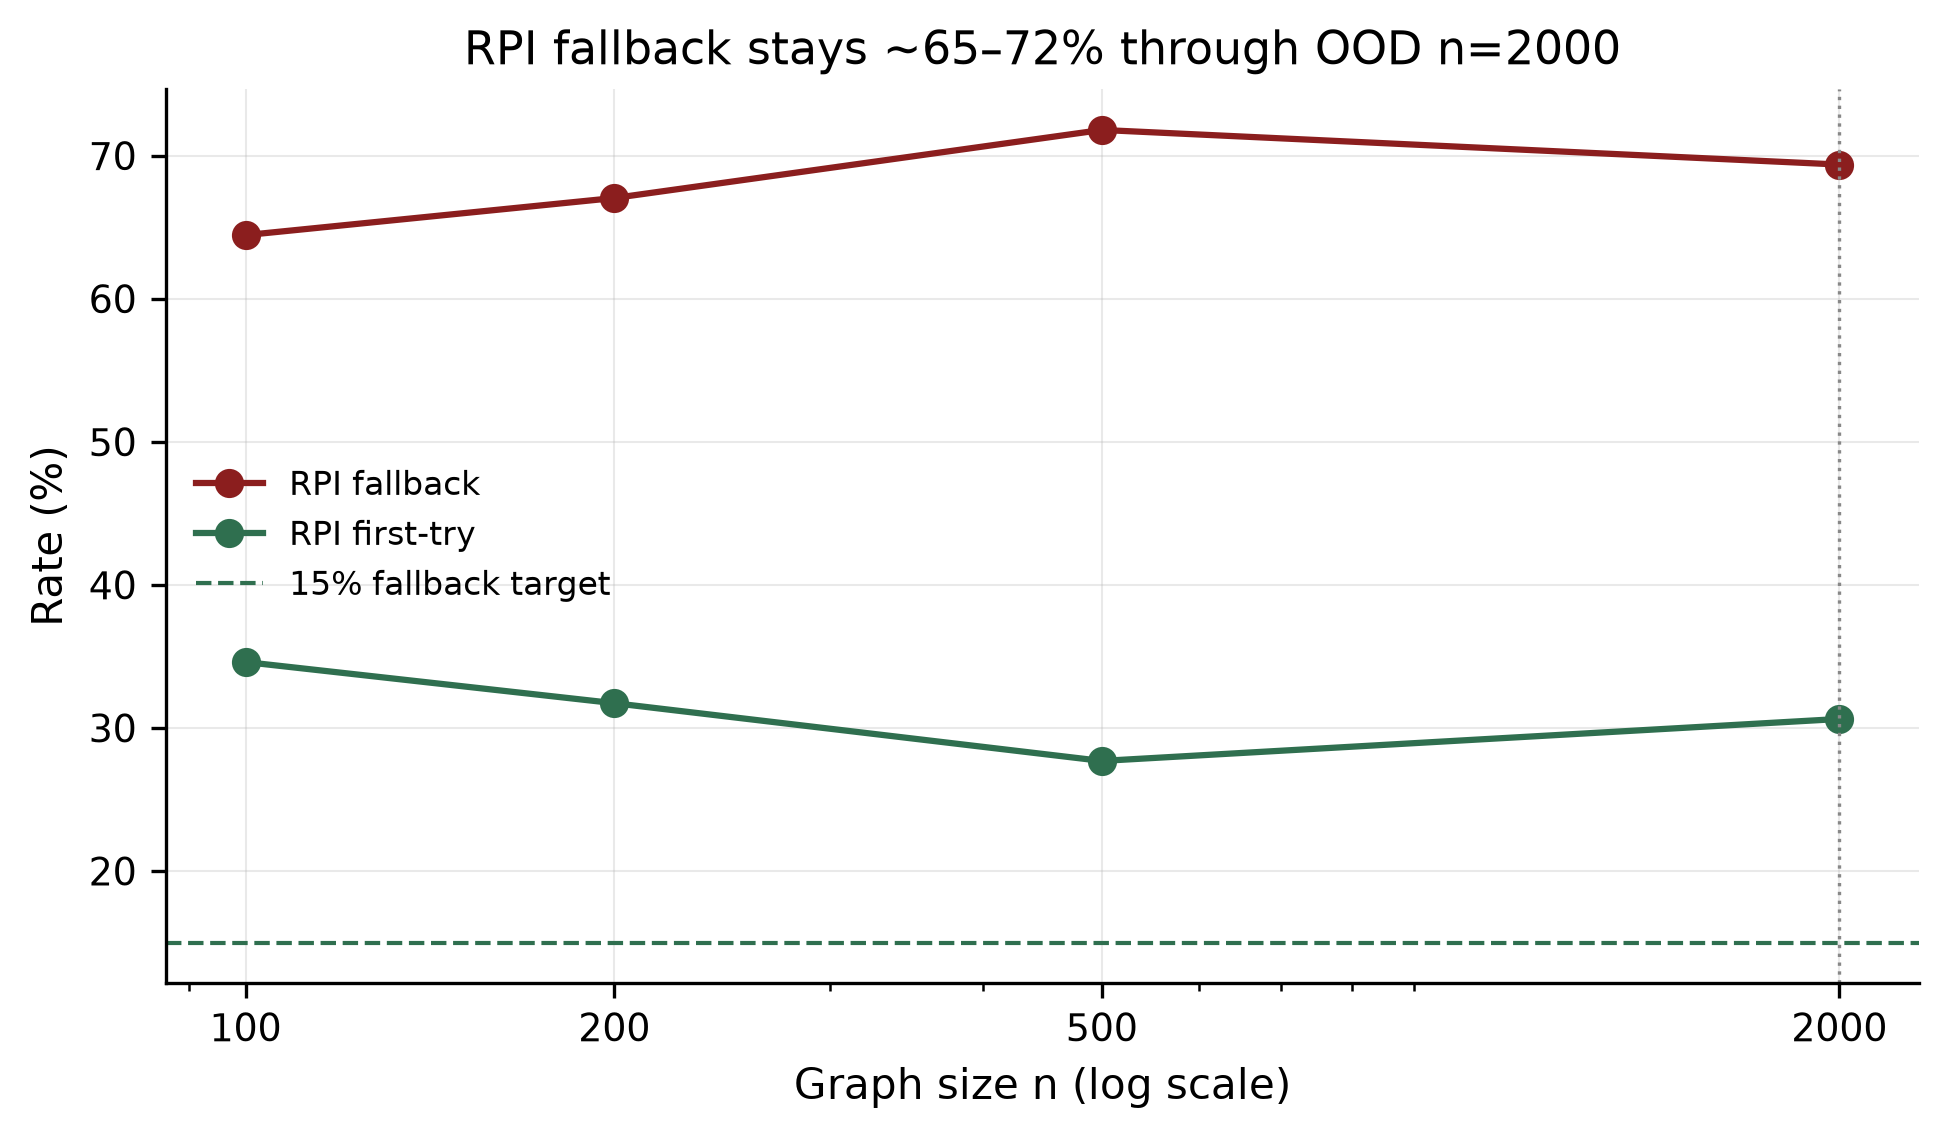

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig19_ood_fallback_firsttry.png


In [27]:
show('fig19_ood_fallback_firsttry')


**Figure 20.** Ratio of median times (RPI / full) vs n, log-x. Ratio falls with n but stays strictly above 1, including the OOD point.


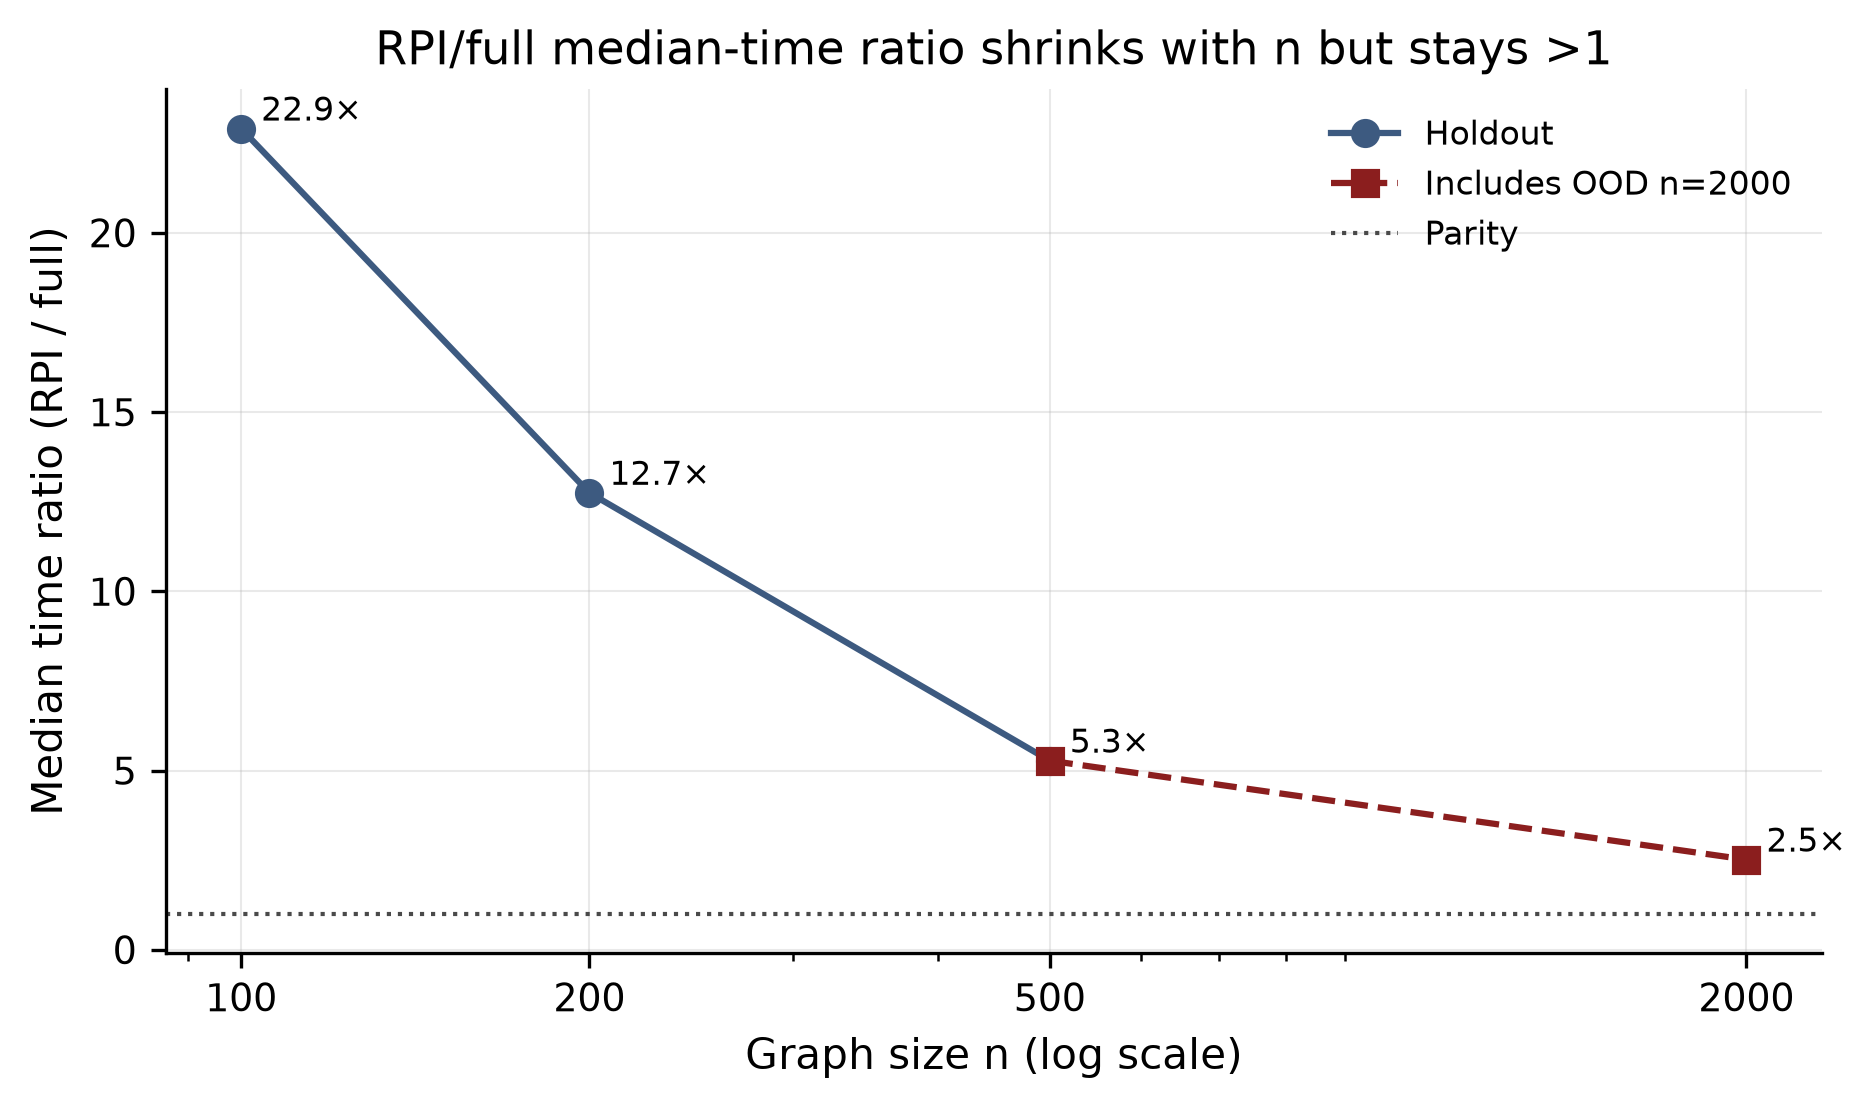

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig20_ratio_time_vs_n.png


In [28]:
show('fig20_ratio_time_vs_n')


**Figures 21–22.** Fallback and vertices vs n with the OOD point called out. Fixed and majority series stop at n=500 because those systems were not run at n=2000.


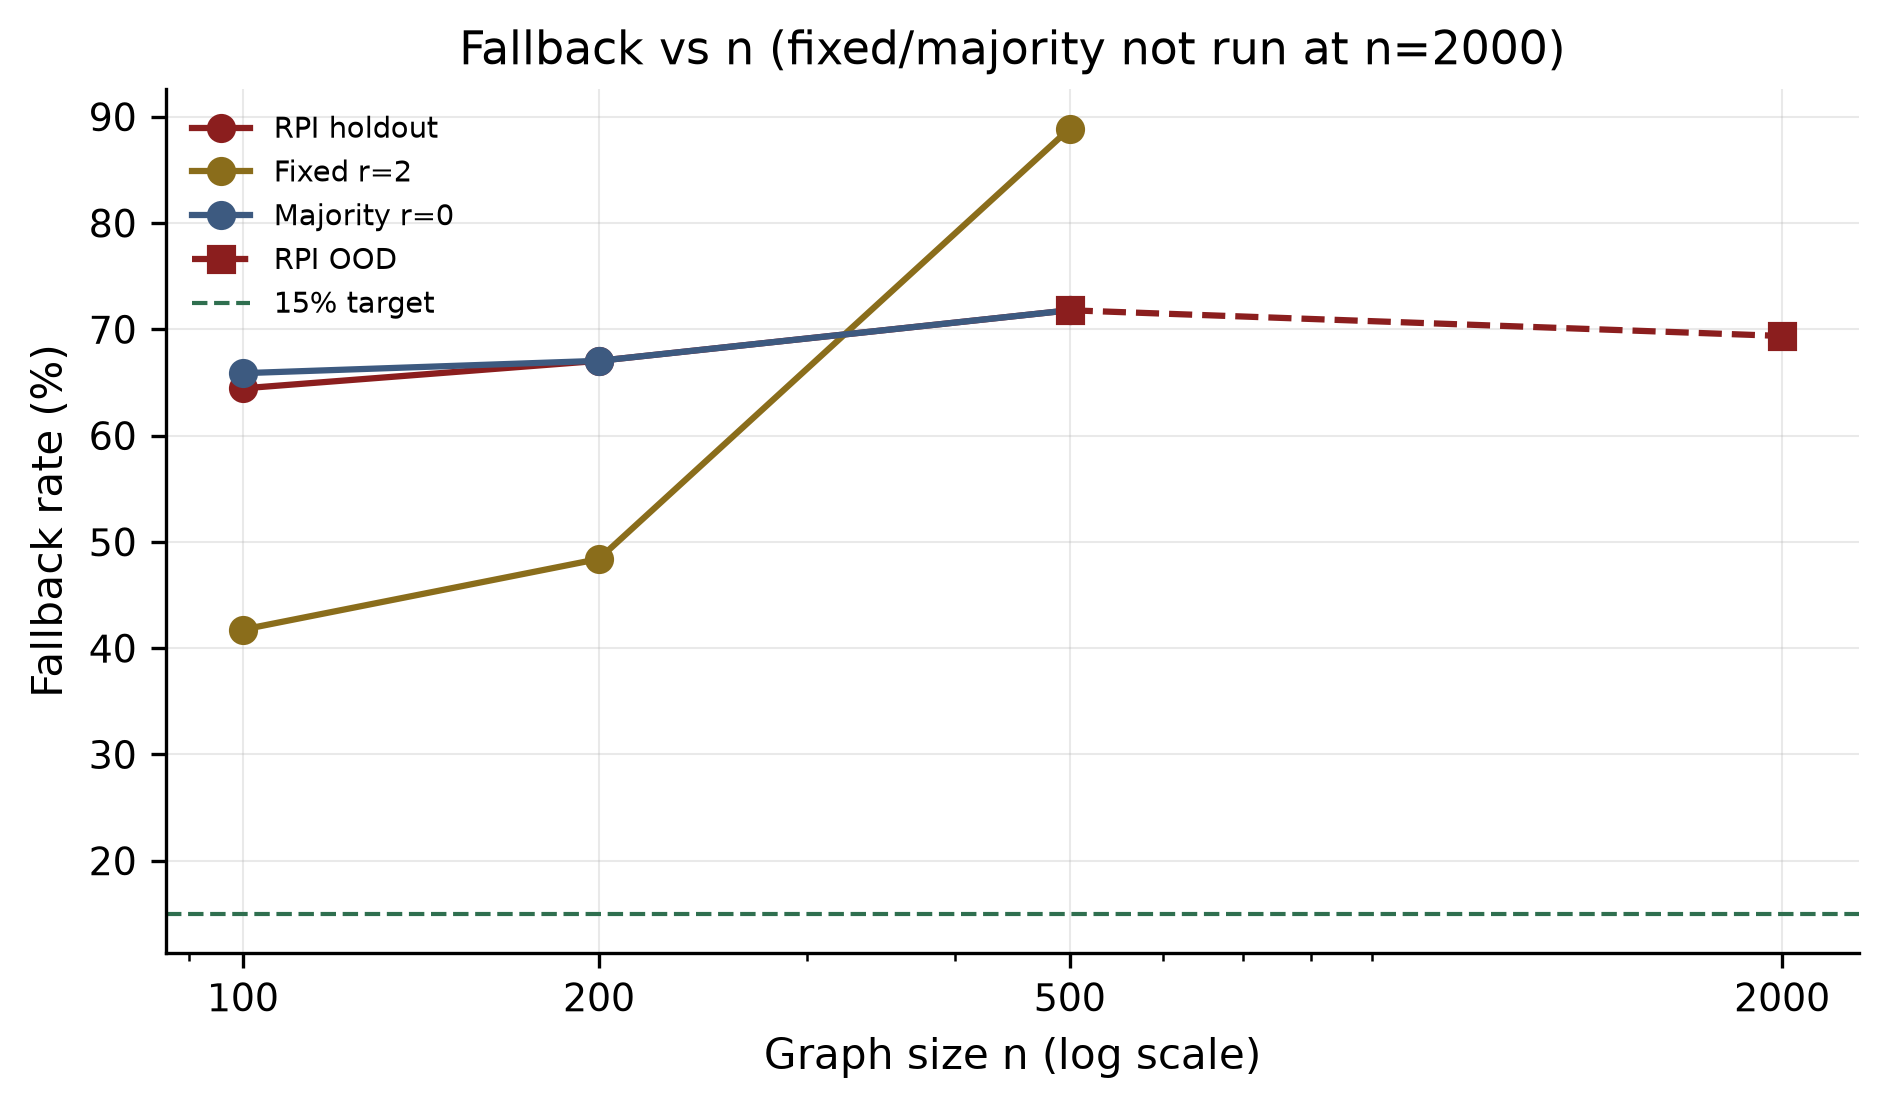

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig21_fallback_vs_n.png


In [29]:
show('fig21_fallback_vs_n')


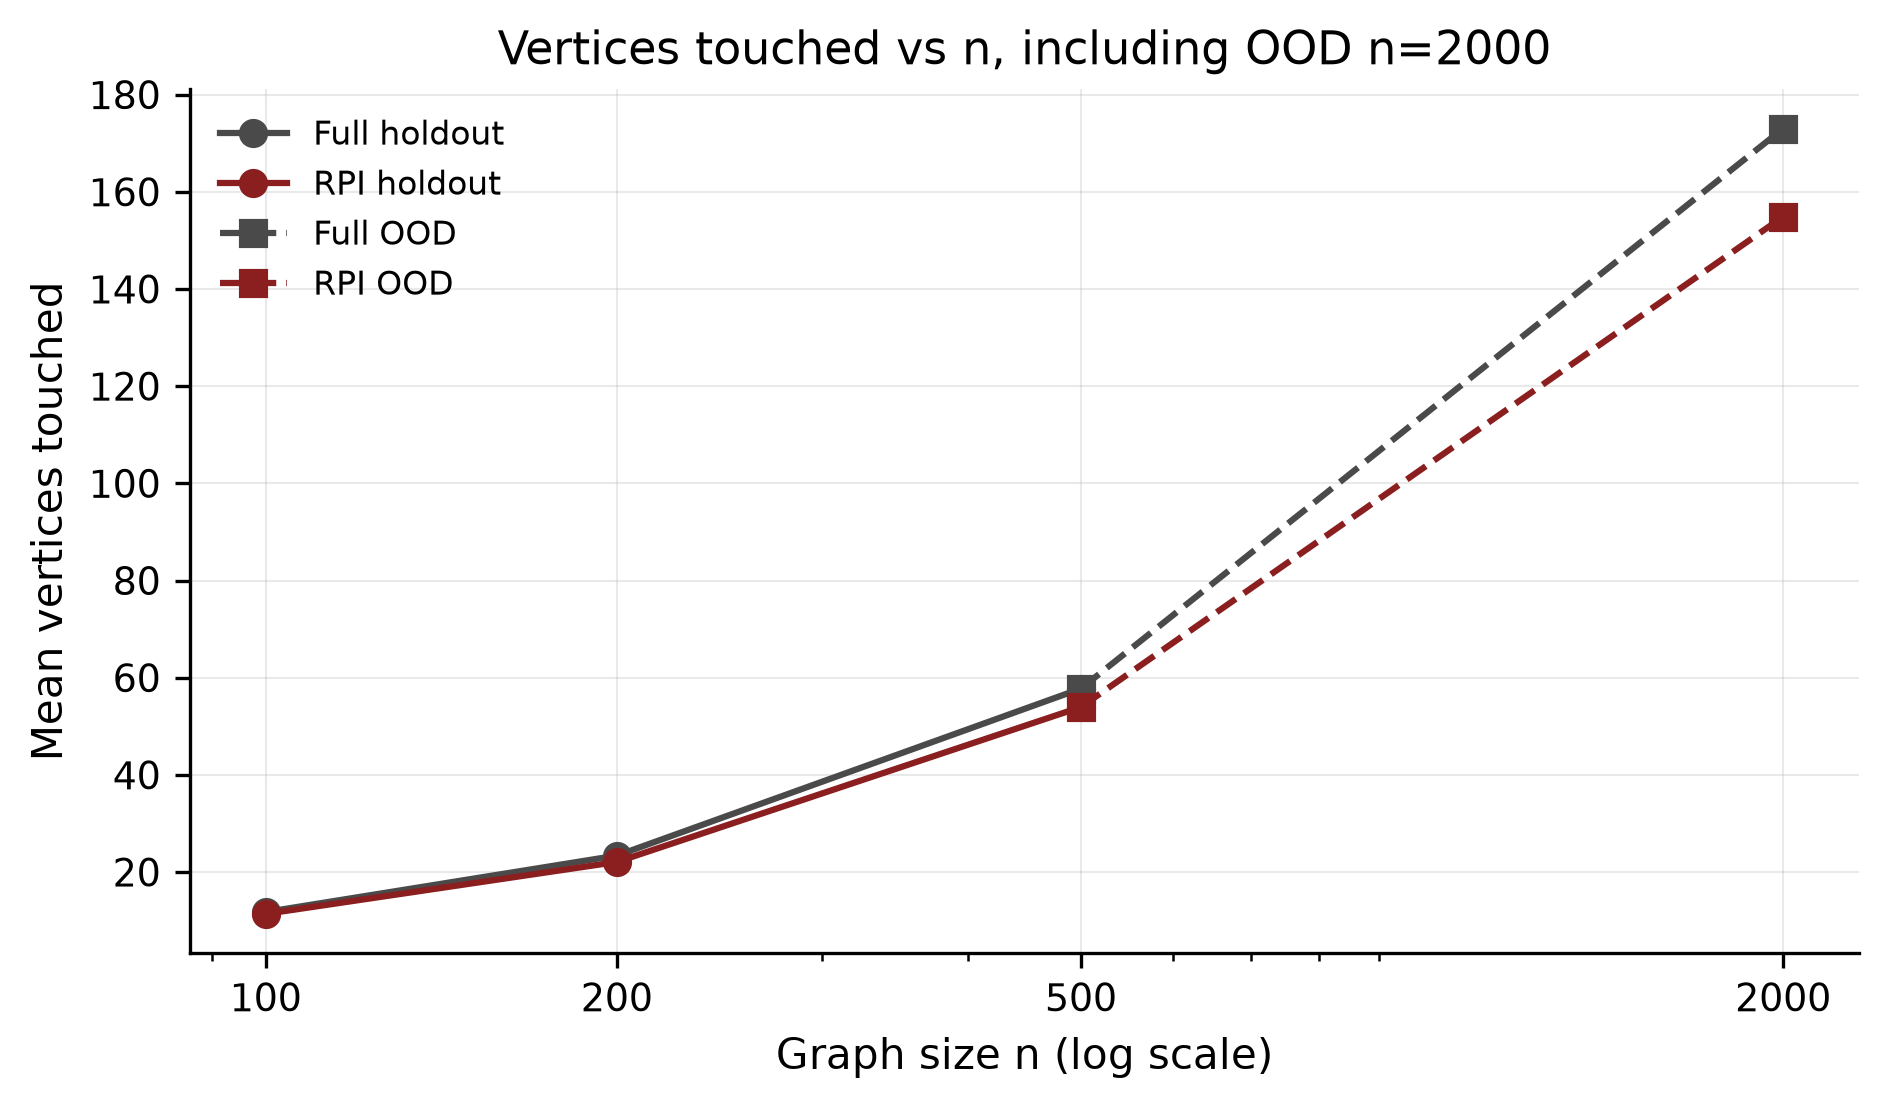

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig22_verts_vs_n.png


In [30]:
show('fig22_verts_vs_n')


## 4. Edit type: shrink_list vs remove_vertex

Joined from `data/raw/edits` on the 45 test streams. Every `remove_vertex` edit fallbacks for fixed, majority, and RPI (100%). First-try RPI success is entirely on `shrink_list`.


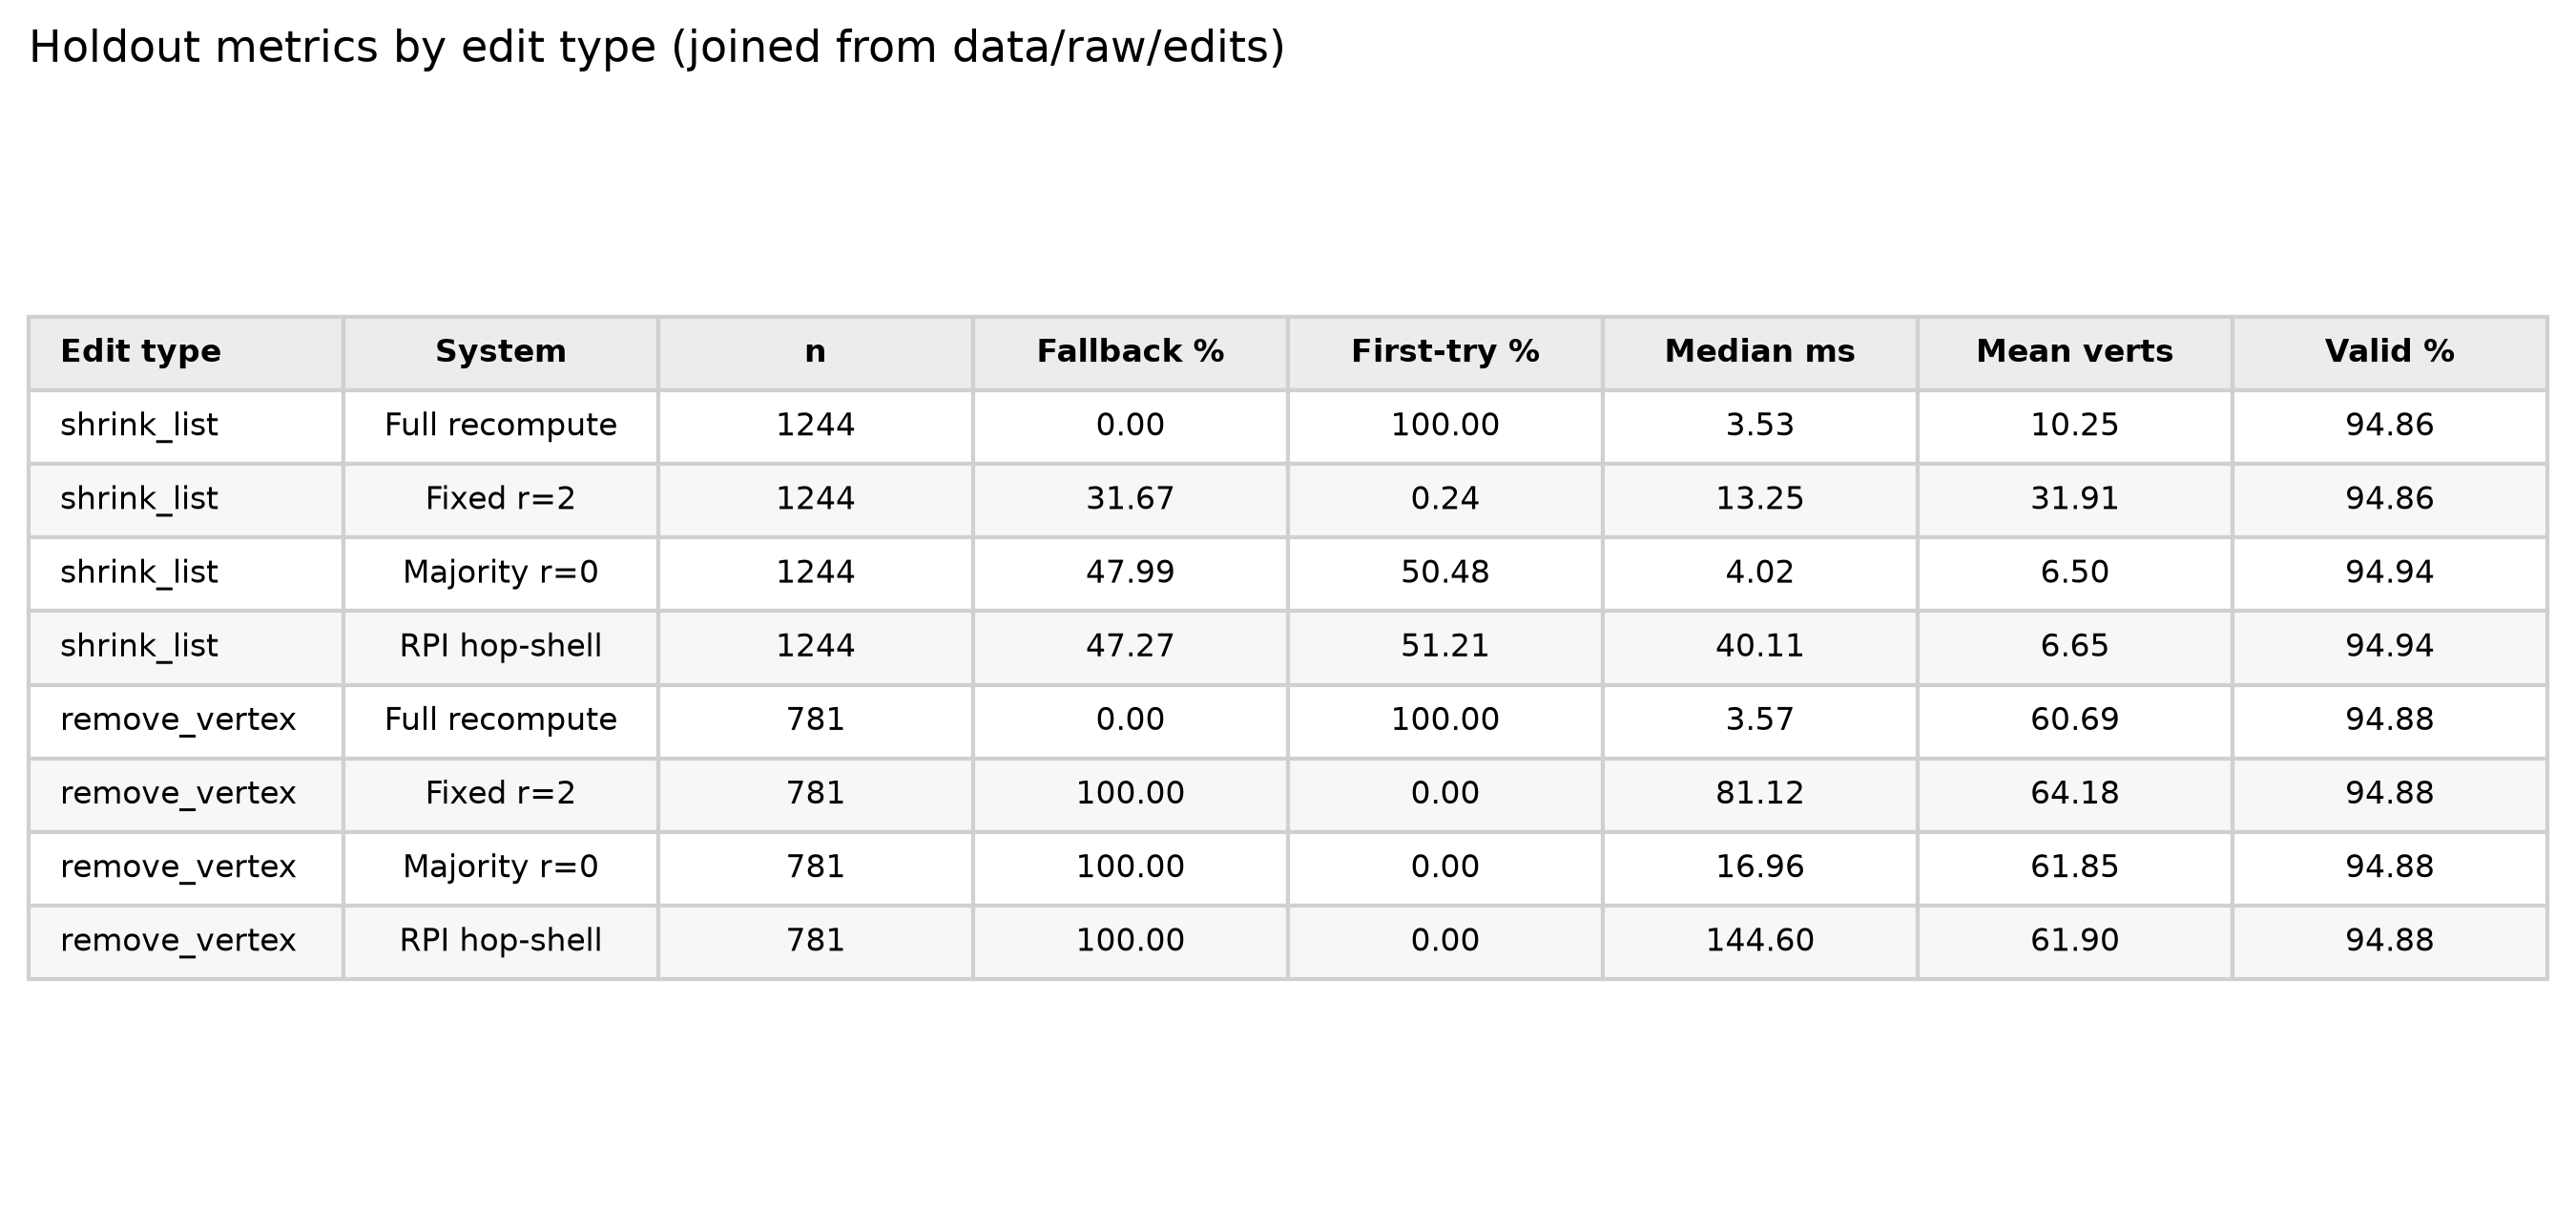

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab06_edit_type.png


In [31]:
show('tab06_edit_type')


**Figure 26.** Fallback by edit type. Incremental systems never first-try a vertex deletion on this dataset; they burn the radius ladder and then recompute.


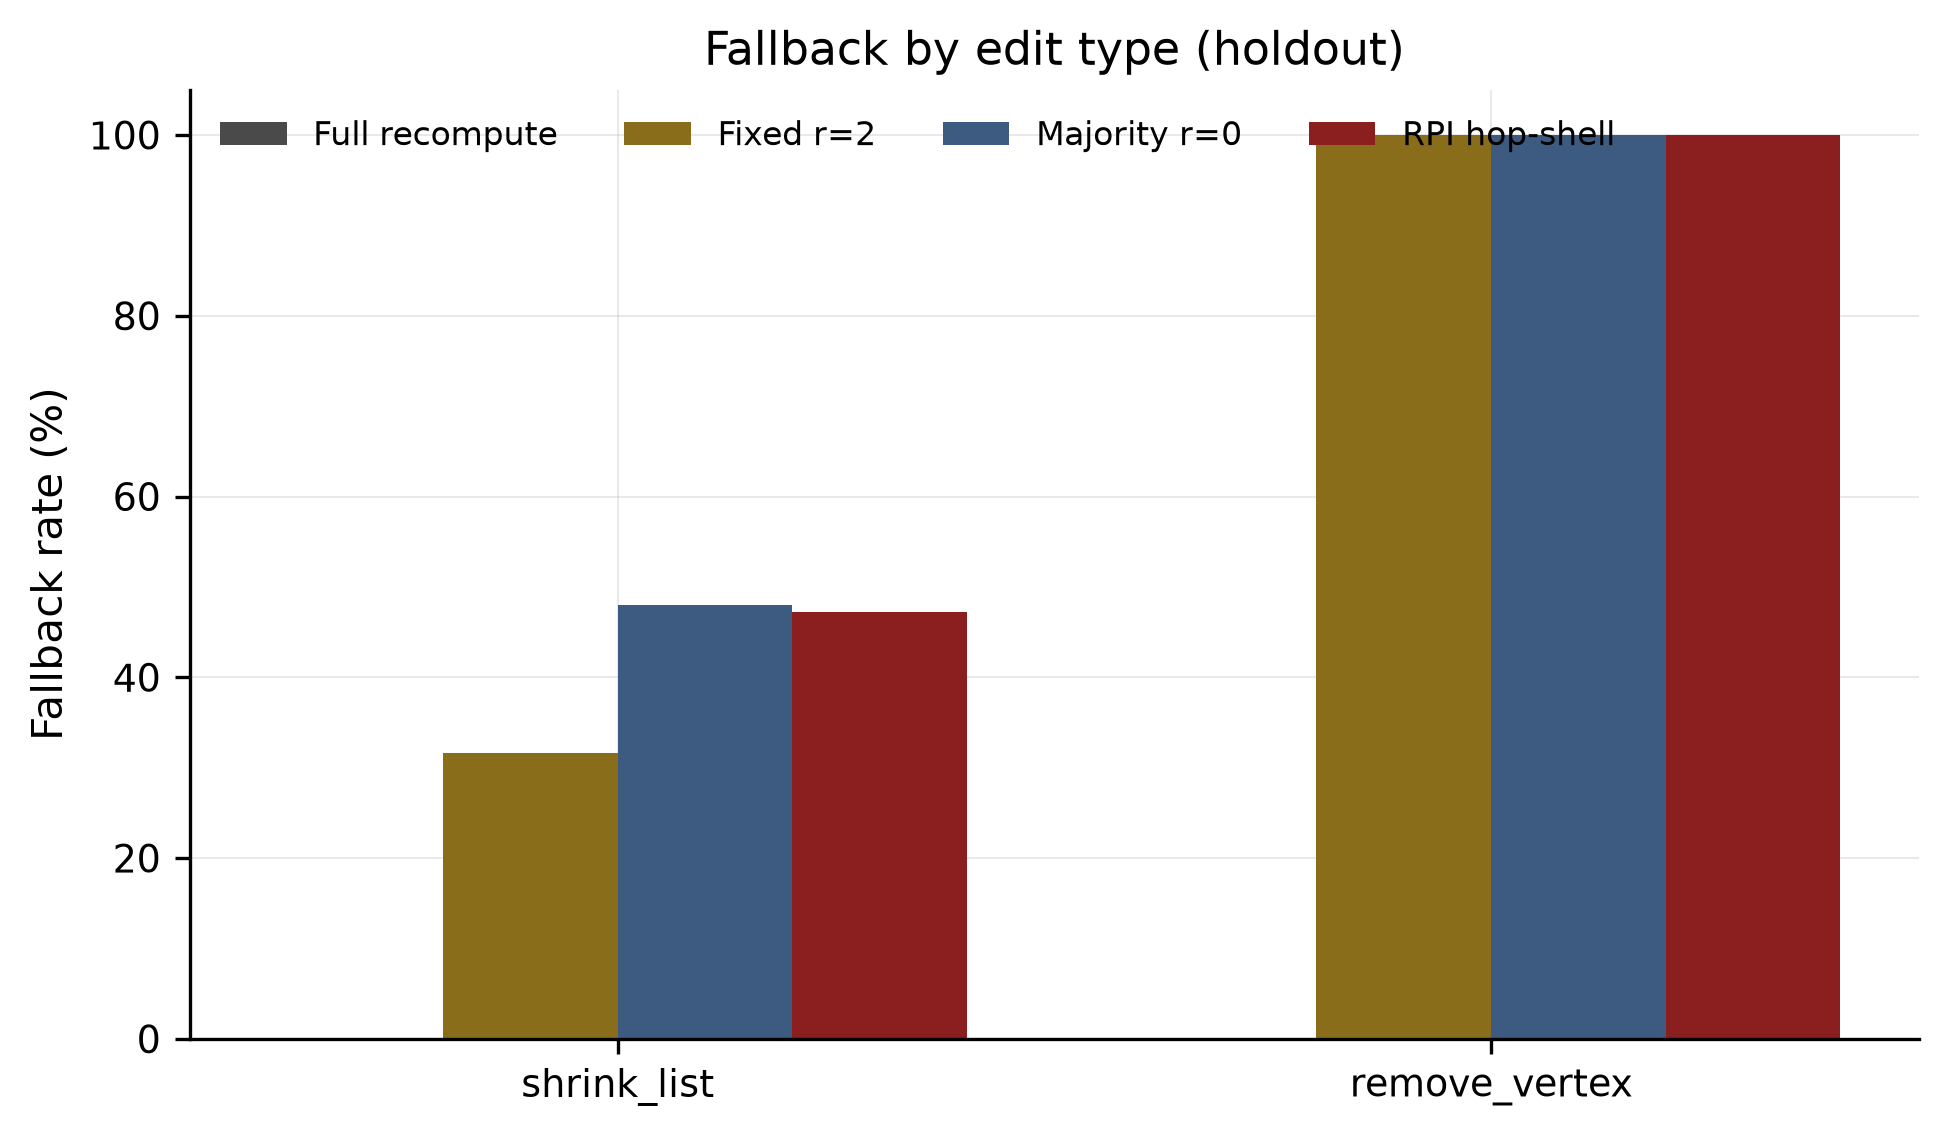

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig26_edit_type_fallback.png


In [32]:
show('fig26_edit_type_fallback')


**Figure 27.** Mean vertices by edit type. On `shrink_list`, RPI/majority stay local (~6.6 vertices) while fixed r=2 overshoots (~32). On `remove_vertex`, all systems recolor tens of vertices (near-full).


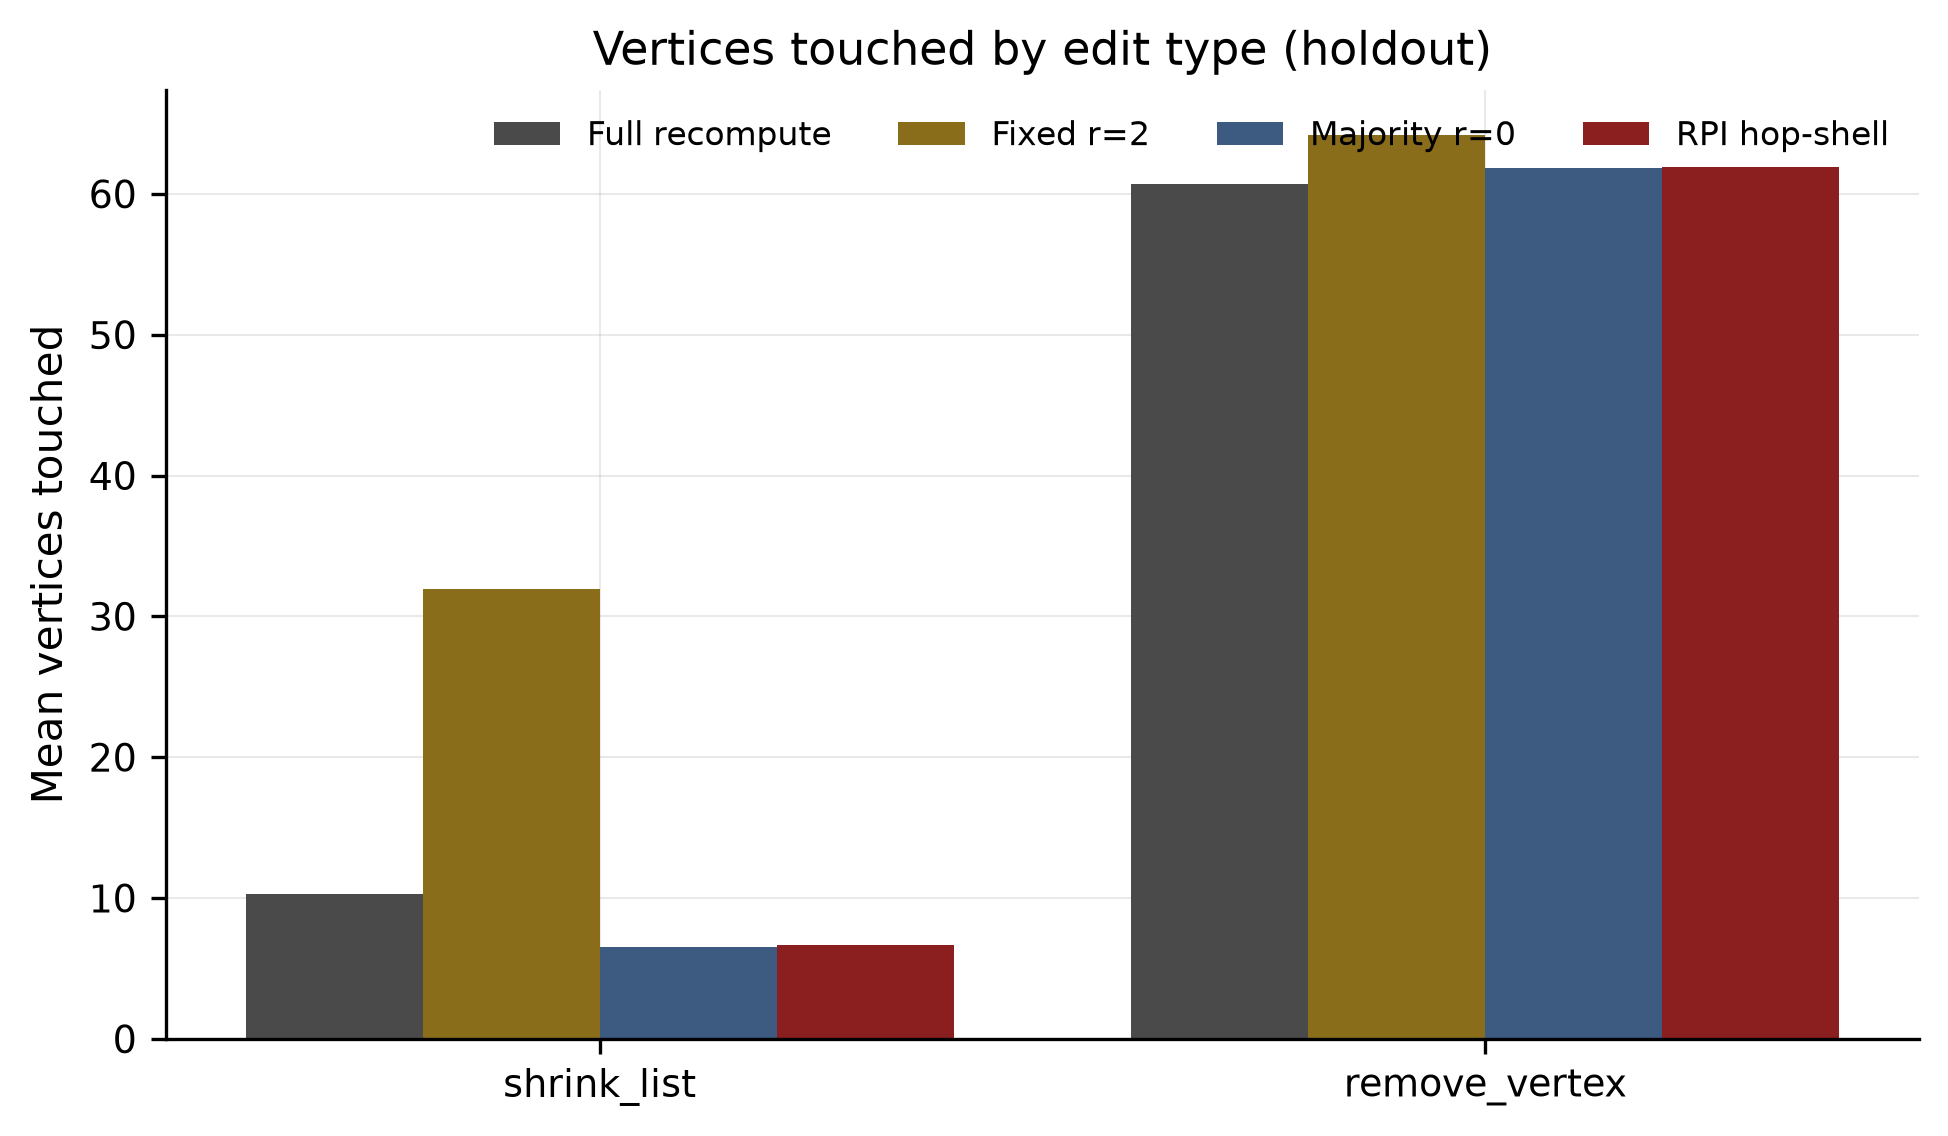

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig27_edit_type_verts.png


In [33]:
show('fig27_edit_type_verts')


**Figure 28.** Stacked first-try / recovered-after-retry / fallback, grouped Full → Fixed → Majority → RPI within each edit type. Recovered retries are rare; almost every non-first-try hits fallback.


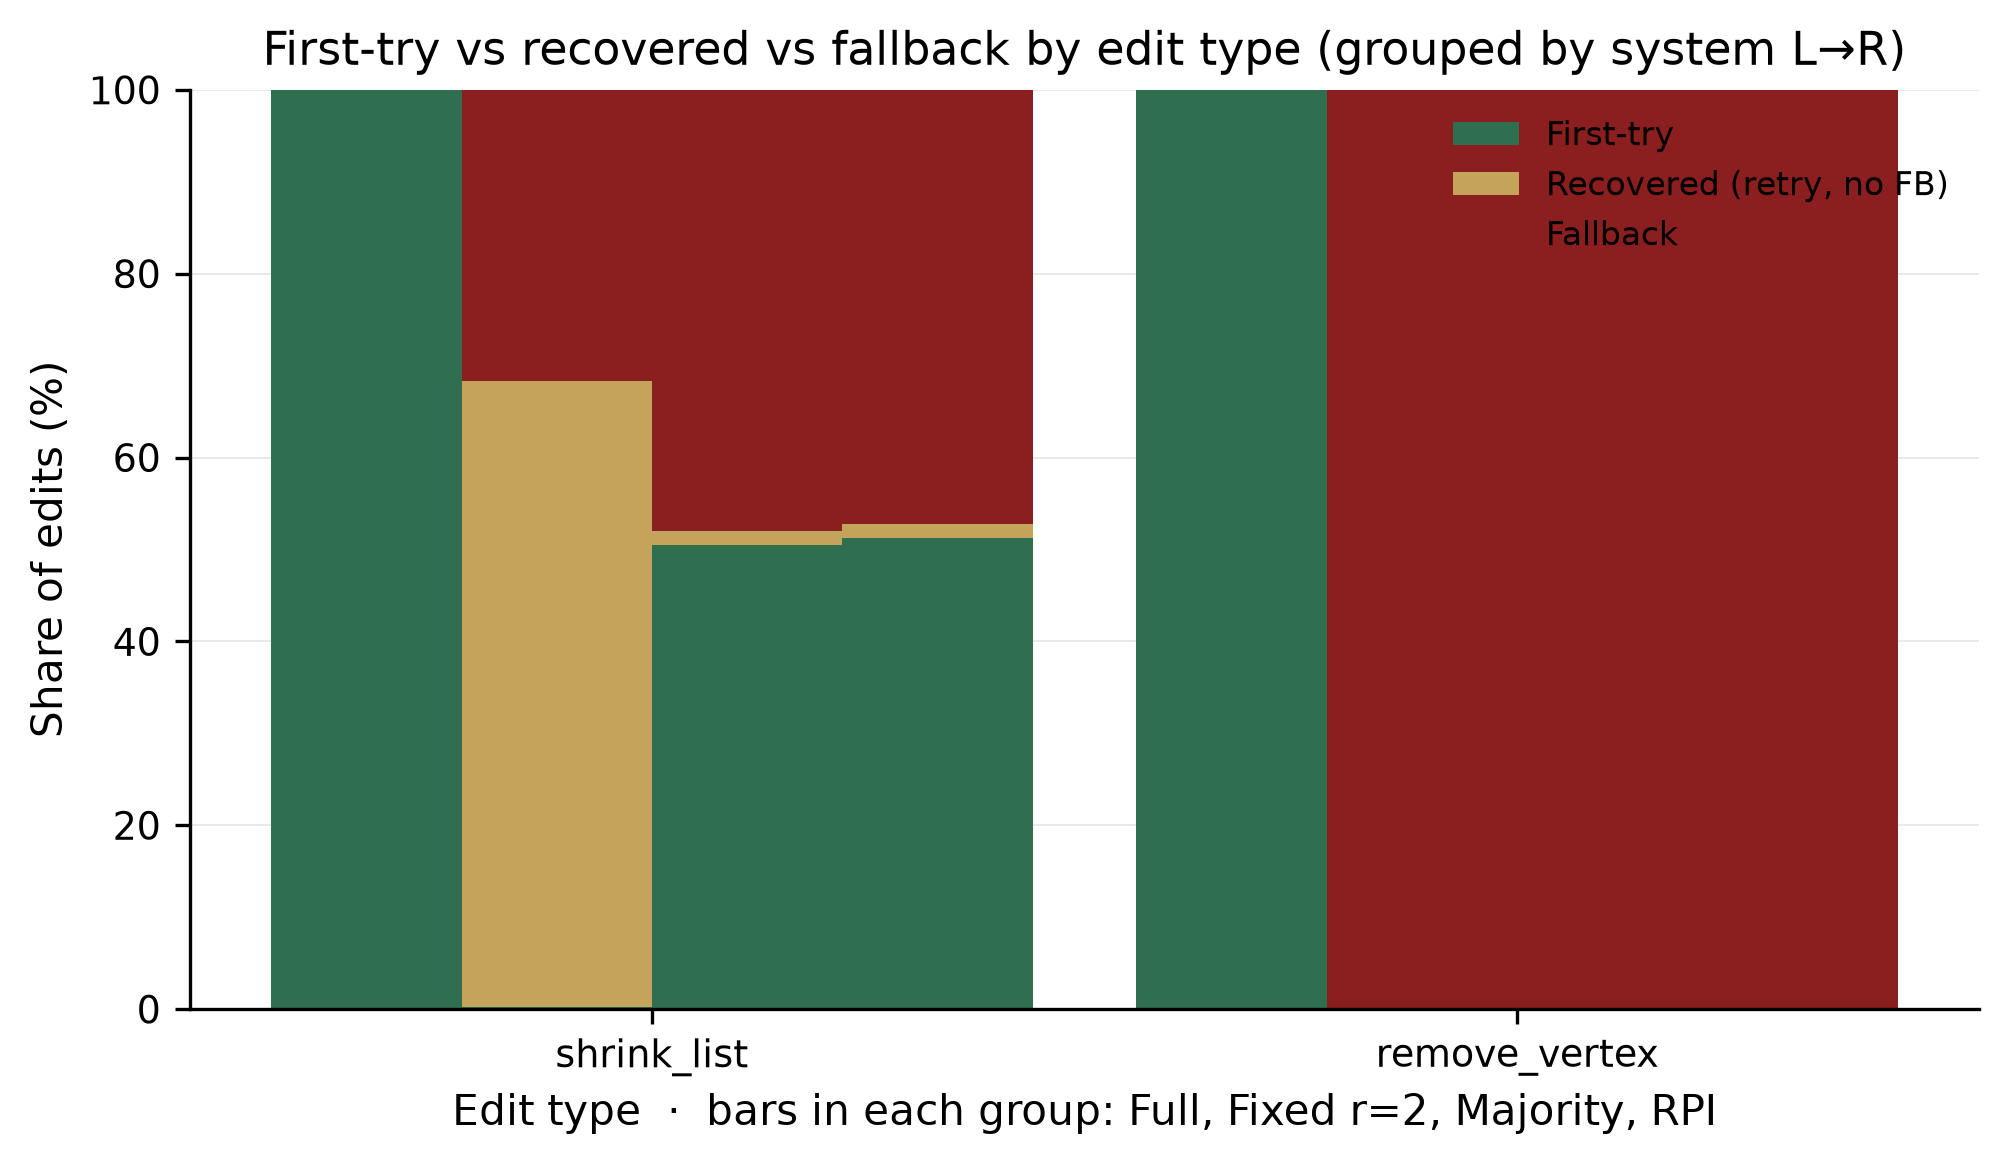

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig28_firsttry_fallback_stacked.png


In [34]:
show('fig28_firsttry_fallback_stacked')


**Figure 34 / Table 10.** Same edit-type split on **OOD n=2000** (RPI vs full only). The 100% `remove_vertex` fallback pattern repeats.


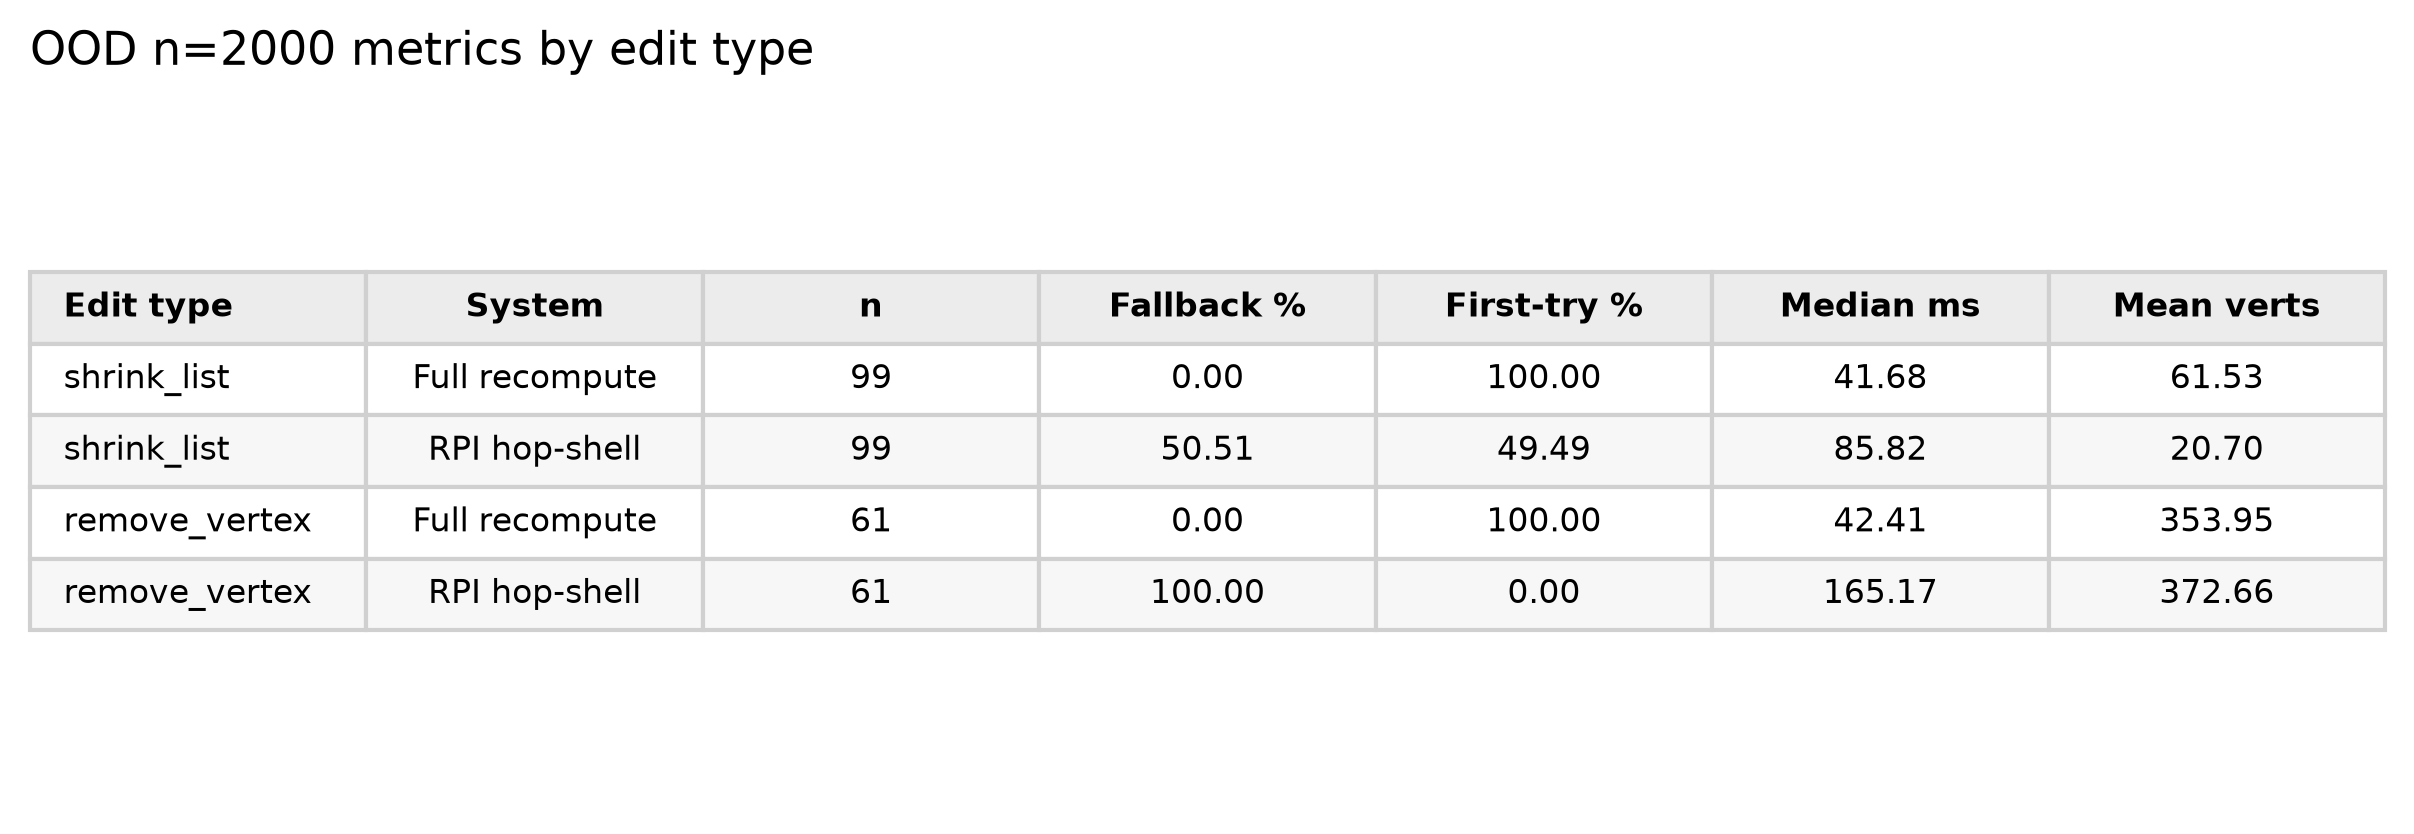

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab10_ood_edit_type.png


In [35]:
show('tab10_ood_edit_type')


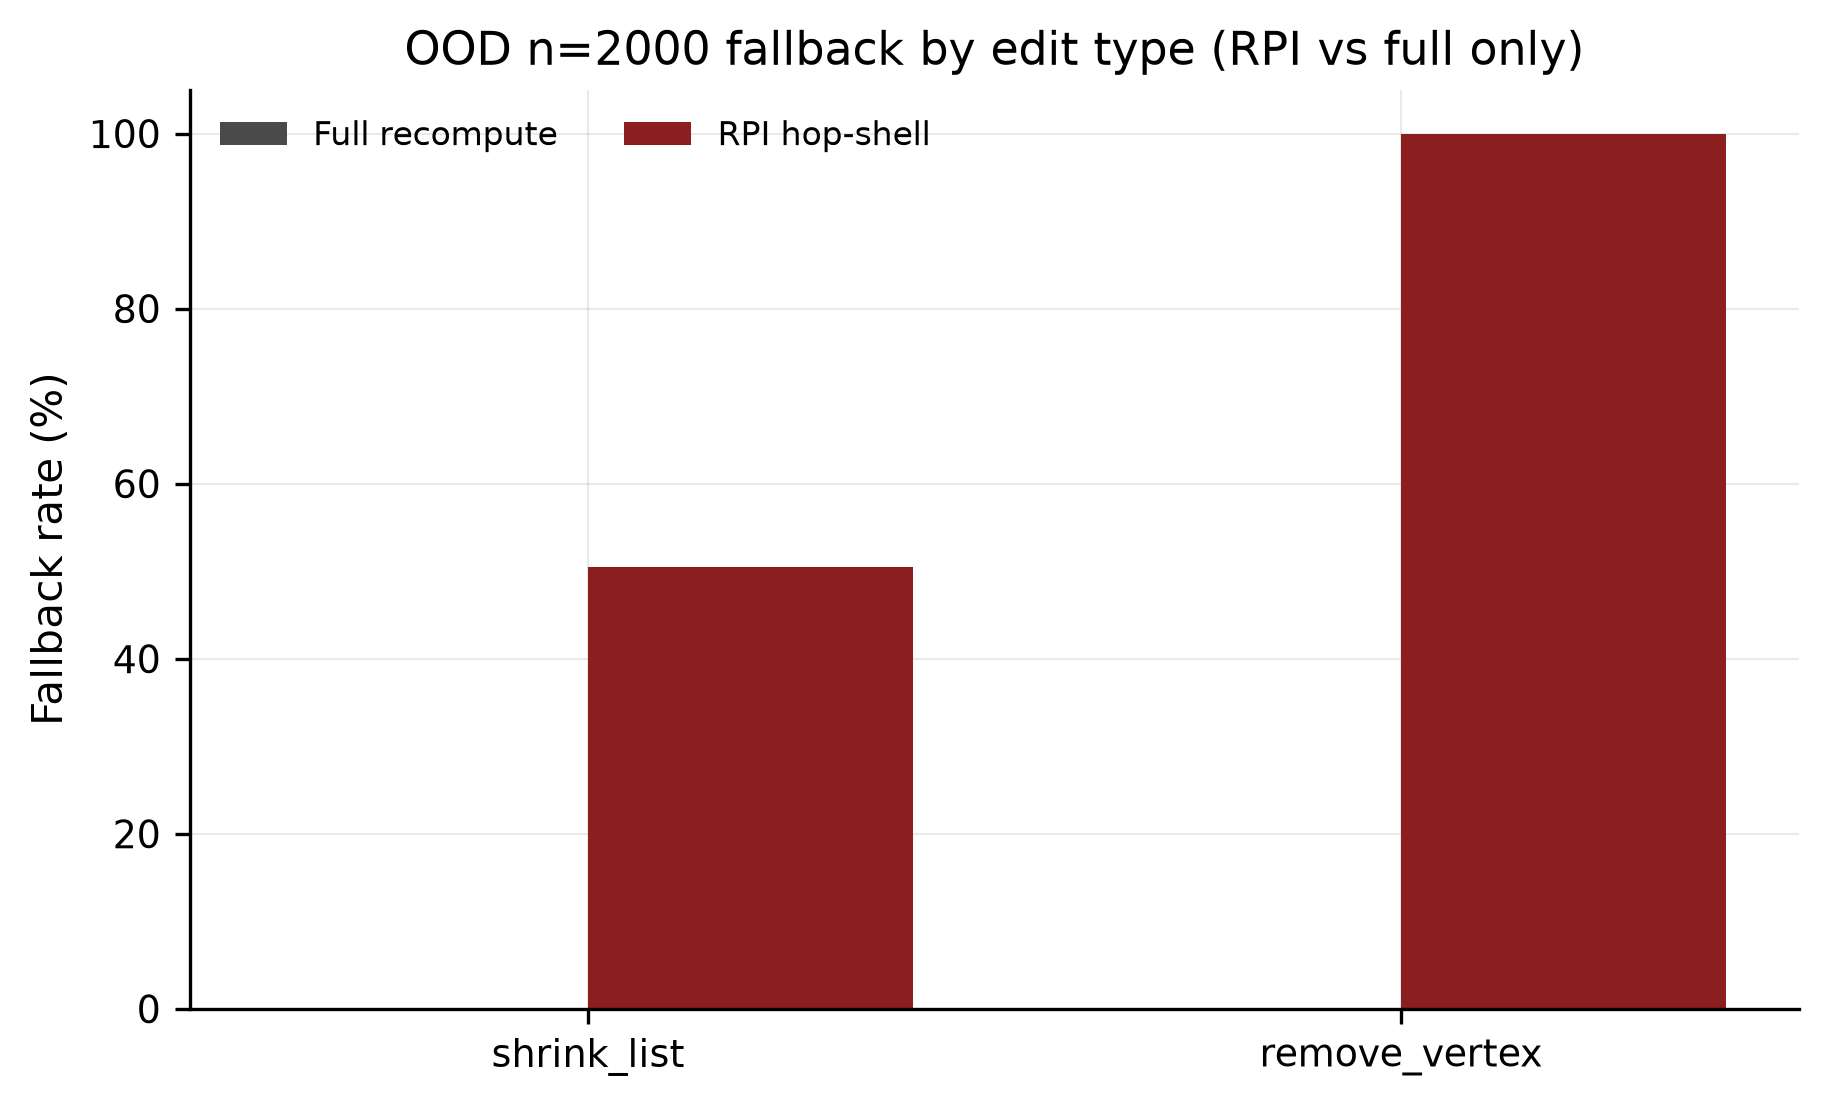

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig34_ood_edit_type_fallback.png


In [36]:
show('fig34_ood_edit_type_fallback')


## 5. Cost of misprediction and paired tests

**Figure 32–33 / Table 9.** Conditioning RPI on `attempts = 0` vs `attempts > 0`. First-try edits are cheap and almost always radius 0. Retries are slower, touch more vertices, and nearly always fall back to full recompute.


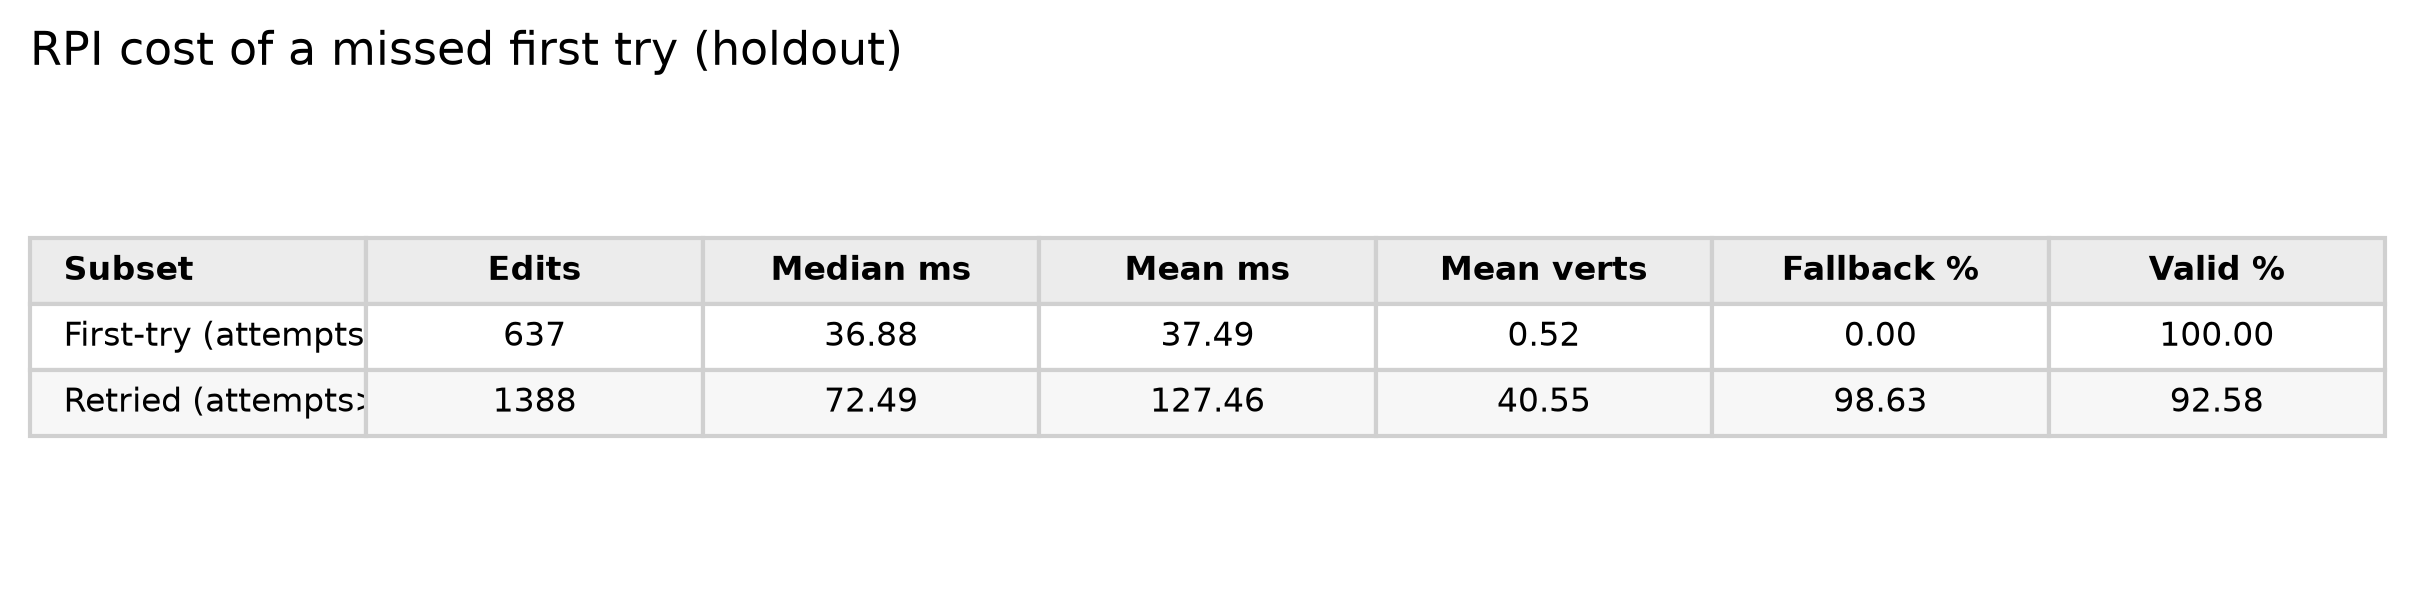

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab09_firsttry_vs_retry.png


In [37]:
show('tab09_firsttry_vs_retry')


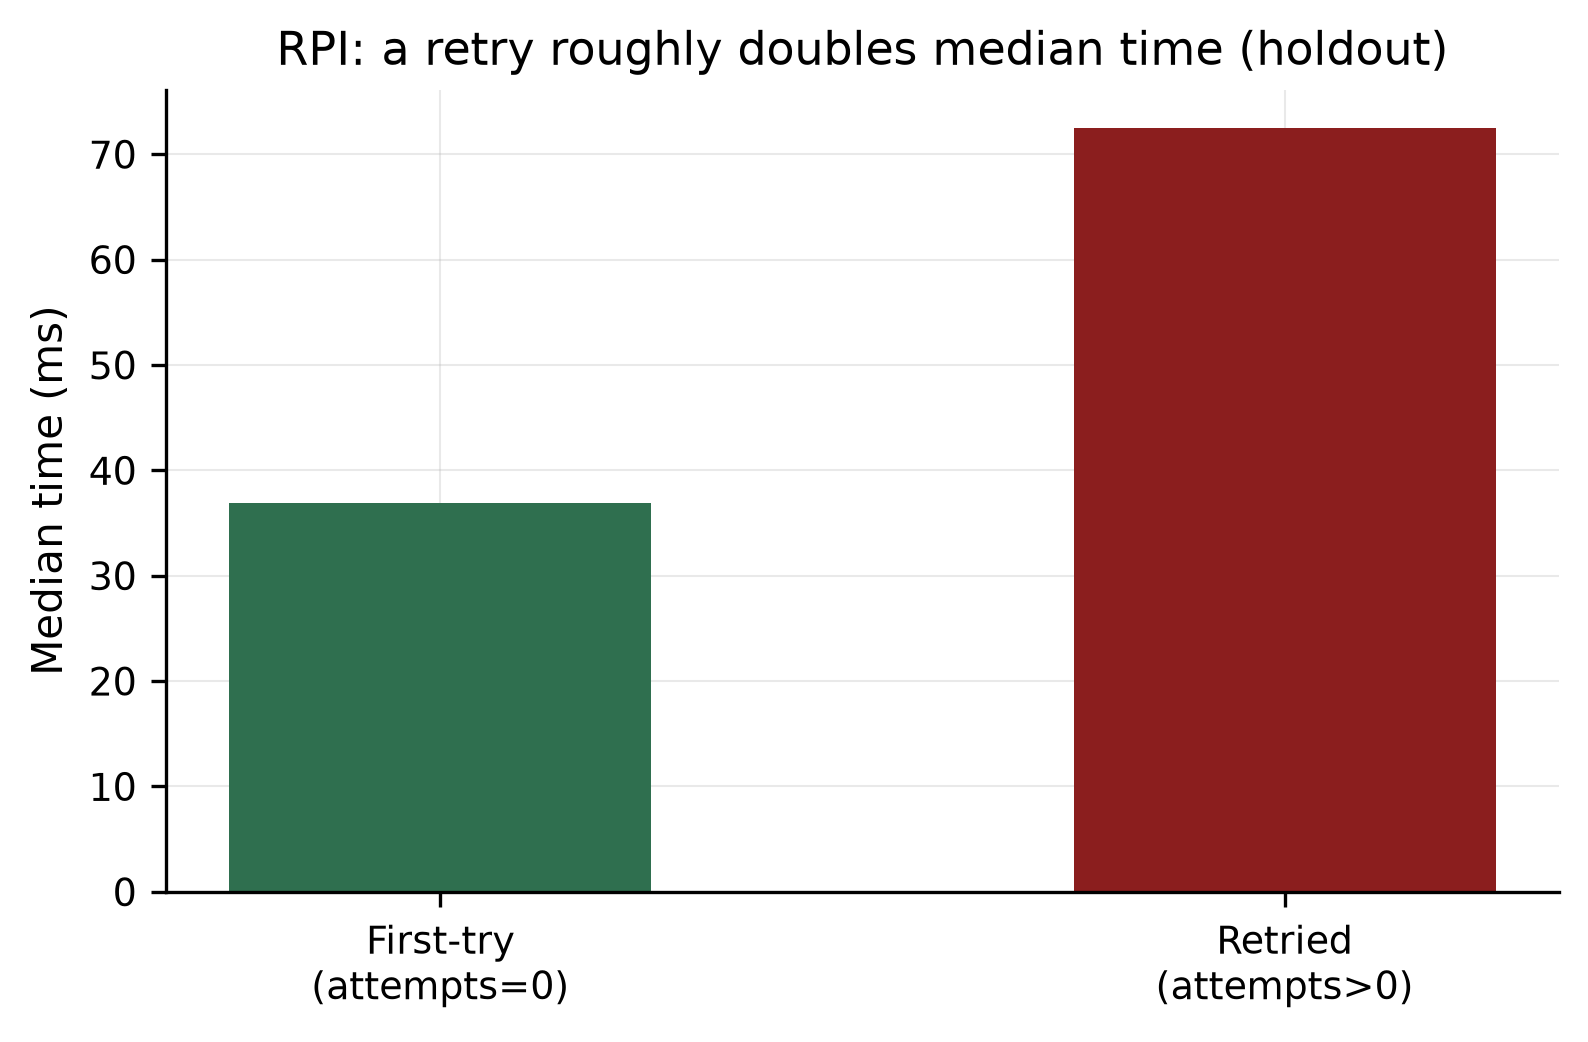

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig32_cost_of_misprediction.png


In [38]:
show('fig32_cost_of_misprediction')


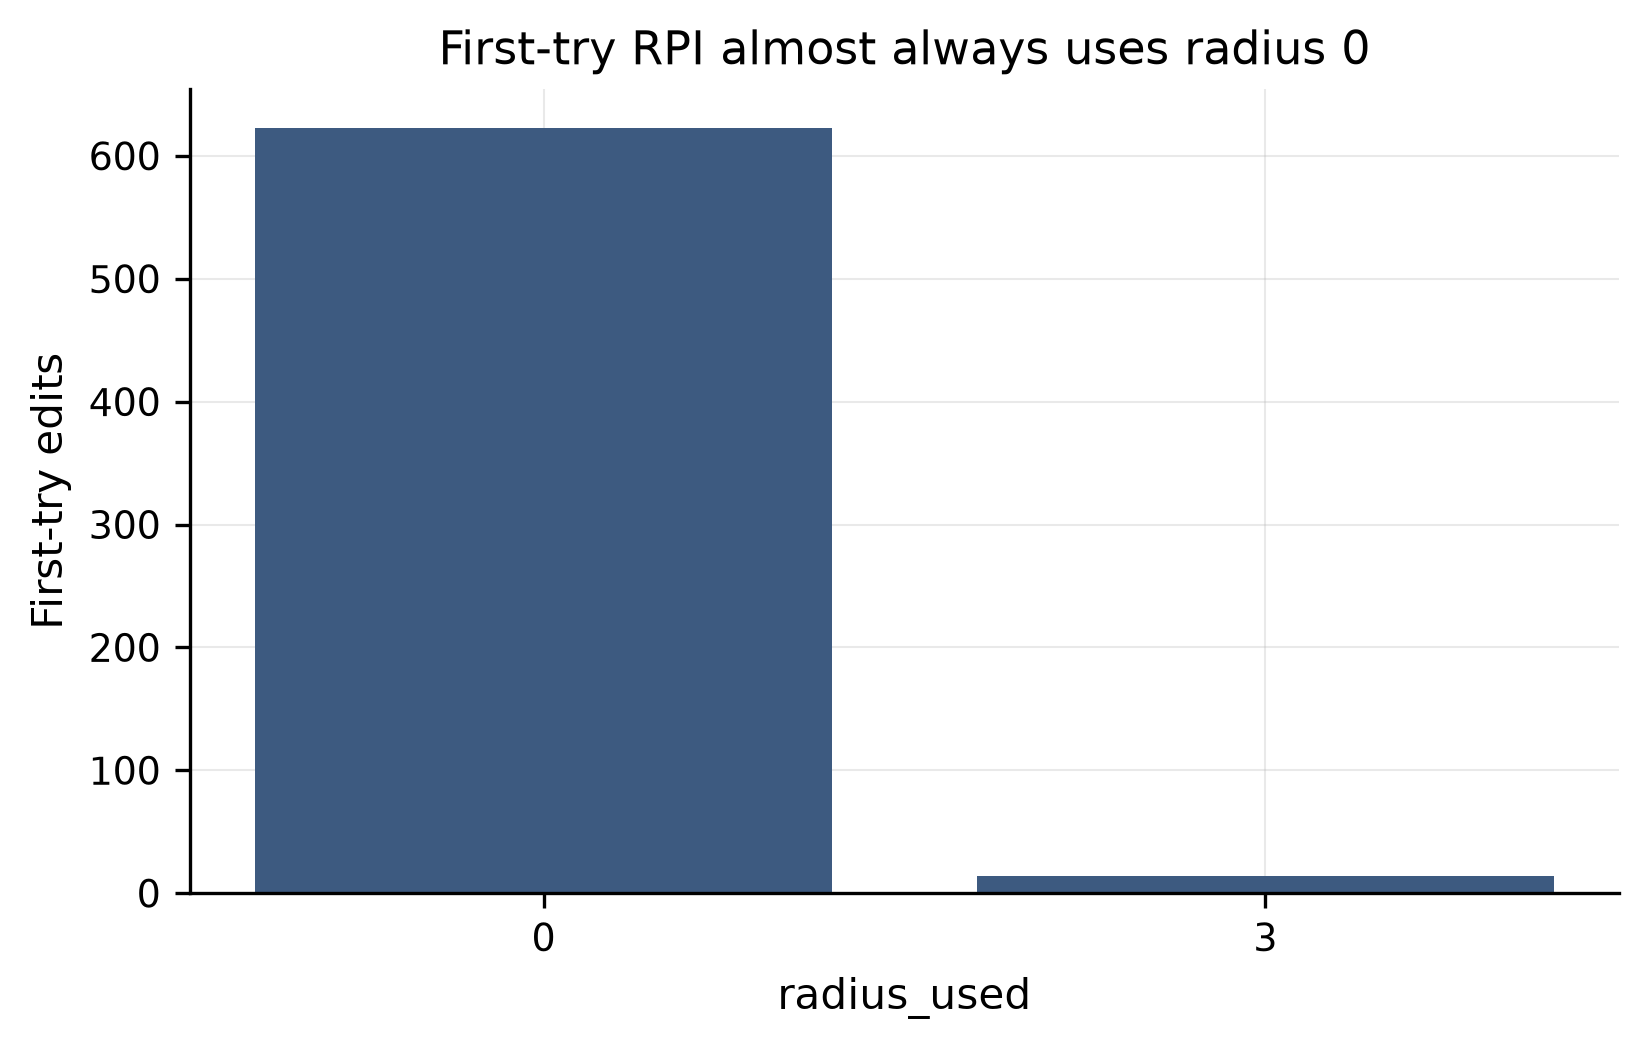

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig33_firsttry_radius_used.png


In [39]:
show('fig33_firsttry_radius_used')


**Figure 23.** Paired scatter of per-edit times (RPI vs full) on 2,025 holdout pairs. Points above y=x mean RPI slower. The cloud sits above the diagonal.


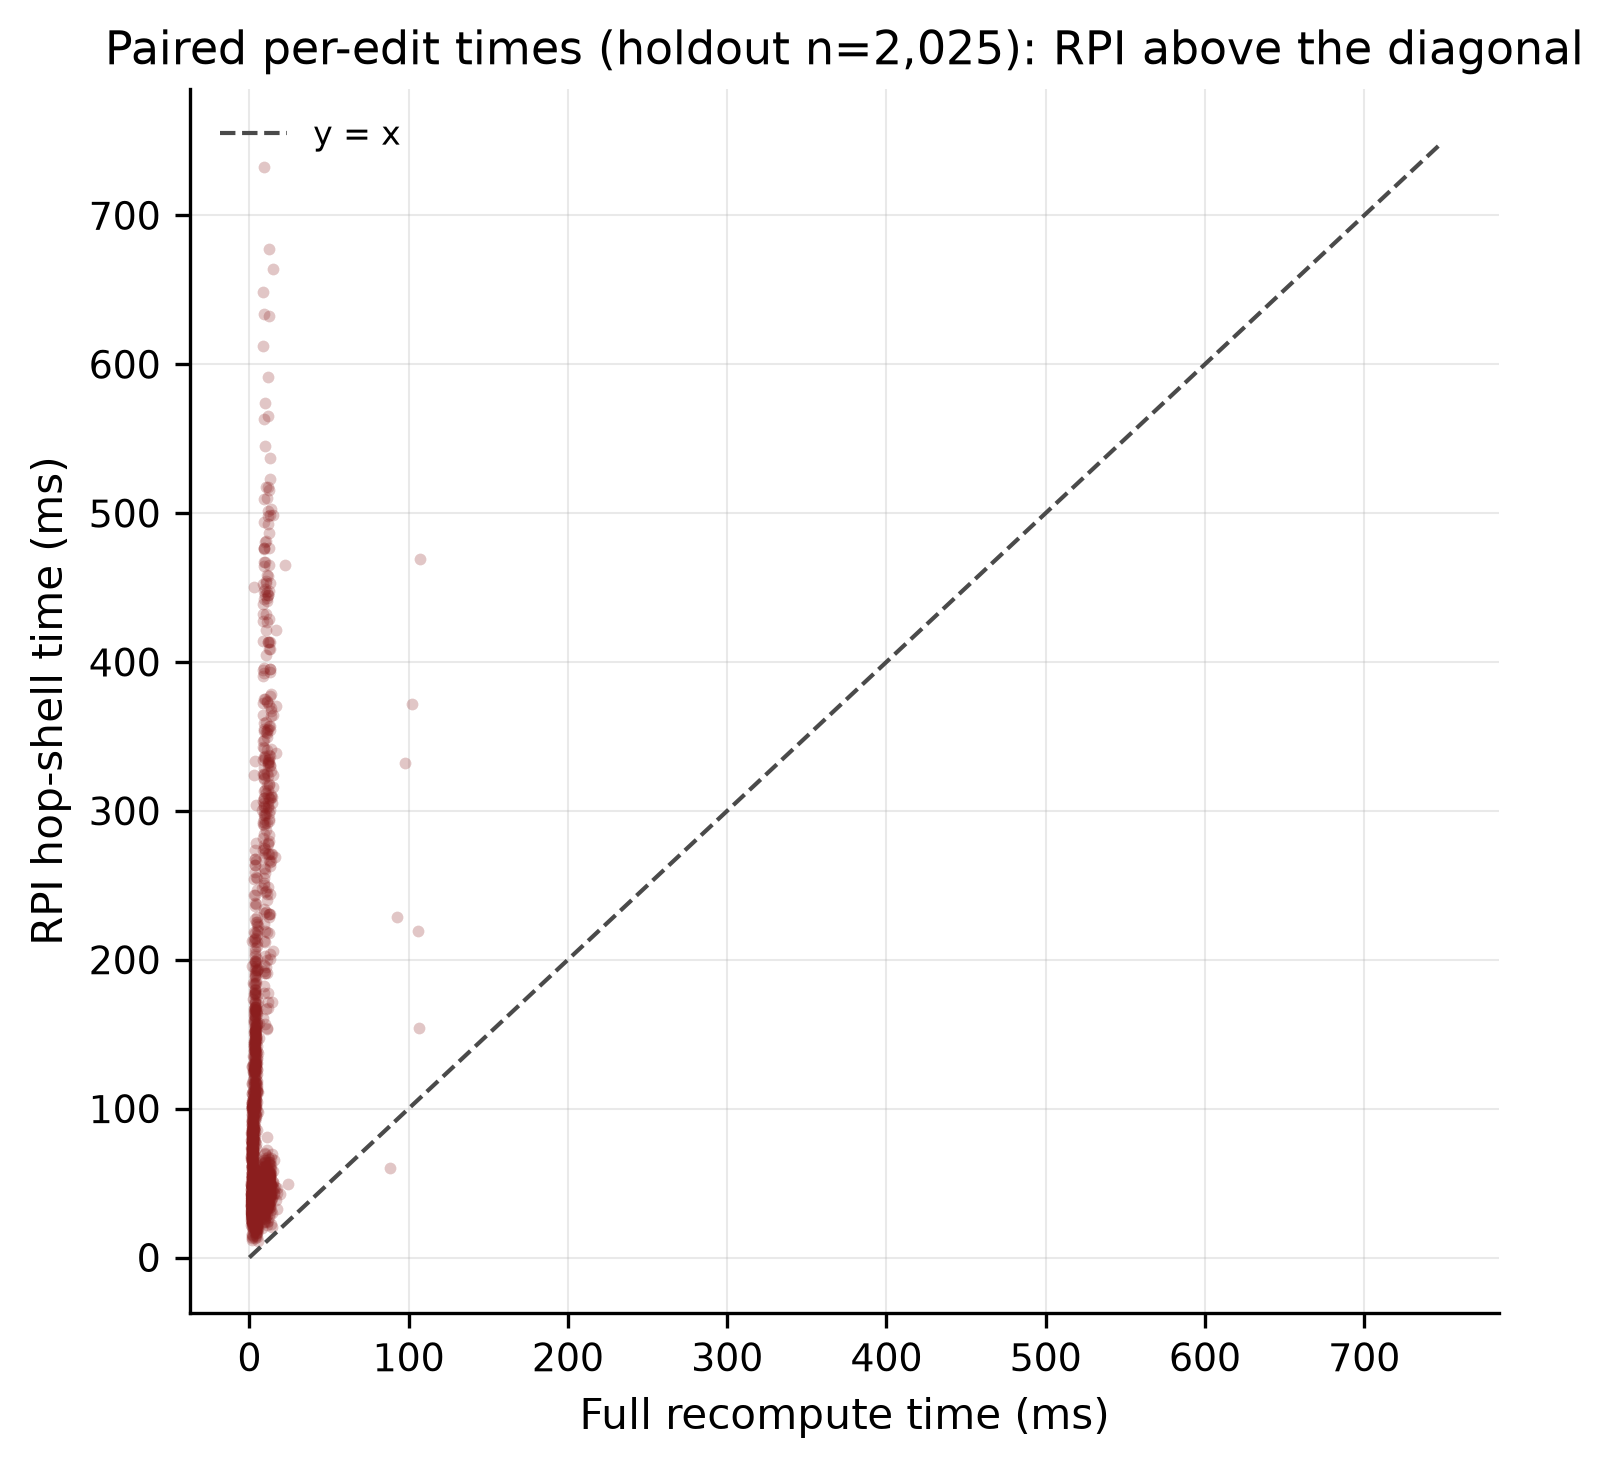

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig23_paired_time_scatter.png


In [40]:
show('fig23_paired_time_scatter')


**Figure 24.** Histogram of Δ time (RPI − full) on the holdout. Median Δ is positive; the Wilcoxon test on nonzero diffs is significant **in the wrong direction** for a speed claim. Spec asked for 5 seeds; only seed 0 exists.


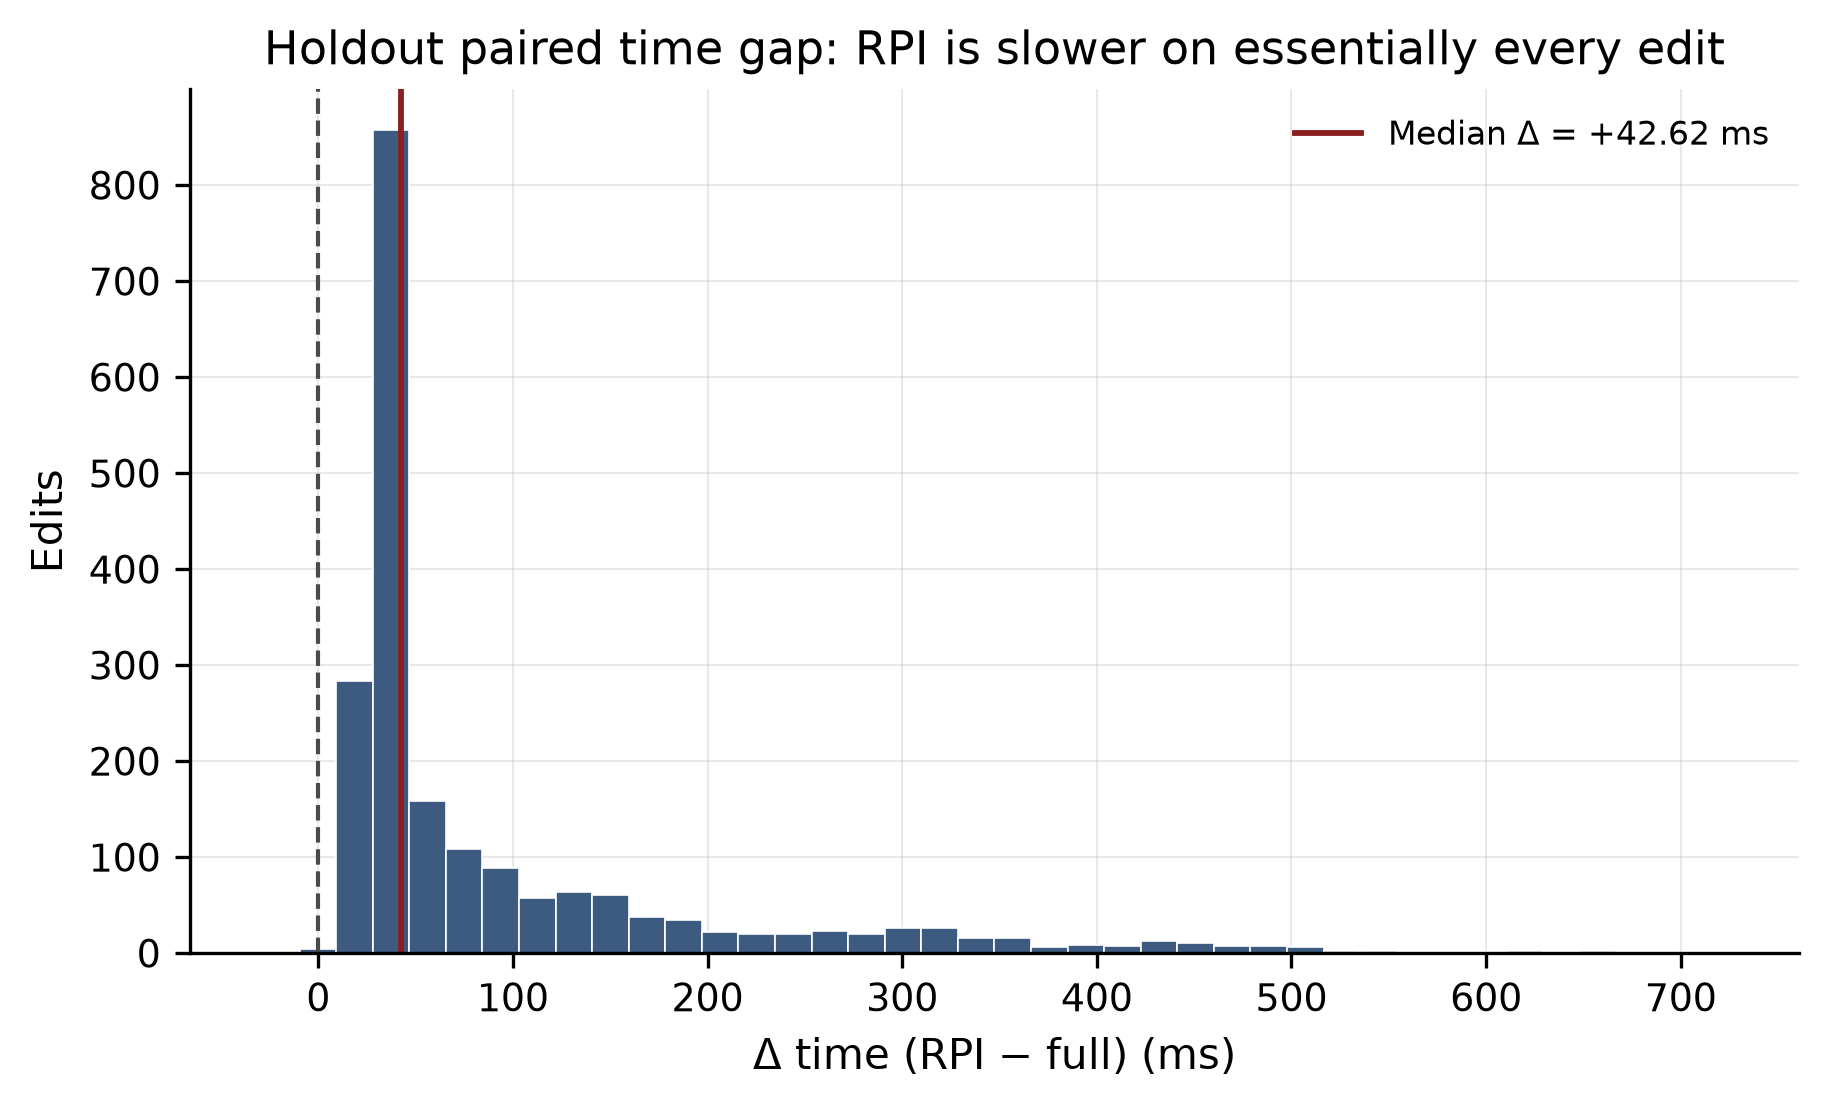

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig24_delta_time_hist.png


In [41]:
show('fig24_delta_time_hist')


**Figure 25.** Same Δ-time histogram on the 160 OOD pairs. Still a positive median gap.


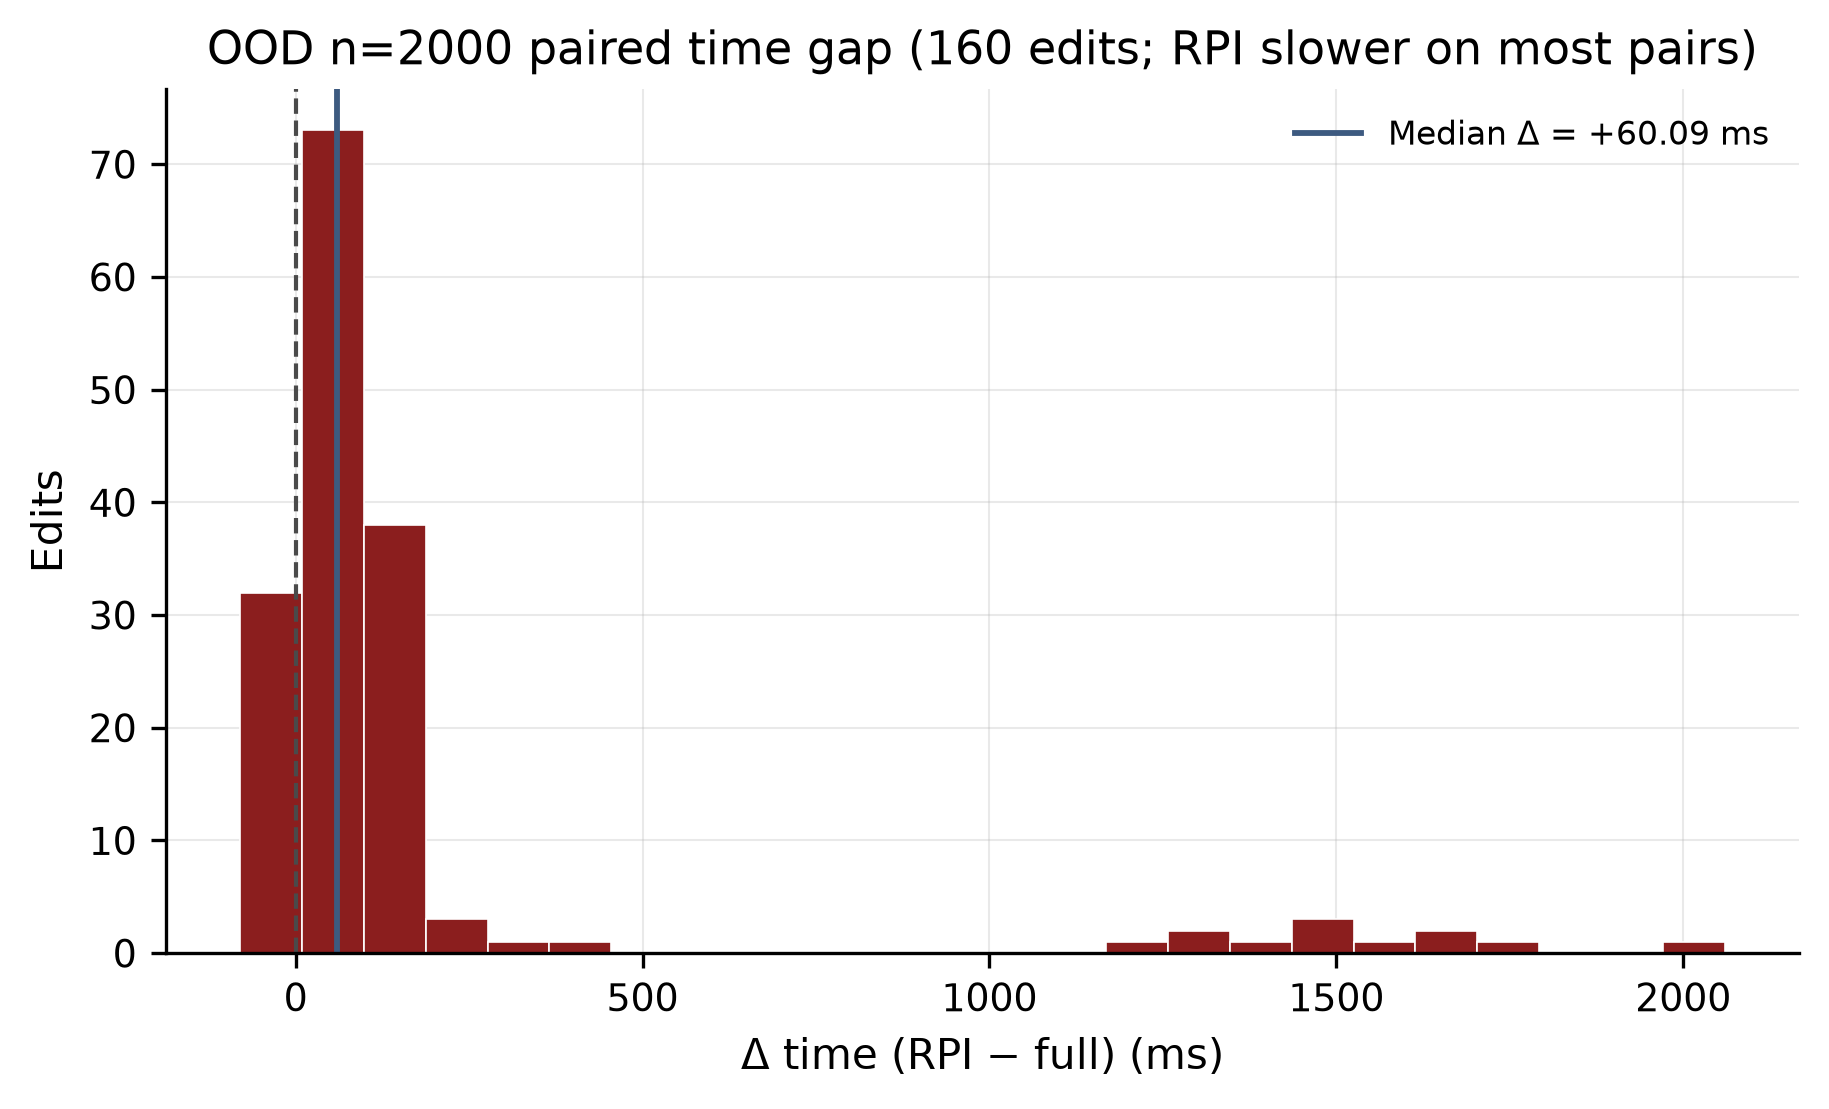

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig25_ood_delta_time_hist.png


In [42]:
show('fig25_ood_delta_time_hist')


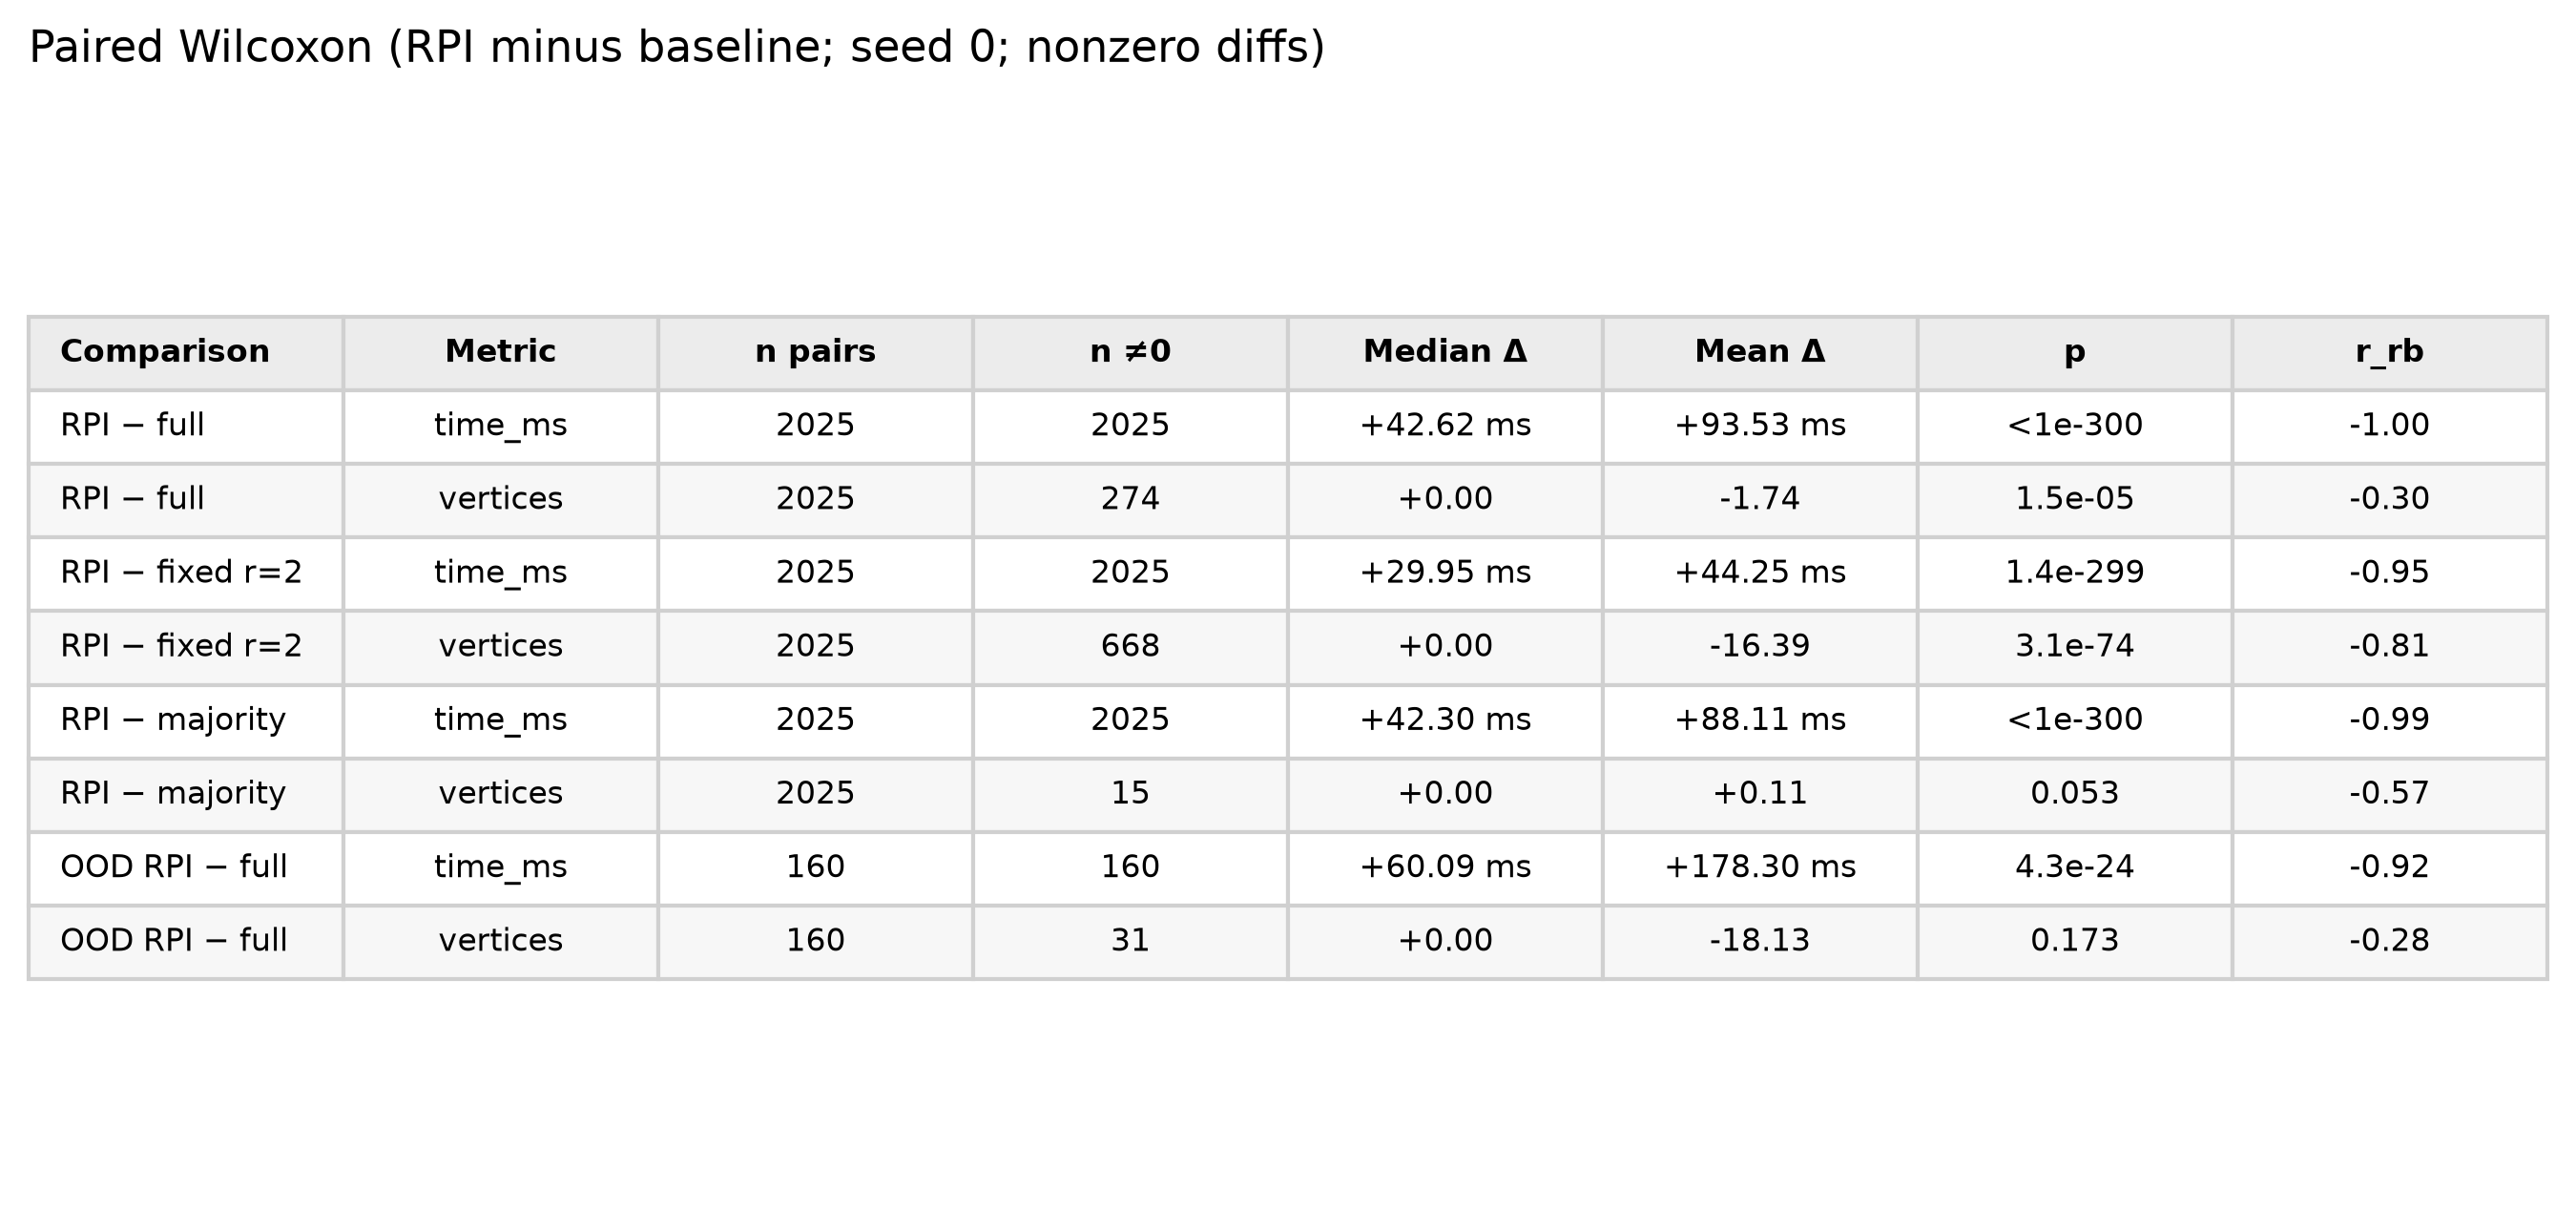

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab05_wilcoxon.png


In [43]:
show('tab05_wilcoxon')


**Figures 29–30.** Shared infeasible counts. Holdout and OOD validity disagreements with full recompute are 0. Failures are the same infeasible-after-edit instances, not RPI-specific coloring bugs.


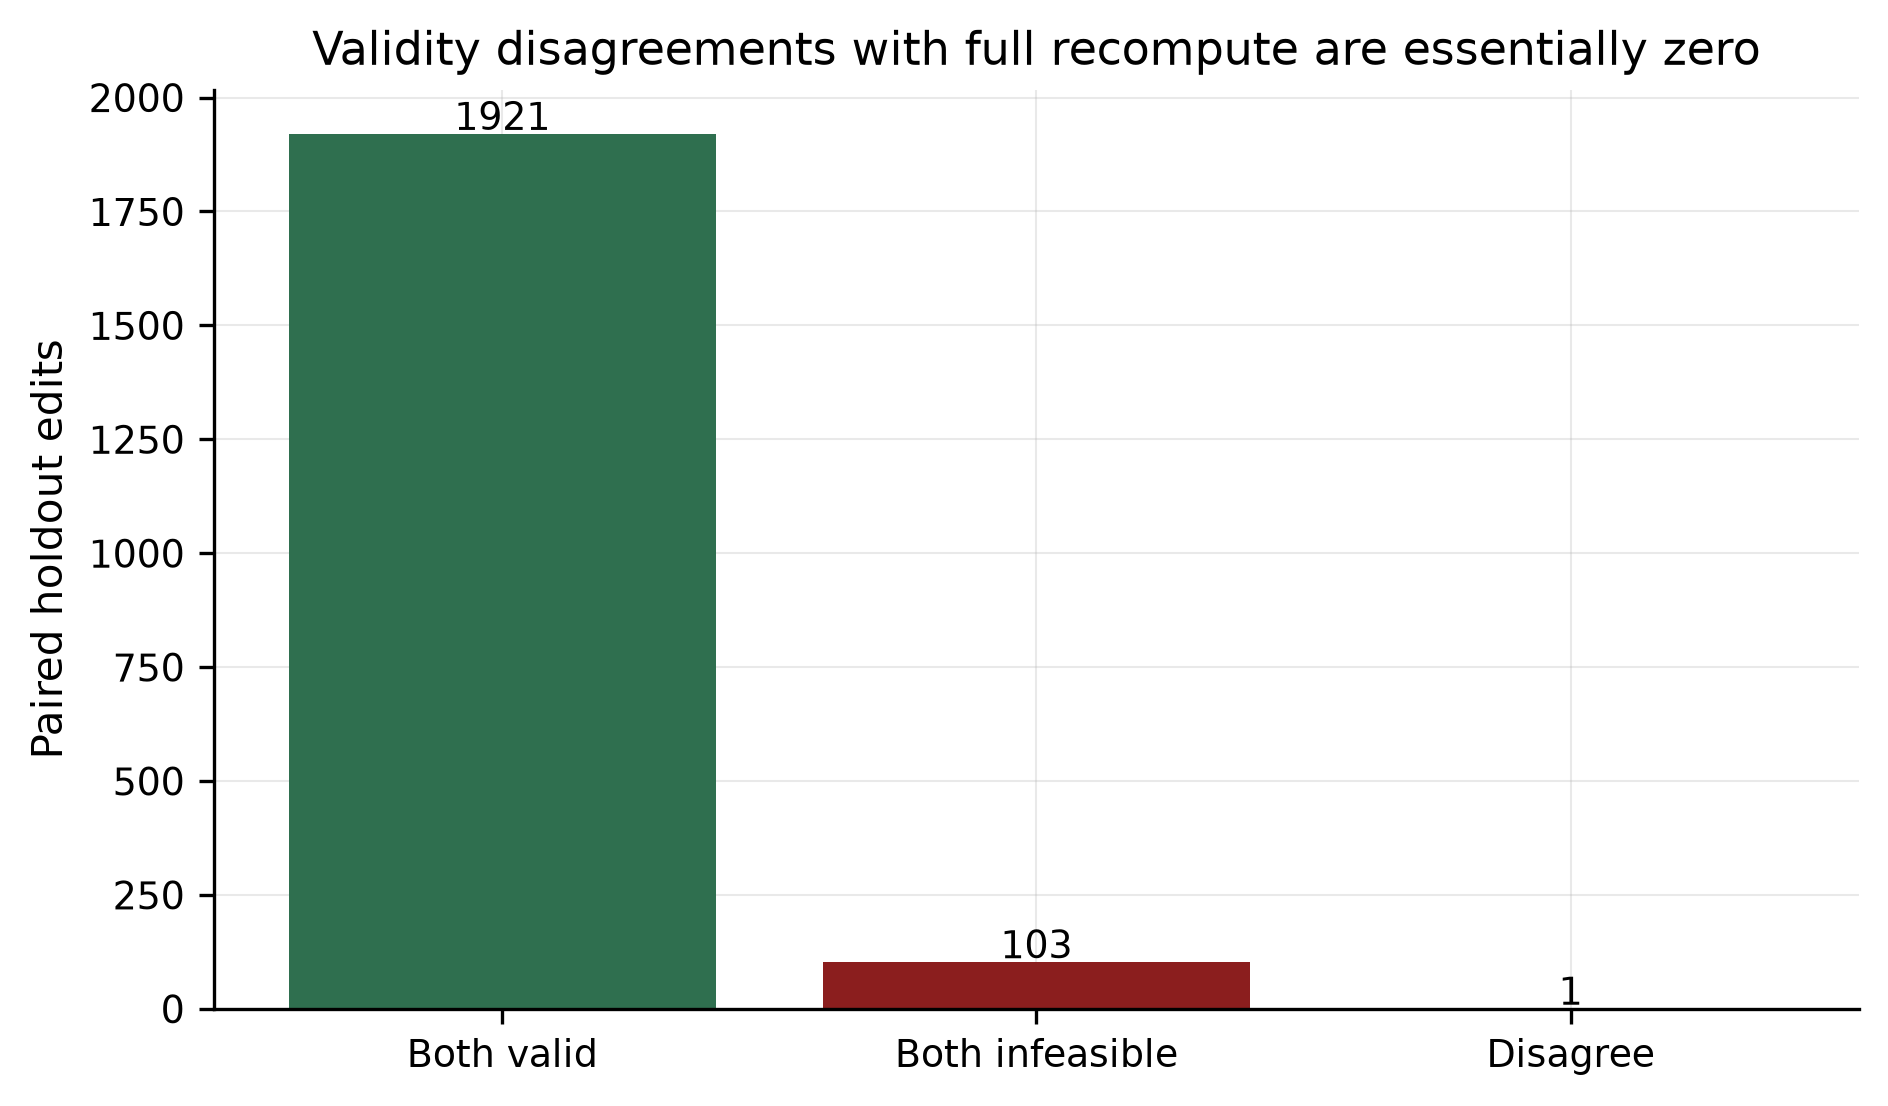

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig29_validity_shared.png


In [44]:
show('fig29_validity_shared')


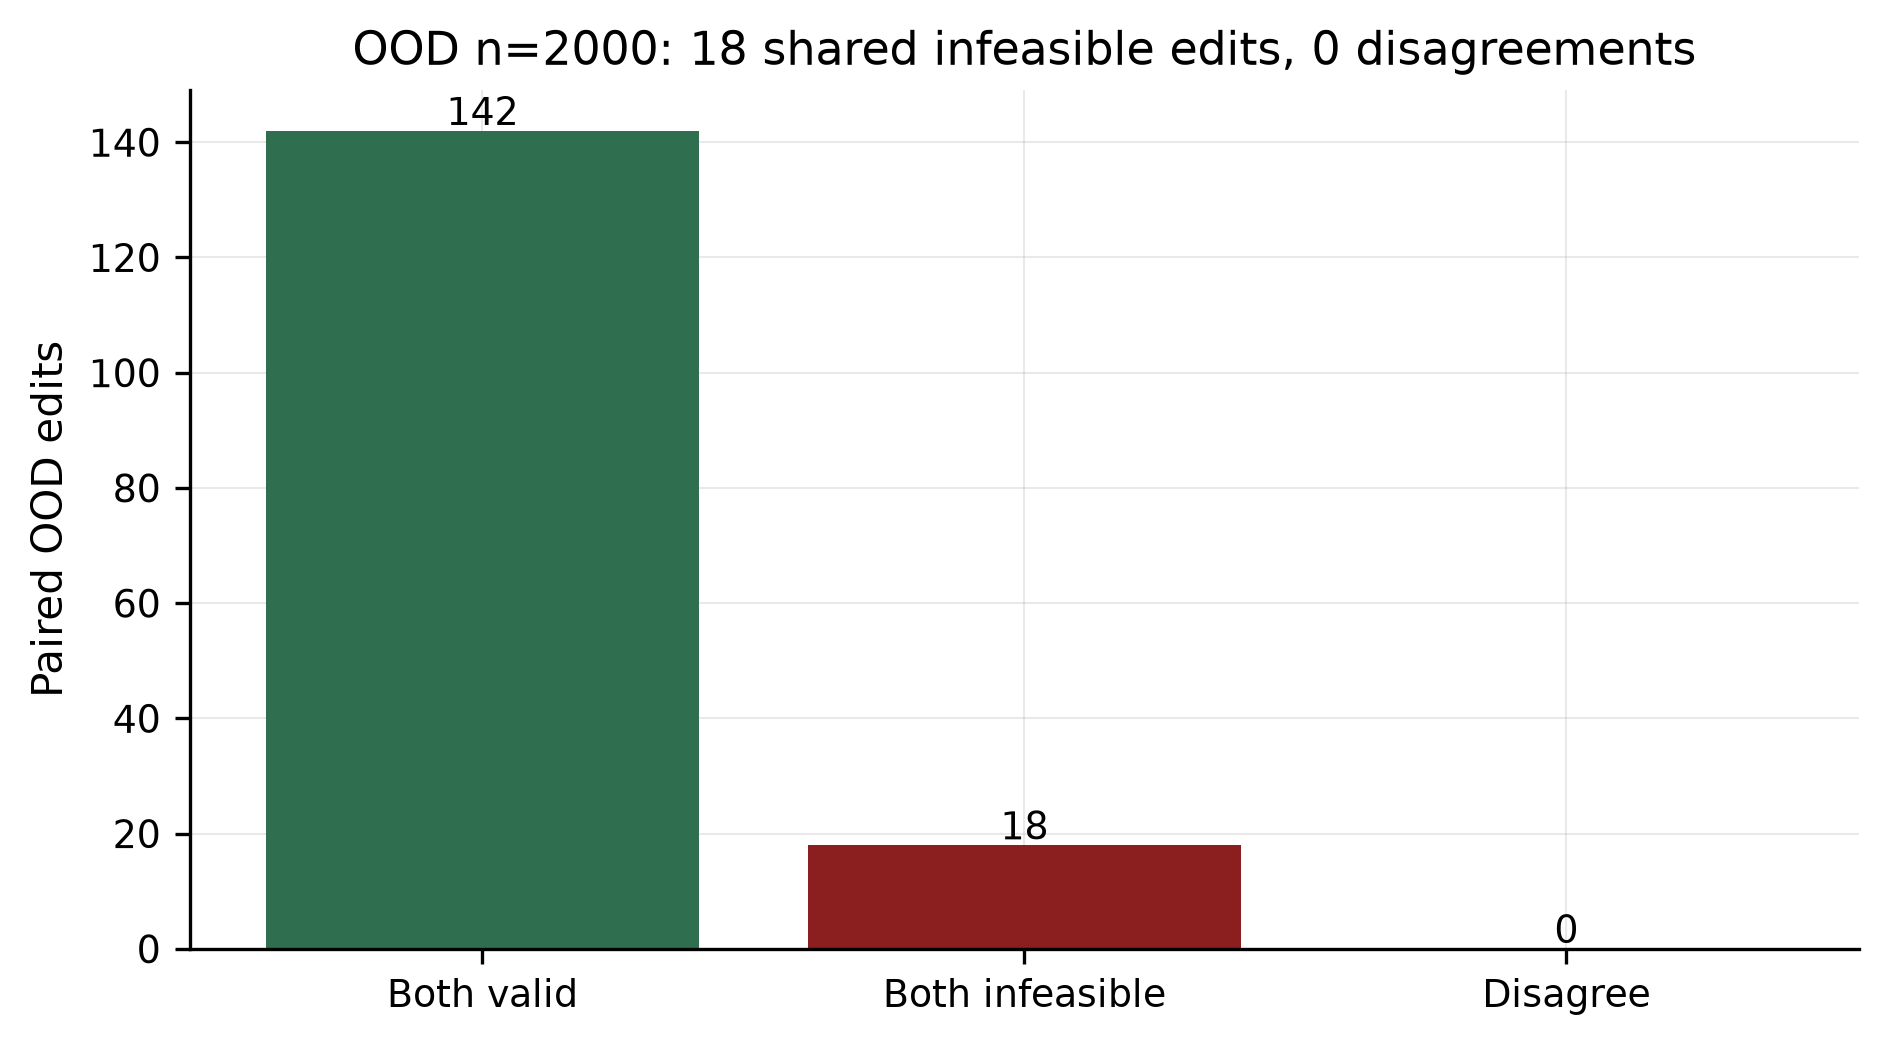

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\fig30_ood_validity_shared.png


In [45]:
show('fig30_ood_validity_shared')


## 6. Expected-pattern check and limitations

**Table 7.** Section 9 scorecard. Pass: locality vs full/fixed, classifier vs majority. Fail: wall-clock and 15% fallback. Validity is “shared infeasible,” not 100% success.


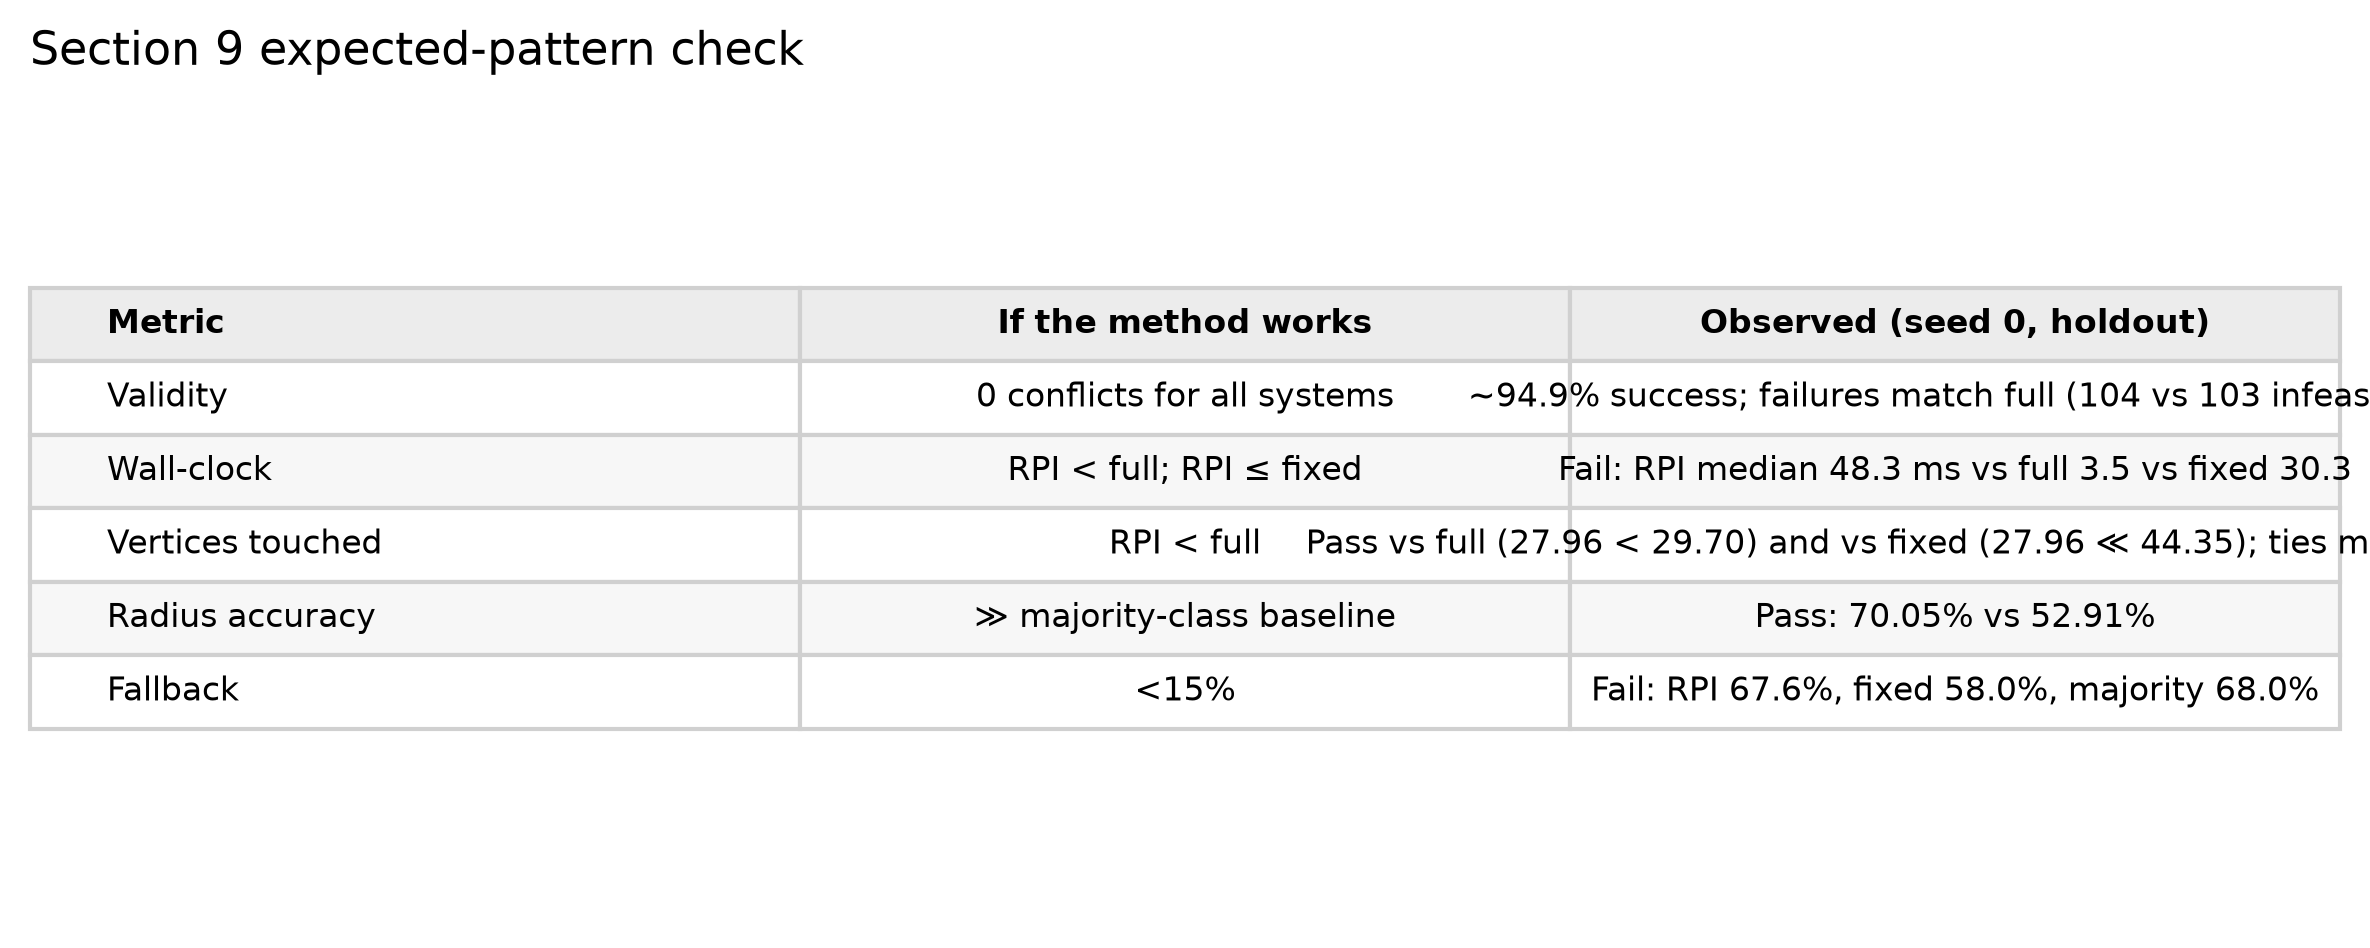

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab07_section9_checklist.png


In [46]:
show('tab07_section9_checklist')


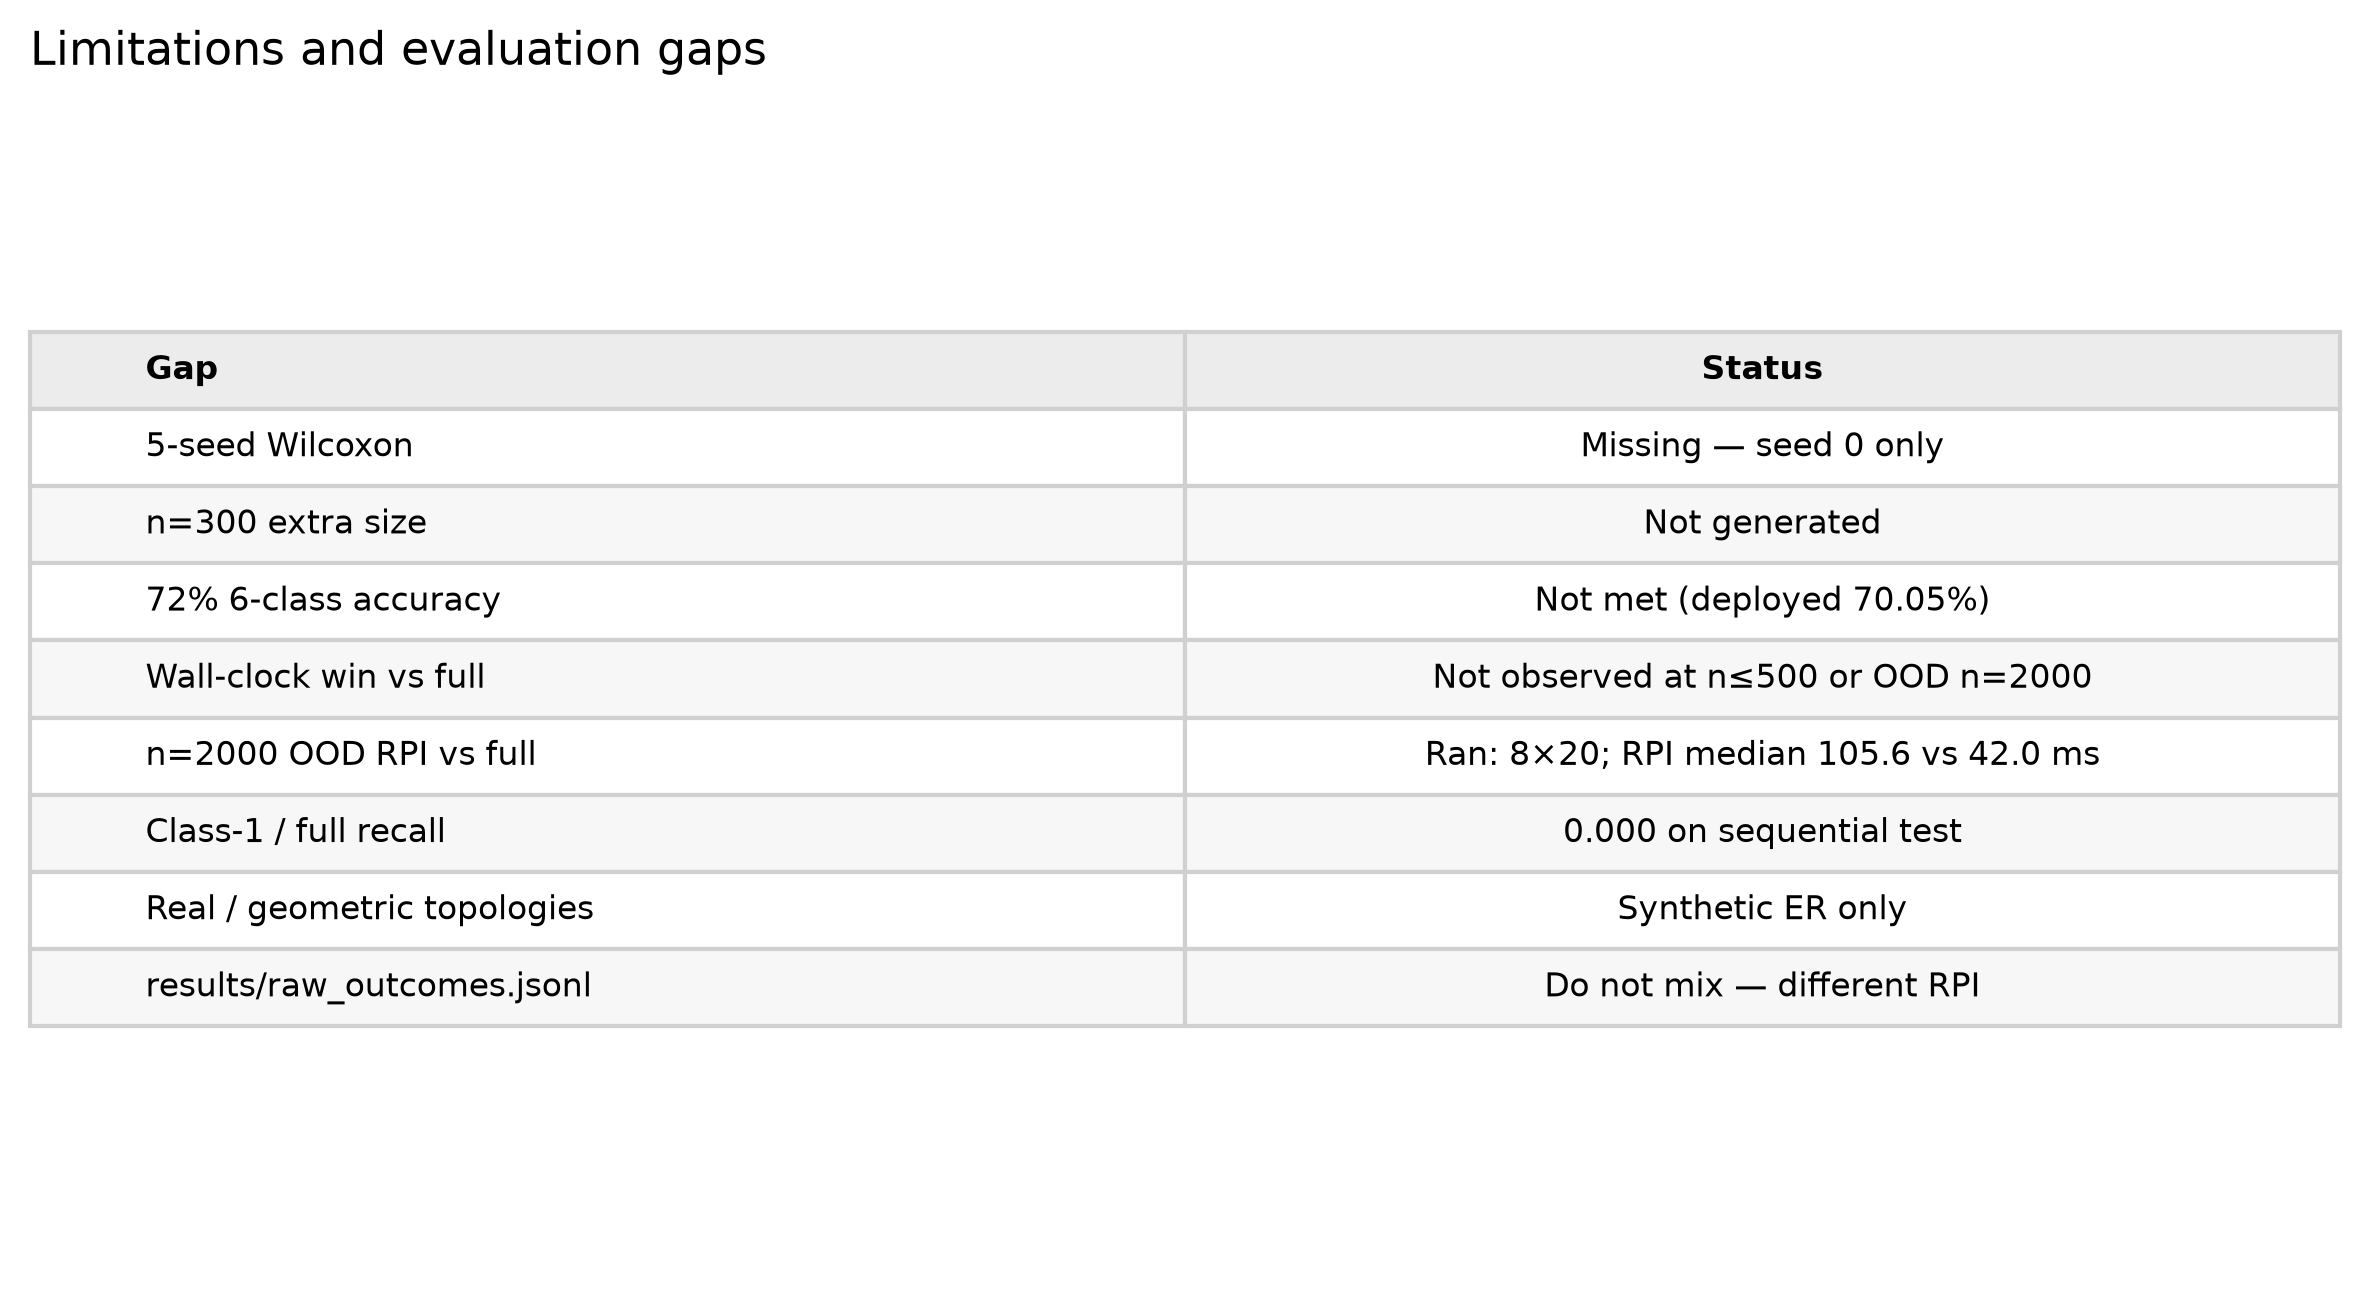

C:\Users\adibb\Desktop\New folder\graphtheoryresearch\paper_figures\tab11_limitations.png


In [47]:
show('tab11_limitations')


## Omitted visualizations

- **Example small-graph coloring before/after an edit.** Not generated. Existing matrix JSONLs store timings and vertex counts, not per-vertex color assignments or drawings. A drawing would require re-running DSATUR on a toy graph and would not change the quantitative claims.
- **5-seed error bars.** Seed 0 only; no honest CI across seeds.
- **Fixed r=2 / majority at n=2000.** Not run.
- **Anything from `results/raw_outcomes.jsonl`.** Different RPI; excluded on purpose.

## How to drop files into a paper

Prefer the `.pdf` vectors. Suggested main-text set is listed in the chat response that accompanies this notebook (`fig01`, `fig03`, `fig05`, `fig09`, `fig18`, `fig26`, plus `tab01` / `tab05`). Appendix: confusion table, Wilcoxon, OOD edit-type, limitations.


In [48]:
print("paper_figures contents:")
for p in sorted(figdir.iterdir()):
    if p.is_file():
        print(f"  {p.name:40s} {p.stat().st_size:8d} B")


paper_figures contents:
  fig00_kpi_strip.pdf                         69220 B
  fig00_kpi_strip.png                         57804 B
  fig01_accuracy_vs_majority.pdf              56146 B
  fig01_accuracy_vs_majority.png              75984 B
  fig02_validity_by_system.pdf                36835 B
  fig02_validity_by_system.png                64799 B
  fig03_median_time_by_system.pdf             37500 B
  fig03_median_time_by_system.png             64993 B
  fig04_fallback_by_system.pdf                36603 B
  fig04_fallback_by_system.png                75527 B
  fig05_mean_verts_by_system.pdf              63793 B
  fig05_mean_verts_by_system.png              67189 B
  fig06_first_try_by_system.pdf               28939 B
  fig06_first_try_by_system.png               59981 B
  fig07_time_iqr_by_system.pdf                29511 B
  fig07_time_iqr_by_system.png                59210 B
  fig08_locality_vs_speed.pdf                 36278 B
  fig08_locality_vs_speed.png                 65832 B
  fi